In [ ]:
# Reload extensions
%load_ext autoreload
%autoreload 2

# Standard imports
import osmnx as ox
import shutil
import pandas as pd
import ast
import numpy as np
import geopandas as gpd
import folium
from folium import plugins
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import zipfile
import os
import re
import json
from shapely.geometry import shape
import ipywidgets as widgets
from ipywidgets import interact, widgets
from IPython.display import display, clear_output
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import requests
from pathlib import Path

# Ignore warnings
warnings.filterwarnings('ignore')

# Import custom functions
from strava_eda import (
    basic_stats,
    create_choropleth_map,
    create_interactive_map_widget,
    analise_padroes_temporais,
    analise_espacial,
    analise_od_matrix,
    analise_atividades
)
from analysis_gap import gap_analysis_ranking, gap_analysis_map
  
# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

## OD Count

In [ ]:
MONTH_MAP = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
 
COUNT_COLS = [
    'count', 'commute_count', 'leisure_count',
    'morning_count', 'midday_count', 'evening_count', 'overnight_count',
    'weekday_count', 'weekend_count'
]

In [ ]:
def _parse_zip_date(filename):
    """Extracts (month, year) from the zip file name as a datetime.

    Params:
        filename: name of the zip file (e.g., origins_and_destinations_apr_2020_ride.zip)

    Returns:
        datetime with year and month, or None if parsing fails.
    """
    match = re.search(r'origins_and_destinations_(\w{3})_(\d{4})_ride\.zip', filename)
    if not match:
        return None
    month = MONTH_MAP.get(match.group(1).lower())
    if month is None:
        return None
    return datetime(int(match.group(2)), month, 1)

def _find_csv_in_zip(zf, suffix):
    """Finds the csv inside the zip file that ends with the given suffix.

    Params:
        zf: opened ZipFile object
        suffix: file suffix (e.g., 'origins.csv')

    Returns:
        name of the file found, or None.
    """
    for name in zf.namelist():
        if name.endswith(suffix):
            return name
    return None

def _get_suffixes(trip_type):
    """Returns a list of csv suffixes to search for inside the zip.

    Params:
        trip_type: 'origin', 'destination' or 'both'

    Returns:
        list of suffixes.
    """
    if trip_type == 'origin':
        return ['origins.csv']
    elif trip_type == 'destination':
        return ['destinations.csv']
    elif trip_type == 'both':
        return ['origins.csv', 'destinations.csv']
    else:
        raise ValueError(f"INVALID TRIP_TYPE: {trip_type}. Use 'origin', 'destination' or 'both'")

In [ ]:
def load_strava_od(data_inicio, data_fim, trip_type='both', name_arc='strava_od_aggregated', od_dir="data/strava/od"):
    """Reads Strava OD zip files within the period and aggregates trip counts by hex_id.

    Creates an auxiliary dataframe with columns hex_id, origins_or_destinations, and count columns
    (starting from 0). It processes zip files in data/strava/od/, ignores those outside the range, unzips
    those within the range, reads the csv files based on trip_type, and accumulates the counts. The result is saved in
    data/strava/all_data/{name_arc}.csv.

    Also reads the shapefiles of polygons (hex_id + geometry) inside each zip,
    consolidates them without duplicates, and saves them as a shapefile.

    Params:
        data_inicio: string 'MM/YYYY' indicating start month/year (inclusive)
        data_fim: string 'MM/YYYY' indicating end month/year (inclusive)
        trip_type: 'origin', 'destination' or 'both'
        name_arc: output csv file name (without extension)

    Returns:
        Tuple (Aggregated DataFrame, GeoDataFrame of polygons).
    """
    dt_inicio = datetime.strptime(data_inicio, '%m/%Y')
    dt_fim = datetime.strptime(data_fim, '%m/%Y')

    if dt_inicio > dt_fim:
        raise ValueError("start date is greater than end date")

    if not os.path.isdir(od_dir):
        raise FileNotFoundError(f"directory not found: {od_dir}")

    suffixes = _get_suffixes(trip_type)

    data_trips_aux = pd.DataFrame(columns=['hex_id', 'origins_or_destinations'] + COUNT_COLS)
    polygons_list = []

    zip_files = sorted([f for f in os.listdir(od_dir) if f.endswith('.zip')])
    if not zip_files:
        raise FileNotFoundError(f"no zip files found in {od_dir}")

    processed_files = 0

    for zip_name in zip_files:
        zip_date = _parse_zip_date(zip_name)
        if zip_date is None:
            print(f"Ignoring file with invalid name: {zip_name}")
            continue

        if zip_date < dt_inicio or zip_date > dt_fim:
            continue

        zip_path = os.path.join(od_dir, zip_name)
        print(f"Reading {zip_name}...")

        try:
            with zipfile.ZipFile(zip_path, 'r') as zf:
                # Read OD CSVs
                for suffix in suffixes:
                    csv_name = _find_csv_in_zip(zf, suffix)
                    if csv_name is None:
                        raise FileNotFoundError(
                            f"file with suffix '{suffix}' not found inside {zip_name}"
                        )

                    with zf.open(csv_name) as csv_file:
                        df = pd.read_csv(csv_file)
                    print(f"  Successfully read: {csv_name}")

                    df_agg = df.groupby(['hex_id', 'origins_or_destinations'], as_index=False)[COUNT_COLS].sum()
                    data_trips_aux = pd.concat([data_trips_aux, df_agg], ignore_index=True)

                # Read shapefile of polygons
                shp_name = next((f for f in zf.namelist() if f.endswith('.shp')), None)
                if shp_name:
                    gdf_poly = gpd.read_file(f"zip://{zip_path}!{shp_name}")
                    polygons_list.append(gdf_poly[['hex_id', 'geometry']])

            processed_files += 1

        except zipfile.BadZipFile:
            raise RuntimeError(f"corrupted zip file: {zip_name}")
        except Exception as e:
            raise RuntimeError(f"error reading {zip_name}: {e}")

    if processed_files == 0:
        raise RuntimeError(
            f"no files found in the period {data_inicio} - {data_fim}"
        )

    # Aggregate OD
    data_trips_aux = data_trips_aux.groupby(
        ['hex_id', 'origins_or_destinations'], as_index=False
    )[COUNT_COLS].sum()

    # Consolidate polygons without duplicates
    gdf_polygons = gpd.GeoDataFrame()
    if polygons_list:
        gdf_polygons = pd.concat(polygons_list, ignore_index=True)
        gdf_polygons = gpd.GeoDataFrame(gdf_polygons, geometry='geometry')
        gdf_polygons = gdf_polygons.drop_duplicates(subset='hex_id').reset_index(drop=True)

    # Save
    out_dir = 'data/strava/all_data'
    os.makedirs(out_dir, exist_ok=True)

    out_csv = os.path.join(out_dir, f'{name_arc}.csv')
    data_trips_aux.to_csv(out_csv, index=False)
    print(f"Saved to {out_csv}")

    out_shp = os.path.join(out_dir, f'{name_arc}_polygons.shp')
    if not gdf_polygons.empty:
        gdf_polygons.to_file(out_shp)
        print(f"Shapefile saved to {out_shp}")

    print(f"Total zip files processed: {processed_files}")

    return data_trips_aux, gdf_polygons

In [ ]:
def get_strava_od_date_range(trip_type='both', od_dir="data/strava/od"):
    """Returns the minimum and maximum dates found in the Strava OD CSV files.

    It traverses all the zip files in od_dir in chronological order, reads the CSVs based on
    trip_type, and extracts the minimum and maximum values from the 'date' column.

    Params:
        trip_type: 'origin', 'destination', or 'both'
        od_dir: directory containing Strava OD zip files

    Returns:
        Tuple (min_date, max_date) as strings in 'YYYY-MM' format.
    """
    if not os.path.isdir(od_dir):
        raise FileNotFoundError(f"Directory not found: {od_dir}")

    suffixes = _get_suffixes(trip_type)
    zip_files = sorted([f for f in os.listdir(od_dir) if f.endswith('.zip')])

    if not zip_files:
        raise FileNotFoundError(f"No zip files found in {od_dir}")

    all_dates = []

    for zip_name in zip_files:
        if _parse_zip_date(zip_name) is None:
            continue

        zip_path = os.path.join(od_dir, zip_name)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            for suffix in suffixes:
                csv_name = _find_csv_in_zip(zf, suffix)
                if csv_name is None:
                    continue
                with zf.open(csv_name) as csv_file:
                    df = pd.read_csv(csv_file, usecols=['date'])
                all_dates.append(df['date'].min())
                all_dates.append(df['date'].max())

    if not all_dates:
        raise RuntimeError("No dates found in the zip files.")

    return min(all_dates), max(all_dates)

In [ ]:
get_strava_od_date_range(trip_type='both', od_dir="data/strava/od")

In [ ]:
zip_path = "data/strava/od/origins_and_destinations_apr_2023_ride.zip"

with zipfile.ZipFile(zip_path, 'r') as zf:
    # origins
    origins_name = [f for f in zf.namelist() if f.endswith('-origins.csv')][0]
    with zf.open(origins_name) as f:
        df_origins = pd.read_csv(f)

    # polygons
    shp_name = [f for f in zf.namelist() if f.endswith('.shp')][0]
    gdf_poly = gpd.read_file(f"zip://{zip_path}!{shp_name}")

print(df_origins.shape)
print(df_origins.head(3))
print(gdf_poly.head(3))

In [ ]:
data_trips, gdf_polygons = load_strava_od(data_inicio = "01/2018",  data_fim = "01/2027", trip_type='both', 
               name_arc='strava_od_all_trips', od_dir="data/strava/od")

## Edge Count

In [ ]:
# Colunas de contagem que serao somadas
COUNT_COLUMNS = [
    "total_trip_count", "forward_trip_count", "reverse_trip_count",
    "forward_people_count", "reverse_people_count",
    "forward_commute_trip_count", "reverse_commute_trip_count",
    "forward_leisure_trip_count", "reverse_leisure_trip_count",
    "forward_male_people_count", "reverse_male_people_count",
    "forward_female_people_count", "reverse_female_people_count",
    "forward_unspecified_people_count", "reverse_unspecified_people_count",
    "forward_18_34_people_count", "reverse_18_34_people_count",
    "forward_35_54_people_count", "reverse_35_54_people_count",
    "forward_55_64_people_count", "reverse_55_64_people_count",
    "forward_65_plus_people_count", "reverse_65_plus_people_count",
    "ride_count", "ebike_ride_count",
]
 
SPEED_COLUMNS = [
    "forward_average_speed_meters_per_second",
    "reverse_average_speed_meters_per_second",
]
 
AUX_COLUMNS = ["edge_uid", "osm_reference_id"] + COUNT_COLUMNS + SPEED_COLUMNS

In [ ]:
def _parse_dates_from_filename(filename):
    """Extracts start_date and end_date from the zip file name.

    Params:
        filename: name of the file (e.g., all_edges_hourly_2019-04-01-2019-04-30_ride.zip)

    Returns:
        tuple (start_date, end_date) as datetime.date, or None if parsing fails.
    """
    match = re.search(r"(\d{4}-\d{2}-\d{2})-(\d{4}-\d{2}-\d{2})", filename)
    if not match:
        return None
    try:
        d_start = datetime.strptime(match.group(1), "%Y-%m-%d").date()
        d_end = datetime.strptime(match.group(2), "%Y-%m-%d").date()
        return d_start, d_end
    except ValueError:
        return None

def _file_in_range(file_start, file_end, range_start, range_end):
    """Checks if the file period intersects with the requested range.

    Params:
        file_start: start date of the file
        file_end: end date of the file
        range_start: start date of the filter
        range_end: end date of the filter

    Returns:
        True if there is an intersection.
    """
    return file_start <= range_end and file_end >= range_start

In [ ]:
def aggregate_strava_edges(data_inicio, data_fim, name_arc, hor_start=None, hor_end=None, edges_dir="data/strava/all_edges", output_dir="data/strava/all_data"):
    """Reads all zip files in edges_dir, filters by period and time, and aggregates counts by edge_uid.

    Also reads the geometry shapefiles (edge_uid + geometry) inside each zip,
    consolidates them without duplicates, and saves them as a shapefile.

    Params:
        data_inicio: string in 'DD/MM/YYYY' or 'HH DD/MM/YYYY' format
        data_fim: string in 'DD/MM/YYYY' or 'HH DD/MM/YYYY' format
        name_arc: output file name (without extension)
        hor_start: start time for daily filter (int 0-23). None = no lower filter.
        hor_end: end time for daily filter (int 0-23, inclusive). None = no upper filter.
        edges_dir: directory with zip files
        output_dir: output directory

    Returns:
        Tuple (Aggregated DataFrame by edge_uid, GeoDataFrame of geometries).
    """
    for fmt in ("%H %d/%m/%Y", "%d/%m/%Y"):
        try:
            dt_inicio = datetime.strptime(data_inicio, fmt).date()
            break
        except ValueError:
            continue
    else:
        raise ValueError(f"invalid format for data_inicio: '{data_inicio}'. Use 'DD/MM/YYYY' or 'HH DD/MM/YYYY'")

    for fmt in ("%H %d/%m/%Y", "%d/%m/%Y"):
        try:
            dt_fim = datetime.strptime(data_fim, fmt).date()
            break
        except ValueError:
            continue
    else:
        raise ValueError(f"invalid format for data_fim: '{data_fim}'. Use 'DD/MM/YYYY' or 'HH DD/MM/YYYY'")

    if dt_inicio > dt_fim:
        raise ValueError(f"data_inicio ({data_inicio}) is later than data_fim ({data_fim})")

    zip_files = sorted([f for f in os.listdir(edges_dir) if f.endswith(".zip")])
    if not zip_files:
        raise FileNotFoundError(f"no zip files found in {edges_dir}")

    data_trips_edge_aux = pd.DataFrame(columns=AUX_COLUMNS).set_index("edge_uid")
    for col in COUNT_COLUMNS + SPEED_COLUMNS:
        data_trips_edge_aux[col] = data_trips_edge_aux[col].astype(float)

    average_speed_edge = pd.DataFrame(columns=["edge_uid", "count"]).set_index("edge_uid")
    average_speed_edge["count"] = average_speed_edge["count"].astype(int)

    polygons_list = []
    files_read = 0

    for zip_name in zip_files:
        parsed = _parse_dates_from_filename(zip_name)
        if parsed is None:
            print(f"warning: could not extract dates from '{zip_name}', ignoring")
            continue

        file_start, file_end = parsed

        if not _file_in_range(file_start, file_end, dt_inicio, dt_fim):
            continue

        zip_path = os.path.join(edges_dir, zip_name)
        print(f"reading {zip_name}...")

        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                csv_files = [n for n in zf.namelist() if n.endswith(".csv")]
                if not csv_files:
                    raise FileNotFoundError(f"no csv file found inside {zip_name}")

                csv_name = csv_files[0]
                with zf.open(csv_name) as csv_file:
                    df = pd.read_csv(csv_file)

                # Read shapefile of geometries
                shp_name = next((f for f in zf.namelist() if f.endswith('.shp')), None)
                if shp_name:
                    gdf_poly = gpd.read_file(f"zip://{zip_path}!{shp_name}")
                    if 'edgeUID' in gdf_poly.columns:
                        polygons_list.append(gdf_poly[['edgeUID', 'geometry']].rename(columns={'edgeUID': 'edge_uid'}))

        except zipfile.BadZipFile:
            raise RuntimeError(f"error: corrupted zip file - {zip_name}")
        except Exception as e:
            raise RuntimeError(f"error: failed to read {zip_name} - {e}")

        # Filter by time of day
        if hor_start is not None or hor_end is not None:
            df["_hour_int"] = df["hour"].str.split("T").str[1].astype(int)
            if hor_start is not None:
                df = df[df["_hour_int"] >= hor_start]
            if hor_end is not None:
                df = df[df["_hour_int"] <= hor_end]
            df = df.drop(columns=["_hour_int"])
            if df.empty:
                print(f"  {zip_name}: no rows in the time range {hor_start}-{hor_end}, skipping")
                continue

        agg_dict = {col: "sum" for col in COUNT_COLUMNS + SPEED_COLUMNS}
        agg_dict["osm_reference_id"] = "first"
        df_agg = df.groupby("edge_uid").agg(agg_dict)

        edge_counts = df.groupby("edge_uid").size().rename("count")

        common_edges = data_trips_edge_aux.index.intersection(df_agg.index)
        new_edges = df_agg.index.difference(data_trips_edge_aux.index)

        if len(new_edges) > 0:
            new_rows = df_agg.loc[new_edges].copy()
            data_trips_edge_aux = pd.concat([data_trips_edge_aux, new_rows])
            new_speed = edge_counts.loc[new_edges].to_frame("count")
            average_speed_edge = pd.concat([average_speed_edge, new_speed])

        if len(common_edges) > 0:
            for col in COUNT_COLUMNS + SPEED_COLUMNS:
                data_trips_edge_aux.loc[common_edges, col] += df_agg.loc[common_edges, col]
            average_speed_edge.loc[common_edges, "count"] += edge_counts.loc[common_edges]

        files_read += 1
        print(f"  {zip_name} successfully read ({len(df)} rows, {len(df_agg)} edges)")

    if files_read == 0:
        print(f"warning: no zip files found in the period {data_inicio} - {data_fim}")

    # Calculate average speed
    valid_speed = average_speed_edge[average_speed_edge["count"] > 0].index
    for col in SPEED_COLUMNS:
        data_trips_edge_aux.loc[valid_speed, col] = (
            data_trips_edge_aux.loc[valid_speed, col] / average_speed_edge.loc[valid_speed, "count"]
        )

    data_trips_edge_aux = data_trips_edge_aux.reset_index()

    # Consolidate geometries without duplicates
    gdf_edges_geo = gpd.GeoDataFrame()
    if polygons_list:
        gdf_edges_geo = pd.concat(polygons_list, ignore_index=True)
        gdf_edges_geo = gpd.GeoDataFrame(gdf_edges_geo, geometry='geometry')
        gdf_edges_geo = gdf_edges_geo.drop_duplicates(subset='edge_uid').reset_index(drop=True)

    # Save
    os.makedirs(output_dir, exist_ok=True)

    output_path = os.path.join(output_dir, f"{name_arc}.csv")
    data_trips_edge_aux.to_csv(output_path, index=False)
    print(f"saved to {output_path} ({len(data_trips_edge_aux)} edges, {files_read} files processed)")

    if not gdf_edges_geo.empty:
        shp_path = os.path.join(output_dir, f"{name_arc}_geometries.shp")
        gdf_edges_geo.to_file(shp_path)
        print(f"shapefile saved to {shp_path}")

    return data_trips_edge_aux, gdf_edges_geo

In [ ]:
def get_strava_edges_date_range(edges_dir="data/strava/all_edges"):
    """Returns the minimum and maximum dates found in the zip file names of edges.

    It traverses all the zips in edges_dir, extracts the dates from the filename using
    _parse_dates_from_filename and returns the global extremes.

    Params:
        edges_dir: directory containing the zip files of edges

    Returns:
        Tuple (min_date, max_date) as date objects.
    """
    if not os.path.isdir(edges_dir):
        raise FileNotFoundError(f"Directory not found: {edges_dir}")

    zip_files = sorted([f for f in os.listdir(edges_dir) if f.endswith('.zip')])
    if not zip_files:
        raise FileNotFoundError(f"No zip files found in {edges_dir}")

    all_dates = []
    for zip_name in zip_files:
        parsed = _parse_dates_from_filename(zip_name)
        if parsed is None:
            continue
        file_start, file_end = parsed
        all_dates.extend([file_start, file_end])

    if not all_dates:
        raise RuntimeError("No dates extracted from the zip files.")

    return min(all_dates), max(all_dates)

In [ ]:
get_strava_edges_date_range(edges_dir="data/strava/all_edges")

In [ ]:
df, df1 = aggregate_strava_edges("01/01/2018", "01/02/2027", "all_trips", hor_start=None, hor_end=None, edges_dir="data/strava/all_edges", output_dir="data/strava/all_data")


## Origins and Destinations Data - Data Fields / Data Dictionary
- origins_and_destinations_jan_2023_ped
- Origins and Destinations exports summarize where activities begin and end within H3 hexagonal grid cells.
- Each row in the Origins and Destinations data represents a set of trips that started or ended in a specific hexagonal cell (identified by hex_id) within a selected time period. The count in the row represents the total number of activities that occurred in that hexagonal cell for the specific activity.
- 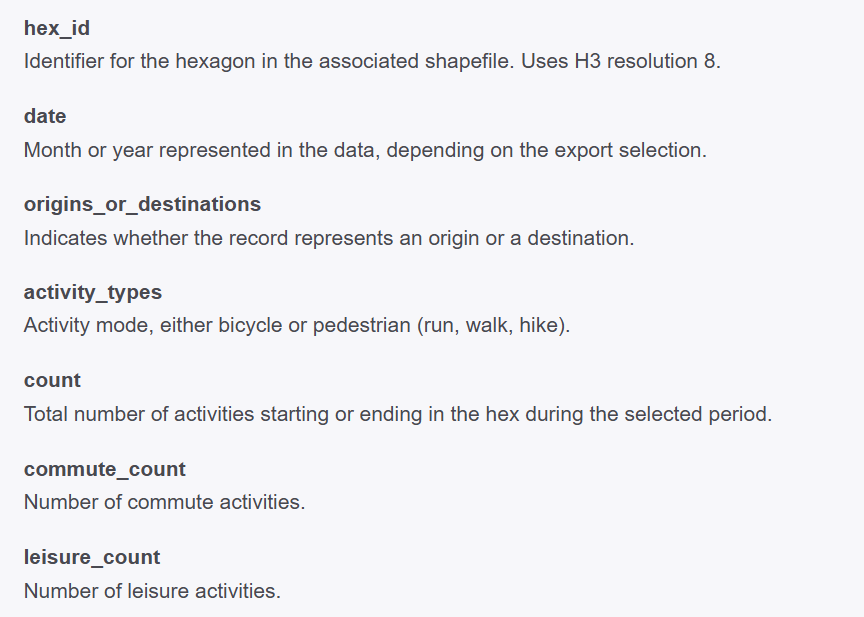
- 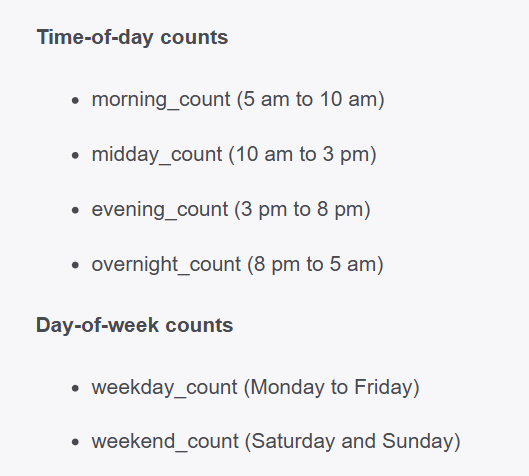

# EDA Data Strava Origins and Destinations

## Basic Dataset Information

In [ ]:
edge_count = pd.read_csv("./data/strava/all_data/all_trips_edges.csv")
gdf = gpd.read_file("./data/strava/all_data/strava_od_all_trips_polygons.shp")
hexagonos = pd.read_csv("./data/strava/all_data/strava_od_all_trips.csv")


In [ ]:
def basic_information_dataset(hexagons): 
    """Identifies basic information about the dataset, such as dimensions, data types, and missing values.

    Parameters
    ----------
    hexagons : pd.DataFrame
        DataFrame containing the data for hexagonal grid cells, with various attributes.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame showing the missing values and their percentages for each column.
    """
    
    # Print dataset structure: dimensions (rows and columns)
    print("Dataset Structure")
    print(f"Dimensions: {hexagons.shape[0]:,} rows × {hexagons.shape[1]} columns\n")
    
    # Print data types for each column
    print("\nData Types and Columns:")
    print(hexagons.dtypes)
    
    # Calculate and display missing values in the dataset
    print("\nMissing Values:")
    missing = hexagons.isnull().sum()
    missing_pct = (missing / len(hexagons) * 100).round(2)
    
    # Create and display DataFrame for missing values and percentages
    missing_df = pd.DataFrame({
        'Column': missing.index,
        'Missing Values': missing.values,
        'Percentage (%)': missing_pct.values
    })
    display(missing_df[missing_df['Missing Values'] > 0])
    
    return missing_df

In [ ]:
basic_information_dataset(hexagonos)

In [ ]:
def filter_od(df, origem_destino=2):
    """
    Filters the DataFrame based on the 'origins_or_destinations' column.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to filter.
    origem_destino : int, optional
        Filter option. 0 for origins, 1 for destinations, and 2 for both (default is 2).
    
    Returns
    -------
    pd.DataFrame
        The filtered DataFrame.
    
    Raises
    ------
    ValueError
        If origem_destino is not 0, 1, or 2.
    """
    
    if origem_destino == 2:
        return df.copy()

    if origem_destino == 0:
        return df[df["origins_or_destinations"] == "origins"].copy()

    if origem_destino == 1:
        return df[df["origins_or_destinations"] == "destinations"].copy()

    raise ValueError("origem_destino must be 0 (origins), 1 (destinations), or 2 (both)")

In [ ]:
COUNT_COLS = [
    "count","commute_count","leisure_count",
    "morning_count","midday_count","evening_count","overnight_count",
    "weekday_count","weekend_count"
]
OD_MAP = {0: "origins", 1: "destinations", 2: "both"}


In [ ]:
def basic_stats(df, origem_destino=2, count_cols=COUNT_COLS):
    """Display descriptive statistics for numeric, categorical, and count columns.

    Filters the DataFrame by origin/destination type, then prints:
    - Numeric columns: describe() plus median, mode, range, and IQR.
    - Categorical: value counts for 'activity_types' if present.
    - Count columns: describe() for columns listed in `count_cols`.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame with trip or station data.
    origem_destino : int, optional
        Origin/destination filter code passed to `filter_od` (default 2).
    count_cols : list of str, optional
        Column names to summarize as count data (default COUNT_COLS).
    """
    d = filter_od(df, origem_destino)

    print(f"Basic Stats: {OD_MAP[origem_destino]}")
    
    # numeric columns
    num_cols = d.select_dtypes(include=np.number).columns
    if len(num_cols):
        desc = d[num_cols].describe().T
        desc["median"] = d[num_cols].median()
        desc["mode"] = d[num_cols].mode().iloc[0]
        desc["range"] = desc["max"] - desc["min"]
        desc["iqr"] = desc["75%"] - desc["25%"]

        print("Estatísticas numéricas:")
        display(desc)

    # categoric columns
    if "activity_types" in d.columns:
        print(d["activity_types"].value_counts())

    # count columns
    existing = [c for c in count_cols if c in d.columns]
    if existing:
        print("\nCount columns summary:")
        display(d[existing].describe().T)


In [ ]:
basic_stats(hexagonos, 0, "count")
# basic_stats(hexagonos, 1, "count")
# basic_stats(hexagonos, 2, "count")

In [ ]:
def iqr_filter_series(s: pd.Series, k: float = 1.5):
    """Return a boolean mask identifying non-outlier values using the IQR method.

    Computes the interquartile range and flags values outside
    [Q1 - k*IQR, Q3 + k*IQR] as outliers. NaN values are preserved (not flagged).
    Returns a mask with the same index as `s`, True for inliers and NaNs.
    
    Parameters
    ----------
    s : pd.Series
        Numeric series to evaluate.
    k : float, optional
        IQR multiplier for fence calculation (default 1.5).
    
    Returns
    -------
    pd.Series of bool
        True for values within bounds or NaN, False for outliers.
    """
    s2 = s.dropna()
    if len(s2) < 4:
        return s.notna()
    q1, q3 = s2.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return s.between(lo, hi) | s.isna()

def apply_axis_style(ax):
    """Apply a minimal, clean style to a matplotlib Axes.
    
    Hides top and right spines, sets bottom and left spines to light gray,
    adds a subtle horizontal grid behind the data, and tones down tick colors.
    
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes instance to style.
    """
    ax.tick_params(colors='#666666', which='both')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#EEEEEE', linewidth=1)
    ax.set_axisbelow(True)


In [ ]:
def plot_numeric_analysis(
    df,
    cols,
    plot_types=("hist",),
    origem_destino=2,
    remove_outliers=False,
    iqr_k=1.5,
    bins=40,
    use_log1p=False,
    grid=False,
    n_cols=2,
    save_dir=None,
    save_prefix=""
):
    """Plot univariate and bivariate distributions for selected numeric columns.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.
    cols : list of str
        Numeric column names to plot.
    plot_types : tuple of str, optional
        Plot types to generate. Valid values: 'hist', 'box', 'violin',
        'density' (1D KDE), 'density2d' (2D histogram). Default ('hist',).
    origem_destino : int, optional
        Origin/destination filter code (default 2).
    remove_outliers : bool or str, optional
        False keeps all data, True removes IQR outliers, 'both' plots
        both versions sequentially (default False).
    iqr_k : float, optional
        IQR multiplier for outlier fences (default 1.5).
    bins : int, optional
        Number of bins for histograms (default 40).
    use_log1p : bool, optional
        If True, applies log1p transform before plotting (default False).
    grid : bool, optional
        If True, arranges all columns in a single subplot grid per plot type.
        If False, creates individual figures (default False).
    n_cols : int, optional
        Number of columns in the grid layout (default 2).
    save_dir : str or None, optional
        Directory to save figures. If None, figures are not saved (default None).
    save_prefix : str, optional
        Prefix for saved filenames (default "").
    """

    def _save_and_show(fig, name):
        if save_dir:
            path = Path(save_dir)
            path.mkdir(parents=True, exist_ok=True)
            fig.savefig(path / f"{name}.png", dpi=150, bbox_inches="tight")
        plt.show()

    d = filter_od(df, origem_destino)
    tag = OD_MAP[origem_destino]

    if remove_outliers == "both":
        modes = [False, True]
    else:
        modes = [remove_outliers]

    for mode in modes:
        out_label = "com outliers" if not mode else f"without outliers (IQR k={iqr_k})"

        uni_types = {"hist", "box", "violin", "density"}
        selected_uni = uni_types.intersection(plot_types)

        for ptype in selected_uni:
            axes = []
            if grid:
                n = len(cols)
                n_rows = int(np.ceil(n / n_cols))
                fig, axes = plt.subplots(
                    n_rows, n_cols,
                    figsize=(n_cols * 5, n_rows * 3),
                    squeeze=False
                )
                axes = axes.flatten()
            else:
                axes = [None] * len(cols)

            for i, col in enumerate(cols):
                s = pd.to_numeric(d[col], errors="coerce")

                if mode:
                    s = s[iqr_filter_series(s, k=iqr_k)]

                if use_log1p:
                    s_plot = np.log1p(s)
                    label = f"log1p({col})"
                else:
                    s_plot = s
                    label = col

                ax = axes[i] if grid else plt.subplots(figsize=(6, 4))[1]

                if ptype == "hist":
                    ax.hist(s_plot.dropna(), bins=bins, color="#4C72B0")
                    ax.set_ylabel("Frequency")
                elif ptype == "box":
                    ax.boxplot(s_plot.dropna(), vert=True)
                    ax.set_xticks([1])
                elif ptype == "violin":
                    ax.violinplot(s_plot.dropna(), vert=True, showmeans=False, showmedians=True)
                    ax.set_xticks([1])
                elif ptype == "density":
                    s_plot.dropna().plot(kind="kde", ax=ax, color="#4C72B0")
                    ax.set_ylabel("Density")

                ax.set_title(f"{col}")
                ax.set_xlabel(label)
                apply_axis_style(ax)

                if not grid:
                    ax.set_title(f"{ptype.capitalize()}, {col} | {tag} ({out_label})")
                    plt.tight_layout()
                    _save_and_show(ax.figure, f"{save_prefix}{ptype}_{col}_{tag}_{out_label}")

            if grid:
                for ax in axes[len(cols):]:
                    ax.axis("off")
                fig.suptitle(
                    f"{ptype.capitalize()} — {tag} ({out_label})",
                    fontsize=14
                )
                plt.tight_layout()
                _save_and_show(fig, f"{save_prefix}{ptype}_grid_{tag}_{out_label}")

        if "density2d" in plot_types and len(cols) >= 2:
            pairs = [(cols[i], cols[j]) for i in range(len(cols)) for j in range(i+1, len(cols))]

            for xcol, ycol in pairs:
                x = pd.to_numeric(d[xcol], errors="coerce")
                y = pd.to_numeric(d[ycol], errors="coerce")

                if mode:
                    keep = iqr_filter_series(x, k=iqr_k) & iqr_filter_series(y, k=iqr_k)
                    x, y = x[keep], y[keep]

                fig, ax = plt.subplots(figsize=(5, 4))
                ax.hist2d(x.dropna(), y.dropna(), bins=50, cmap="Blues")
                ax.set_xlabel(xcol)
                ax.set_ylabel(ycol)
                ax.set_title(f"Densidade 2D: {xcol} × {ycol} | {tag} ({out_label})")
                apply_axis_style(ax)
                plt.tight_layout()
                _save_and_show(fig, f"{save_prefix}density2d_{xcol}_{ycol}_{tag}_{out_label}")

## EDA Charts

In [ ]:
def clear_figs(figs_dir="figs/od_eda/"):
    """
    Clears the existing figures directory and creates a new empty one.

    Parameters
    ----------
    figs_dir : str, optional
        The directory where figures are stored (default is "figs/od_eda/").
    """
    
    path = Path(figs_dir)
    if path.exists():
        shutil.rmtree(path)  
    path.mkdir(parents=True)  
    
clear_figs()

In [ ]:
columns=[
        "count", "commute_count", "leisure_count",
        "morning_count", "midday_count", "evening_count", "overnight_count",
        "weekday_count", "weekend_count"
    ]

In [ ]:
plot_numeric_analysis(
    df=hexagonos,
    cols=[
        "count", "commute_count", "leisure_count",
        "morning_count", "midday_count", "evening_count", "overnight_count",
        "weekday_count", "weekend_count"
    ],
    plot_types=("hist", "box", "violin", "density"),
    origem_destino=2,
    remove_outliers="True",
    iqr_k=1.5,
    bins=50,
    use_log1p=False,
    grid=True,
    n_cols=3,
    save_dir="figs/od_eda",
    save_prefix="dest_"
)

## Choropleth Map

In [ ]:
def create_interactive_map_widget(data, gdf):
    """
    Creates an interactive map widget to visualize choropleth maps based on different metrics.

    Parameters
    ----------
    data : pd.DataFrame
        DataFrame containing the data for the map.
    gdf : gpd.GeoDataFrame
        GeoDataFrame containing the geometry for the map.
    """
    
    count_columns = [
        'count', 'commute_count', 'leisure_count',
        'morning_count', 'midday_count', 'evening_count', 'overnight_count',
        'weekday_count', 'weekend_count'
    ]
    count_columns = [col for col in count_columns if col in data.columns]

    # Widgets for interactivity
    column_widget = widgets.Dropdown(
        options=count_columns,
        value='count',
        description='Metric:',
        style={'description_width': 'initial'}
    )

    origin_destination_widget = widgets.Dropdown(
        options=[('Origin', 0), ('Destination', 1), ('Both', 2)],
        value=2,
        description='Filter:',
        style={'description_width': 'initial'}
    )

    color_widget = widgets.Dropdown(
        options=['viridis', 'plasma', 'Blues', 'Reds', 'YlOrRd', 'YlGnBu', 'Greens', 'Purples', 'RdYlGn'],
        value='viridis',
        description='Color Scale:',
        style={'description_width': 'initial'}
    )

    remove_outliers_widget = widgets.Checkbox(
        value=False,
        description='Handle outliers (IQR)',
        style={'description_width': 'initial'}
    )

    outlier_upper_color_widget = widgets.ColorPicker(
        concise=False,
        description='Upper Outlier Color:',
        value='#FF0000',
        style={'description_width': 'initial'}
    )

    outlier_lower_color_widget = widgets.ColorPicker(
        concise=False,
        description='Lower Outlier Color:',
        value='#0000FF',
        style={'description_width': 'initial'}
    )

    iqr_k_widget = widgets.FloatSlider(
        value=1.5,
        min=0.5,
        max=3.0,
        step=0.1,
        description='IQR (k):',
        continuous_update=False,
        style={'description_width': 'initial'}
    )

    # Function to update the map with selected parameters
    def update_map(column, origin_destination, color, remove_outliers,
                   outlier_color_upper, outlier_color_lower, iqr_k):
        map_ = create_choropleth_map(
            data=data,
            gdf=gdf,
            coluna_count=column,
            origem_destino=origin_destination,
            color_scale=color,
            remove_outliers=remove_outliers,
            outlier_color_upper=outlier_color_upper,
            outlier_color_lower=outlier_color_lower,
            iqr_k=iqr_k
        )

        filename = f'analises/map_strava_{column}_{origin_destination}.html'
        map_.save(filename)
        print(f"Map saved: {filename}")

        return map_

    # Interactive widget
    interact(
        update_map,
        column=column_widget,
        origin_destination=origin_destination_widget,
        color=color_widget,
        remove_outliers=remove_outliers_widget,
        outlier_color_upper=outlier_upper_color_widget,
        outlier_color_lower=outlier_lower_color_widget,
        iqr_k=iqr_k_widget
    )

In [ ]:
def create_top_hexagons_map(data, gdf, coluna_count='count',
                            origem_destino=2, top_n=50,
                            ascending=False,
                            color_scale='YlOrRd',
                            tile_type='OpenStreetMap',
                            remove_outliers=False,
                            outlier_color_upper='#FF0000',
                            outlier_color_lower='#0000FF',
                            iqr_k=1.5):
    """Choropleth map of the N hexagons with the highest (or lowest) value for a metric.

    Parameters
    ----------
    data : DataFrame
        Strava OD dataset.
    gdf : GeoDataFrame
        H3 hexagon geometry.
    coluna_count : str
        Column of counts to rank (default 'count').
    origem_destino : int
        0=origin, 1=destination, 2=both (sum).
    top_n : int
        Number of hexagons to display (default 50).
    ascending : bool
        False=highest first, True=lowest first (default False).
    color_scale : str
        Choropleth color scale (default 'YlOrRd').
    tile_type : str
        Base map tile (default 'OpenStreetMap').
    remove_outliers : bool
        If True, separates IQR outliers into a distinct layer (default False).
    outlier_color_upper : str
        Color for upper outliers (default '#FF0000').
    outlier_color_lower : str
        Color for lower outliers (default '#0000FF').
    iqr_k : float
        IQR multiplier (default 1.5).

    Returns
    -------
    folium.Map
        Interactive map.
    """
    df = data.copy()

    if origem_destino == 0:
        df = df[df["origins_or_destinations"] == "origins"].copy()
        tipo_label = "Origin"
    elif origem_destino == 1:
        df = df[df["origins_or_destinations"] == "destinations"].copy()
        tipo_label = "Destination"
    else:
        tipo_label = "Origin + Destination"

    df_agg = df.groupby('hex_id')[coluna_count].sum().reset_index()

    rank_label = "smallest" if ascending else "largest"
    df_top = (df_agg.nsmallest(top_n, coluna_count) if ascending
              else df_agg.nlargest(top_n, coluna_count)).copy()
    df_top["rank"] = range(1, len(df_top) + 1)

    if remove_outliers:
        q1 = df_top[coluna_count].quantile(0.25)
        q3 = df_top[coluna_count].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_k * iqr
        upper = q3 + iqr_k * iqr
        df_top["is_outlier_lower"] = df_top[coluna_count] < lower
        df_top["is_outlier_upper"] = df_top[coluna_count] > upper
    else:
        df_top["is_outlier_lower"] = False
        df_top["is_outlier_upper"] = False

    gdf_top = gdf.merge(df_top, on='hex_id', how='inner')
    if gdf_top.empty:
        # print("No hexagon found for the provided parameters")
        return None

    gdf_normal = gdf_top[~(gdf_top["is_outlier_lower"] | gdf_top["is_outlier_upper"])].copy()
    gdf_out_lower = gdf_top[gdf_top["is_outlier_lower"]].copy()
    gdf_out_upper = gdf_top[gdf_top["is_outlier_upper"]].copy()

    gdf_top_wgs84 = gdf_top.to_crs(epsg=4326)
    bounds = gdf_top_wgs84.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles=None)
    m = mapa_populacao(distritos, m)
    for name in ["OpenStreetMap", "CartoDB positron", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    folium.Choropleth(
        geo_data=gdf_normal.to_crs(epsg=4326),
        name=f'Top {top_n} {rank_label} - {coluna_count}',
        data=gdf_normal,
        columns=['hex_id', coluna_count],
        key_on='feature.properties.hex_id',
        fill_color=color_scale,
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name=f'Trips per Hexagon',
        nan_fill_color='white'
    ).add_to(m)

    if remove_outliers:
        for gdf_out, color, label in [
            (gdf_out_lower, outlier_color_lower, 'Outliers Lower'),
            (gdf_out_upper, outlier_color_upper, 'Outliers Upper')
        ]:
            if gdf_out.empty:
                continue
            folium.GeoJson(
                gdf_out.to_crs(epsg=4326),
                name=f'{label} (IQR)',
                style_function=lambda x, c=color: {
                    'fillColor': c, 'color': c,
                    'weight': 0.6, 'fillOpacity': 0.9
                },
                tooltip=folium.features.GeoJsonTooltip(
                    fields=['hex_id', coluna_count, 'rank'],
                    aliases=['Hex ID:', f'{coluna_count}:', 'Rank:'],
                    localize=True, sticky=False, labels=True,
                    style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
                    max_width=800,
                ),
                control=True
            ).add_to(m)

    tooltip = folium.features.GeoJsonTooltip(
        fields=['hex_id', coluna_count, 'rank'],
        aliases=['Hex ID:', f'{coluna_count}:', 'Rank:'],
        localize=True, sticky=False, labels=True,
        style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;box-shadow:3px;",
        max_width=800,
    )

    folium.GeoJson(
        gdf_top_wgs84,
        style_function=lambda x: {'fillColor': '#ffffff', 'color': '#000000',
                                  'fillOpacity': 0.1, 'weight': 0.1},
        control=False,
        highlight_function=lambda x: {'fillColor': '#000000', 'color': '#000000',
                                      'fillOpacity': 0.50, 'weight': 0.1},
        tooltip=tooltip
    ).add_to(m)

    folium.LayerControl().add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    n_out = len(gdf_out_lower) + len(gdf_out_upper) if remove_outliers else 0
    stats_html = f'''
    <div style="position:fixed;bottom:10px;left:10px;width:300px;height:auto;
                background-color:white;border:2px solid grey;z-index:9999;
                font-size:14px;padding:10px;border-radius:5px;
                box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Top {top_n} {rank_label}</h4>
    <b>Column:</b> {coluna_count}<br>
    <b>Type:</b> {tipo_label}<br>
    <b>Sum (top {top_n}):</b> {gdf_top[coluna_count].sum():,.0f}<br>
    <b>Mean (top {top_n}):</b> {gdf_top[coluna_count].mean():.1f}<br>
    <b>Min (top {top_n}):</b> {gdf_top[coluna_count].min():,.0f}<br>
    <b>Max (top {top_n}):</b> {gdf_top[coluna_count].max():,.0f}<br>
    <hr style="margin:6px 0;">
    <b>Outliers separated:</b> {"Yes" if remove_outliers else "No"}<br>
    <b>IQR (k):</b> {iqr_k if remove_outliers else "-"}<br>
    <b>N outliers:</b> {n_out}<br>
    <b>Upper:</b>
    <span style="display:inline-block;width:12px;height:12px;
                 background-color:{outlier_color_upper};border:1px solid #333;
                 vertical-align:middle;"></span>
    <b>Lower:</b>
    <span style="display:inline-block;width:12px;height:12px;
                 background-color:{outlier_color_lower};border:1px solid #333;
                 vertical-align:middle;"></span>
    </div>
    '''
    # Inject CSS to make text and legend ticks white in the SVG
    white_legend_css = """
    <style>
   .legend text {
        fill: white!important;
        font-weight: bold;
    }
   .legend line {
        stroke: white!important;
    }
    </style>
    """
    m.get_root().header.add_child(folium.Element(white_legend_css))
    m.get_root().html.add_child(folium.Element(stats_html))

    return m



def create_top_hexagons_map_widget(data, gdf):
    """Interactive interface to explore the N hexagons with the highest/lowest values.

    Parameters
    ----------
    data : DataFrame
        Strava OD dataset.
    gdf : GeoDataFrame
        H3 hexagon geometry.
    """
    from ipywidgets import interact, widgets

    count_columns = [
        'count', 'commute_count', 'leisure_count',
        'morning_count', 'midday_count', 'evening_count', 'overnight_count',
        'weekday_count', 'weekend_count'
    ]
    count_columns = [col for col in count_columns if col in data.columns]

    coluna_widget = widgets.Dropdown(
        options=count_columns, value='count',
        description='Metric:', style={'description_width': 'initial'}
    )
    origem_destino_widget = widgets.Dropdown(
        options=[('Origin', 0), ('Destination', 1), ('Both', 2)], value=2,
        description='Filter:', style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=50, min=5, max=50000, step=5,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    ascending_widget = widgets.Dropdown(
        options=[('Largest', False), ('Smallest', True)], value=False,
        description='Sort by:', style={'description_width': 'initial'}
    )
    color_widget = widgets.Dropdown(
        options=['YlOrRd', 'viridis', 'plasma', 'Blues', 'Reds', 'YlGnBu', 'Greens', 'Purples'],
        value='YlOrRd', description='Color Scale:', style={'description_width': 'initial'}
    )
    remove_outliers_widget = widgets.Checkbox(
        value=False, description='Separate outliers (IQR)',
        style={'description_width': 'initial'}
    )
    outlier_upper_color_widget = widgets.ColorPicker(
        concise=False, description='Upper Color:', value='#a63600',
        style={'description_width': 'initial'}
    )
    outlier_lower_color_widget = widgets.ColorPicker(
        concise=False, description='Lower Color:', value='#f16913',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update_map(coluna, origem_destino, top_n, ascending, color,
                   remove_outliers, outlier_color_upper, outlier_color_lower, iqr_k):
        map_ = create_top_hexagons_map(
            data=data, gdf=gdf, coluna_count=coluna,
            origem_destino=origem_destino, top_n=top_n,
            ascending=ascending, color_scale=color,
            remove_outliers=remove_outliers,
            outlier_color_upper=outlier_color_upper,
            outlier_color_lower=outlier_color_lower,
            iqr_k=iqr_k
        )
        if map_ is None:
            return
        rank_label = "smallest" if ascending else "largest"        
        filename = f'analises/map_top{top_n}_{rank_label}_{coluna}_{origem_destino}.html'
        map_.save(filename)
        print(f"Map saved: {filename}")
        return map_

    interact(
        update_map,
        coluna=coluna_widget,
        origem_destino=origem_destino_widget,
        top_n=top_n_widget,
        ascending=ascending_widget,
        color=color_widget,
        remove_outliers=remove_outliers_widget,
        outlier_color_upper=outlier_upper_color_widget,
        outlier_color_lower=outlier_lower_color_widget,
        iqr_k=iqr_k_widget
    )

In [ ]:
# Loading and Data
CAMINHO_DISTRITOS = "data/Area/SIRGAS_SHP_DISTRITO/SIRGAS_SHP_distrito.shp"
CAMINHO_SETORES = "data/geoportal_setor_censitario_2022/setor_censitario_2022.shp"

distritos = gpd.read_file(CAMINHO_DISTRITOS)
setores = gpd.read_file(CAMINHO_SETORES)

## NOTE: Data obtained directly from the IBGE website, considering the census sectors that make up each district.
population_2022 = {
    'BELA VISTA': 60024, 'BOM RETIRO': 33520, 'CAMBUCI': 45163, 'CONSOLACAO': 53249,
    'LIBERDADE': 66056, 'REPUBLICA': 60720, 'SANTA CECILIA': 80972, 'SE': 23832,
    'ARICANDUVA': 89574, 'CARRAO': 84397, 'VILA FORMOSA': 92186, 'CIDADE TIRADENTES': 194177,
    'ERMELINO MATARAZZO': 112333, 'PONTE RASA': 89881, 'GUAIANASES': 109316, 'LAJEADO': 164391,
    'ITAIM PAULISTA': 205295, 'VILA CURUCA': 140673, 'CIDADE LIDER': 136660, 'ITAQUERA': 210960,
    'JOSE BONIFACIO': 128243, 'PARQUE DO CARMO': 74677, 'AGUA RASA': 85788, 'BELEM': 55785,
    'BRAS': 38750, 'MOOCA': 80880, 'PARI': 17359, 'TATUAPE': 98601, 'ARTUR ALVIM': 95575,
    'CANGAIBA': 141172, 'PENHA': 132452, 'VILA MATILDE': 103558, 'IGUATEMI': 149700,
    'SAO MATEUS': 155682, 'SAO RAFAEL': 148145, 'JARDIM HELENA': 129409, 'SAO MIGUEL': 81011,
    'VILA JACUI': 134189, 'SAPOPEMBA': 266715, 'SAO LUCAS': 138038, 'VILA PRUDENTE': 105690,
    'CACHOEIRINHA': 143366, 'CASA VERDE': 80536, 'LIMAO': 82373, 'BRASILANDIA': 243273,
    'FREGUESIA DO O': 137240, 'JACANA': 87329, 'TREMEMBE': 196563, 'ANHANGUERA': 75360,
    'PERUS': 87723, 'JARAGUA': 211610, 'PIRITUBA': 179724, 'SAO DOMINGOS': 88884,
    'MANDAQUI': 103665, 'SANTANA': 115689, 'TUCURUVI': 99559, 'VILA GUILHERME': 52587,
    'VILA MARIA': 108543, 'VILA MEDEIROS': 114939, 'BUTANTA': 51715, 'MORUMBI': 43690,
    'RAPOSO TAVARES': 117738, 'RIO PEQUENO': 131631, 'VILA SONIA': 123748, 'BARRA FUNDA': 33436,
    'JAGUARA': 24730, 'JAGUARE': 55382, 'LAPA': 75533, 'PERDIZES': 102391, 'VILA LEOPOLDINA': 46875,
    'ALTO DE PINHEIROS': 37359, 'ITAIM BIBI': 101452, 'JARDIM PAULISTA': 81859, 'PINHEIROS': 65145,
    'CAMPO LIMPO': 236162, 'CAPAO REDONDO': 270767, 'VILA ANDRADE': 168669, 'CIDADE DUTRA': 182459,
    'GRAJAU': 384873, 'SOCORRO': 38051, 'CIDADE ADEMAR': 249218, 'PEDREIRA': 163586,
    'CURSINO': 103171, 'IPIRANGA': 116271, 'SACOMA': 261436, 'JABAQUARA': 214958,
    'JARDIM ANGELA': 311432, 'JARDIM SAO LUIS': 259377, 'MARSILAC': 11443, 'PARELHEIROS': 153695,
    'CAMPO BELO': 71058, 'CAMPO GRANDE': 115925, 'SANTO AMARO': 85349, 'MOEMA': 81899,
    'SAUDE': 128469, 'VILA MARIANA': 127286
}

# Creating the 'population' column based on the dictionary
distritos['population_base'] = distritos['ds_nome'].map(population_2022)
from branca.colormap import StepColormap

# CRS Treatment 
if distritos.crs is None:
    distritos.set_crs(epsg=4674, inplace=True)
if setores.crs != distritos.crs:
    setores = setores.to_crs(distritos.crs)

In [ ]:
def population_map(distritos, map_):
    """
    Creates a folium map with district population choropleth (Blues) and
    station markers with plasma colormap and outlier highlighting.

    Parameters
    ----------
    distritos : gpd.GeoDataFrame
        GeoDataFrame with columns 'ds_nome', 'population', and geometry.
    df_ocorrencias : pd.DataFrame
        DataFrame with trip information per station.
    df_estacoes : pd.DataFrame
        DataFrame with station information (name, lat, lon).
    normalize : bool
        If True, normalizes non-outlier values using MinMaxScaler.
    index : int
        Metric to analyze: 0 - trip count, 1 - trip index per day, 2 - index adjusted by docks.
    map_ : folium.Map
        Base map for plotting.

    Returns
    -------
    folium.Map
        Map with choropleth, station markers, and layer control.
    """
    # Choropleth: population by district
    distritos_wgs84 = distritos.set_crs(epsg=31983, allow_override=True).to_crs(epsg=4326)

    vmin = distritos_wgs84["population_base"].min()
    vmax = distritos_wgs84["population_base"].max()

    colors = ['#f7f7f7', '#d9d9d9', '#bdbdbd', '#969696', '#737373', '#525252', '#252525']
    # Create a discrete colormap StepColormap to faithfully reproduce the image.
    pop_colormap = StepColormap(
        colors=colors,
        vmin=vmin,
        vmax=vmax,
        caption="Census Population (2022)",  # Exact text in Portuguese
    )
    fg_pop = folium.FeatureGroup(name="Population by District", show=True)
    pop_colormap.add_to(map_)

    def style_function(feature):
        pop = feature["properties"]["population_base"]
        return {
            "fillColor": pop_colormap(pop) if pop else "lightgray",
            "color": "black",
            "weight": 0.5,
            "fillOpacity": 0.7,
        }
    
    folium.GeoJson(
        distritos_wgs84.to_json(),
        style_function=style_function,
        tooltip=folium.GeoJsonTooltip(
            fields=["ds_nome", "population_base"],
            aliases=["District:", "Population:"],
        ),
        name="Population by District",
    ).add_to(fg_pop)
    fg_pop.add_to(map_)
    return map_

In [ ]:
create_top_hexagons_map_widget(hexagonos, gdf)

## Séries Temporais Análise

In [ ]:
def analyze_hotspots_interactive(
    df,
    gdf,
    count_col='count',
    origem_destino=2,
    percentiles=[75, 90, 95],
    top_n=20
):
    """
    Identifies hotspots and allows interactive analysis.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with Strava data
    gdf : gpd.GeoDataFrame
        GeoDataFrame with geometries
    count_col : str, default='count'
        Count column
    origem_destino : int, default=2
        O-D filter
    percentiles : list, default=[75, 90, 95]
        Percentiles for categorization
    top_n : int, default=20
        Number of top hotspots to display
    
    Returns
    -------
    tuple
        (df_hotspots, df_filtered) - Hotspot DataFrame and filtered data
    """
    # Filter data
    d = filter_od(df, origem_destino)
    tag = OD_MAP[origem_destino]
    
    # Aggregate by hexagon
    df_hotspots = d.groupby('hex_id')[count_col].sum().reset_index()
    df_hotspots = df_hotspots.sort_values(count_col, ascending=False)
    
    # Calculate percentiles
    p_values = {}
    for p in sorted(percentiles):
        p_values[p] = df_hotspots[count_col].quantile(p/100)
    
    # Create bins and labels dynamically
    bins = [0] + [p_values[p] for p in sorted(percentiles)] + [float('inf')]
    
    if len(percentiles) == 3:
        labels = ['Normal', 'Moderate', 'High', 'Very High']
    elif len(percentiles) == 2:
        labels = ['Low', 'Medium', 'High']
    elif len(percentiles) == 4:
        labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
    else:
        labels = [f'Range {i+1}' for i in range(len(percentiles) + 1)]
    
    df_hotspots['category'] = pd.cut(
        df_hotspots[count_col],
        bins=bins,
        labels=labels
    )
    
    # Display distribution
    print(f"Hotspot Analysis - {tag.upper()}")
    print(f"\nPercentiles Used: {percentiles}")
    
    for p in sorted(percentiles):
        print(f"  P{p}: {p_values[p]:,.0f} trips")
    
    print(f"\nDistribution of Hexagons by Category")
    
    dist = df_hotspots['category'].value_counts().sort_index()
    for cat, count in dist.items():
        pct = (count / len(df_hotspots)) * 100
        print(f"  {cat:15s}: {count:4d} hexagons ({pct:5.1f}%)")
    
    # Top hotspots
    print(f"\nTop {top_n} Hotspots")
    
    top_hotspots = df_hotspots.head(top_n).copy()
    top_hotspots['rank'] = range(1, len(top_hotspots) + 1)
    print(top_hotspots[['rank', 'hex_id', count_col, 'category']].to_string(index=False))
    
    # Interactive filter menu
    print("Filter Options")
    
    print("\nChoose a category to filter:")
    for i, cat in enumerate(labels, 1):
        count_cat = dist.get(cat, 0)
        print(f"  [{i}] {cat} ({count_cat} hexagons)")
    print(f"  [0] All hexagons")
    
    # Request user choice
    choice = input("Enter the number of the desired option: ").strip()
    
    try:
        choice_num = int(choice)
        if choice_num == 0:
            selected_category = None
            print(f"\nSelected: All hexagons ({len(df_hotspots)} total)")
        elif 1 <= choice_num <= len(labels):
            selected_category = labels[choice_num - 1]
            print(f"\nSelected: Category '{selected_category}'")
        else:
            print(f"\nInvalid option. Using All hexagons.")
            selected_category = None
    except:
        print(f"\nInvalid input. Using All hexagons.")
        selected_category = None
    
    # Filter data
    if selected_category:
        hex_ids_filtered = df_hotspots[df_hotspots['category'] == selected_category]['hex_id'].tolist()
        df_filtered = d[d['hex_id'].isin(hex_ids_filtered)].copy()
        print(f"  {len(hex_ids_filtered)} hexagons selected")
        print(f"  {len(df_filtered)} records in the filtered dataset")
    else:
        df_filtered = d.copy()
        print(f"   {len(df_filtered)} records in the full dataset")
    
    # Add category to filtered dataset
    df_filtered = df_filtered.merge(
        df_hotspots[['hex_id', 'category']], 
        on='hex_id', 
        how='left'
    )
    
    print("Filtered Dataset")
    
    print(f"\nNext step: Create interactive map")
    print(f"Command: create_choropleth_map(df_filtered, gdf, count_col='{count_col}')")
    
    return df_hotspots, df_filtered


df_hotspots, filtered_data = analyze_hotspots_interactive(
    hexagons, 
    gdf,
    count_col='count',
    origem_destino=2,
    percentiles=[75, 90, 95],  
    top_n=20
)

In [ ]:
# # data_filtrada = data_filtrada[data_filtrada['
# data_filtrada  = data_filtrada[data_filtrada['categoria'] == "Muito Alto"]
# gdf_filtrado = gdf[gdf['hex_id'].isin(data_filtrada['hex_id'].unique())]


In [ ]:
od_summary = analise_od_matrix(hexagonos, gdf, top_n=50)

In [ ]:
ZONE_BINS = [-float("inf"), -1000, -100, 100, 1000, float("inf")]
ZONE_LABELS = ["Strong Attractor", "Attractor", "Balanced", "Generator", "Strong Generator"]
ZONE_COLORS = {
    "Strong Attractor": "#d62728",
    "Attractor": "#ff7f0e",
    "Balanced": "#2ca02c",
    "Generator": "#1f77b4",
    "Strong Generator": "#9467bd",
    "No Data": "#cccccc",
}
FILL_COLS = ["viagens_origem", "viagens_destino", "total", "saldo",
             "taxa_atracao", "balance_score"]


In [ ]:
def prepare_gdf_od(gdf, od_summary):
    """Merge hex grid with OD summary, classify zones and fill NaNs.

    Parameters
    ----------
    gdf : GeoDataFrame
        Hex geometries with 'hex_id'.
    od_summary : DataFrame
        OD summary indexed by hex_id.

    Returns
    -------
    GeoDataFrame
        GeoDataFrame in EPSG:4326 with 'tipo_zona'.
    """
    gdf_od = gdf.merge(
        od_summary, left_on="hex_id", right_index=True, how="left"
    ).to_crs(epsg=4326)

    gdf_od["tem_dados"] = (
        gdf_od["viagens_origem"].notna() | gdf_od["viagens_destino"].notna()
    )
    for col in FILL_COLS:
        gdf_od[col] = gdf_od[col].fillna(0)

    gdf_od["tipo_zona"] = pd.cut(
        gdf_od["saldo"], bins=ZONE_BINS, labels=ZONE_LABELS
    )
    gdf_od["tipo_zona"] = gdf_od["tipo_zona"].cat.add_categories(["No Data"])
    gdf_od.loc[~gdf_od["tem_dados"], "tipo_zona"] = "No Data"

    return gdf_od


def _compute_od_stats(gdf_od):
    """Summary statistics from the OD GeoDataFrame.

    Parameters
    ----------
    gdf_od : GeoDataFrame
        Output of prepare_gdf_od.

    Returns
    -------
    dict
    """
    return {
        "total_hexagonos": len(gdf_od),
        "hex_com_dados": int(gdf_od["tem_dados"].sum()),
        "total_viagens": int(gdf_od["total"].sum()),
        "total_origens": int(gdf_od["viagens_origem"].sum()),
        "total_destinos": int(gdf_od["viagens_destino"].sum()),
        "dist_categorias": gdf_od["tipo_zona"].value_counts(),
    }


def _build_legend_html(stats):
    """HTML for the OD map legend.

    Parameters
    ----------
    stats : dict
        Output of _compute_od_stats.

    Returns
    -------
    str
    """
    dc = stats["dist_categorias"]
    category_rows = "".join(
        f'<span style="background:{ZONE_COLORS[label]}; padding:3px 8px; '
        f'color:white; font-weight:bold; border-radius:3px;"></span> '
        f'{label} ({dc.get(label, 0)})<br>\n'
        for label in list(ZONE_LABELS) + ["No Data"]
    )
    return f"""
    <div style="
        position: fixed; bottom: 50px; left: 50px; width: 280px;
        background-color: white; border: 2px solid grey; z-index: 9999;
        font-size: 13px; padding: 12px; border-radius: 5px;
        box-shadow: 0 0 15px rgba(0,0,0,0.2);
    ">
    <div style="font-size: 16px; font-weight: bold; margin-bottom: 10px;
        border-bottom: 2px solid #333; padding-bottom: 5px;">
        Origin-Destination Map
    </div>
    <div style="margin-bottom: 12px;">
        <b>General Statistics:</b><br>
        - Total hexagons: {stats['total_hexagonos']:,}<br>
        - With O-D data: {stats['hex_com_dados']:,}<br>
        - Total trips: {stats['total_viagens']:,}<br>
        - Origins: {stats['total_origens']:,}<br>
        - Destinations: {stats['total_destinos']:,}
    </div>
    <div style="margin-bottom: 12px;">
        <b>Distribution by Category:</b><br>
        {category_rows}
    </div>
    </div>
    """


def _build_stats_panel_html(stats):
    """HTML for the OD map statistics panel.

    Parameters
    ----------
    stats : dict
        Output of _compute_od_stats.

    Returns
    -------
    str
    """
    ratio = (stats["total_origens"] / stats["total_destinos"]
             if stats["total_destinos"] > 0 else 0)
    return f"""
    <div style="
        position: fixed; top: 10px; left: 10px; width: 200px;
        background-color: rgba(255,255,255,0.9); border: 2px solid #333;
        z-index: 9999; font-size: 12px; padding: 10px; border-radius: 5px;
    ">
    <b style="font-size: 14px;">Summary</b><br><br>
    <b>Hexagons:</b> {stats['total_hexagonos']:,}<br>
    <b>Trips:</b> {stats['total_viagens']:,}<br>
    <b>O/D Ratio:</b> {ratio:.2f}
    </div>
    """


def create_od_map(gdf_od, output_path="analises/mapa_od_zones.html"):
    """Create and save a Folium choropleth map of OD zones with layer filters per category.

    Parameters
    ----------
    gdf_od : GeoDataFrame
        Output of prepare_gdf_od.
    output_path : str, optional
        File path to save the HTML map (default 'analises/mapa_od_zones.html').

    Returns
    -------
    folium.Map
        The generated map object.
    """
    stats = _compute_od_stats(gdf_od)

    bounds = gdf_od.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=11, tiles=None)
    m = mapa_populacao(distritos, m)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    all_labels = list(ZONE_LABELS) + ["No Data"]
    feature_groups = {}
    for label in all_labels:
        fg = folium.FeatureGroup(name=label, show=(label != "No Data"))
        feature_groups[label] = fg
        m.add_child(fg)

    for label in all_labels:
        subset = gdf_od[gdf_od["tipo_zona"] == label]
        if subset.empty:
            continue
        color = ZONE_COLORS.get(label, "#999999")
        fg = feature_groups[label]

        geojson_data = subset.__geo_interface__

        tooltip = folium.features.GeoJsonTooltip(
            fields=['hex_id', 'tipo_zona', 'viagens_origem', 'viagens_destino',
                    'saldo', 'taxa_atracao', 'balance_score'],
            aliases=['Hex ID:', 'Type:', 'Origin:', 'Destination:',
                     'Balance:', 'Attraction Rate:', 'Balance Score:'],
            localize=True, sticky=False, labels=True,
            style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
            max_width=800,
        )

        folium.GeoJson(
            geojson_data,
            style_function=lambda feature, c=color: {
                "fillColor": c, "color": "black",
                "weight": 0.6, "fillOpacity": 0.6,
            },
            highlight_function=lambda feature: {
                "fillColor": "#000000", "color": "#000000",
                "fillOpacity": 0.5, "weight": 0.8,
            },
            tooltip=tooltip,
        ).add_to(fg)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)
    white_legend_css = """
    <style>
   .legend text {
        fill: white!important;
        font-weight: bold;
    }
   .legend line {
        stroke: white!important;
    }
    </style>
    """
    m.get_root().header.add_child(folium.Element(white_legend_css))

    m.get_root().html.add_child(folium.Element(_build_legend_html(stats)))
    m.get_root().html.add_child(folium.Element(_build_stats_panel_html(stats)))

    m.save(output_path)
    print(f"Map saved: {output_path}")

    return m


def create_od_map_widget(gdf, od_summary):
    """Interactive interface to configure and generate the OD map.

    Parameters
    ----------
    gdf : GeoDataFrame
        Hex grid geometries with 'hex_id'.
    od_summary : DataFrame
        OD summary indexed by hex_id.
    """
    from ipywidgets import interact, widgets

    color_forte_atrator = widgets.ColorPicker(
        value='#d62728', description='Strong Attractor:',
        style={'description_width': 'initial'}
    )
    color_atrator = widgets.ColorPicker(
        value='#ff8080', description='Attractor:',
        style={'description_width': 'initial'}
    )
    color_balanceado = widgets.ColorPicker(
        value='#f7f7f7', description='Balanced:',
        style={'description_width': 'initial'}
    )
    color_gerador = widgets.ColorPicker(
        value='#91bfdb', description='Generator:',
        style={'description_width': 'initial'}
    )
    color_forte_gerador = widgets.ColorPicker(
        value='#4575b4', description='Strong Generator:',
        style={'description_width': 'initial'}
    )
    color_sem_dados = widgets.ColorPicker(
        value='black', description='No Data:',
        style={'description_width': 'initial'}
    )
    opacity_widget = widgets.FloatSlider(
        value=0.6, min=0.1, max=1.0, step=0.05,
        description='Opacity:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    bin_widget = widgets.Text(
        value='-1000,-100,100,1000',
        description='Bins (balance):',
        style={'description_width': 'initial'},
        tooltip='Internal boundaries separated by comma (e.g. -1000,-100,100,1000)'
    )

    def update_map(c_fa, c_a, c_b, c_g, c_fg, c_sd, opacity, bins_str):
        global ZONE_COLORS, ZONE_BINS, ZONE_LABELS

        try:
            inner_bins = [float(x.strip()) for x in bins_str.split(",")]
        except ValueError:
            print("invalid bins, using default")
            inner_bins = [-1000, -100, 100, 1000]

        n_bins = len(inner_bins) + 1
        default_labels = ["Strong Attractor", "Attractor", "Balanced", "Generator", "Strong Generator"]
        if n_bins != len(default_labels):
            labels = [f"Zone {i+1}" for i in range(n_bins)]
        else:
            labels = default_labels

        ZONE_BINS = [-float("inf")] + inner_bins + [float("inf")]
        ZONE_LABELS = labels

        colors_list = [c_fa, c_a, c_b, c_g, c_fg]
        ZONE_COLORS = {label: colors_list[i] if i < len(colors_list) else "#999999"
                       for i, label in enumerate(labels)}
        ZONE_COLORS["No Data"] = c_sd

        gdf_od = prepare_gdf_od(gdf, od_summary)

        m = create_od_map(gdf_od)
        return m

    interact(
        update_map,
        c_fa=color_forte_atrator,
        c_a=color_atrator,
        c_b=color_balanceado,
        c_g=color_gerador,
        c_fg=color_forte_gerador,
        c_sd=color_sem_dados,
        opacity=opacity_widget,
        bins_str=bin_widget
    )

In [ ]:
create_od_map_widget(gdf, od_summary)

## Edge Counts Data - Data Fields / Data Dictionary
- selected_area_hourly_2019-01-01-2019-01-31_ped
- Edge Counts exports provide aggregated counts of activity on individual street or path segments.
- https://stravametro.zendesk.com/hc/en-us/articles/1500001573281-Glossary-Data-Dictionary
- 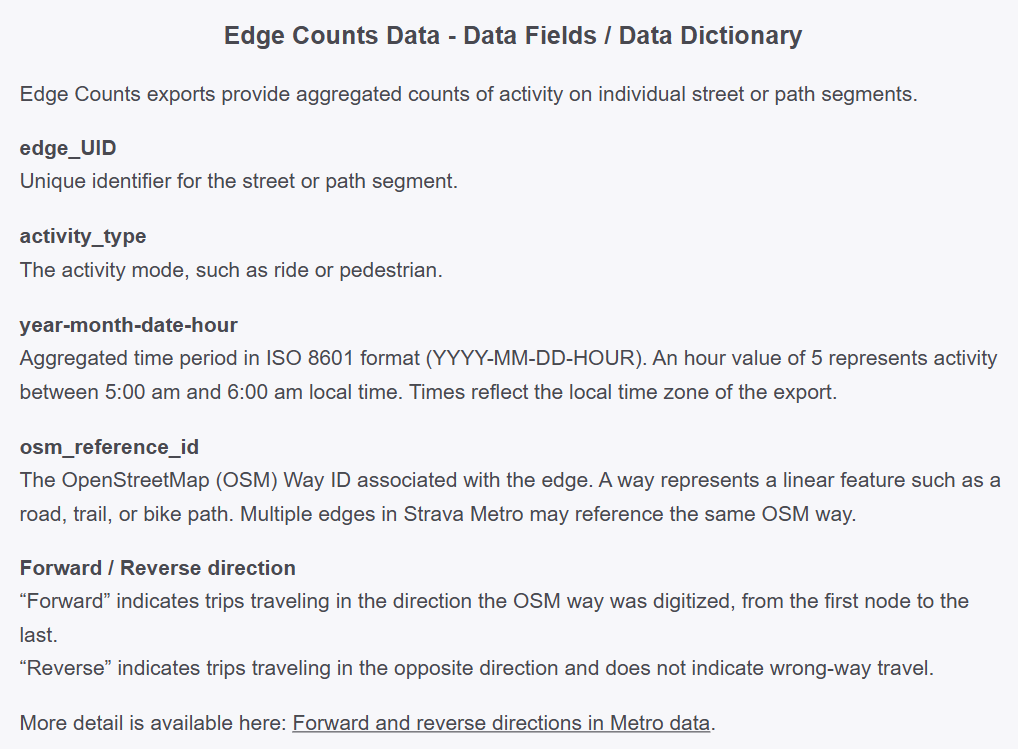
- 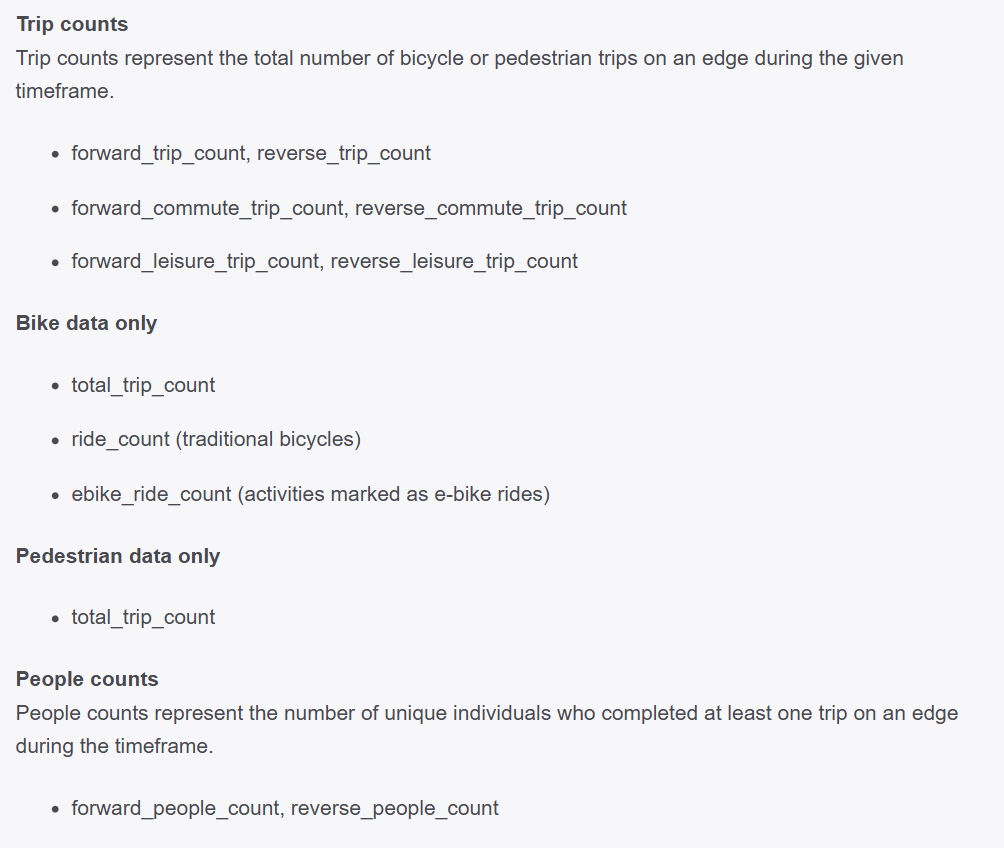
- 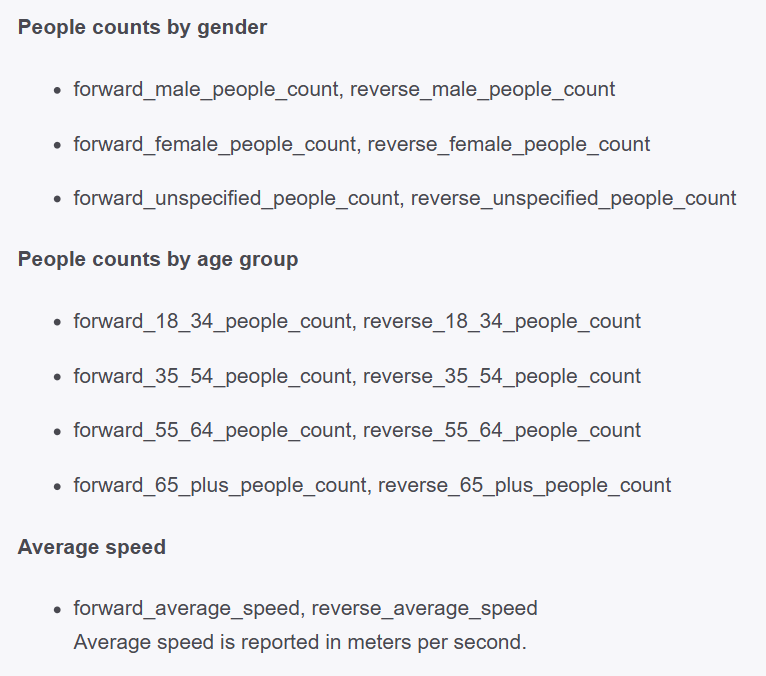

In [ ]:
gdf_edges = gpd.read_file("./data/strava/all_data/all_trips_geometries.shp")
gdf_edges.head()

In [ ]:
def add_layers(m):
    """Add multiple base tile layers to a Folium map.
    
    Adds OpenStreetMap, Stamen Terrain, Stamen Toner, CartoDB Positron,
    and CartoDB Dark Matter as selectable tile layers.
    
    Parameters
    ----------
    m : folium.Map
        Map instance to add layers to.
    
    Returns
    -------
    folium.Map
        The same map instance with layers added.
    """
    folium.TileLayer(
        tiles="OpenStreetMap",
        name="OpenStreetMap",
        control=True
    ).add_to(m)
    
    folium.TileLayer(
        tiles="Stamen Terrain",
        name="Stamen Terrain",
        attr="Map tiles by Stamen Design, CC BY 3.0 — Data © OpenStreetMap contributors",
        control=True
    ).add_to(m)
    
    folium.TileLayer(
        tiles="Stamen Toner",
        name="Stamen Toner",
        attr="Map tiles by Stamen Design, CC BY 3.0 — Data © OpenStreetMap contributors",
        control=True
    ).add_to(m)
    
    folium.TileLayer(
        tiles="CartoDB positron",
        name="CartoDB positron",
        control=True
    ).add_to(m)
    
    folium.TileLayer(
        tiles="CartoDB dark_matter",
        name="CartoDB dark_matter",
        control=True
    ).add_to(m)
    return m
# gdf = gdf[0:500]

In [ ]:
# Converter coluna hour para datetime
edge_count['datetime'] = pd.to_datetime(edge_count['hour'])
edge_count['date'] = edge_count['datetime'].dt.date
edge_count['hour_int'] = edge_count['datetime'].dt.hour
edge_count['day_of_week'] = edge_count['datetime'].dt.dayofweek
edge_count['week'] = edge_count['datetime'].dt.isocalendar().week
count_cols = COUNT_COLS

In [ ]:
# Função auxiliar para identificar outliers IQR
def identify_outliers_iqr(series, k=1.5):
    """Classify each value as normal or IQR outlier and return the fences.

    Parameters
    ----------
    series : pd.Series
        Numeric series to evaluate.
    k : float, optional
        IQR multiplier for fence calculation (default 1.5).
    
    Returns
    -------
    outlier_type : pd.Series of str
        Classification per value: 'Normal', 'Outlier Inferior', or 'Outlier Superior'.
    lower : float
        Lower fence (Q1 - k * IQR).
    upper : float
        Upper fence (Q3 + k * IQR).
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    
    outlier_type = pd.Series('Normal', index=series.index)
    outlier_type[series < lower] = 'Outlier Inferior'
    outlier_type[series > upper] = 'Outlier Superior'
    
    return outlier_type, lower, upper

In [ ]:
def _filter_edges(edge_count, start_date, end_date, start_hour, end_hour):
    """Filter edge_count by date range and hour range.

    Parameters
    ----------
    edge_count : DataFrame
        Raw edge data with 'datetime' and 'hour_int' columns.
    start_date, end_date : datetime
        Inclusive date bounds.
    start_hour, end_hour : int
        Inclusive hour bounds.

    Returns
    -------
    DataFrame
        Filtered copy.
    """
    mask = (
        (edge_count["datetime"] >= start_date)
        & (edge_count["datetime"] <= end_date)
        & (edge_count["hour_int"] >= start_hour)
        & (edge_count["hour_int"] <= end_hour)
    )
    return edge_count[mask].copy()


def _aggregate_and_merge(df_filtered, gdf, metric, iqr_k):
    """Aggregate metric per edge, tag outliers, and merge with geometry.

    Parameters
    ----------
    df_filtered : DataFrame
        Time-filtered edge data.
    gdf : GeoDataFrame
        Edge geometries with 'osmId' column.
    metric : str
        Column name to aggregate (sum).
    iqr_k : float
        IQR multiplier for outlier detection.

    Returns
    -------
    GeoDataFrame or None
        Merged data with 'value' and 'outlier_type' columns, or None if empty.
    lower : float
        Lower IQR fence.
    upper : float
        Upper IQR fence.
    """
    agg = df_filtered.groupby("edge_uid")[metric].sum().reset_index()
    agg.columns = ["edge_uid", "value"]

    outlier_type, lower, upper = identify_outliers_iqr(agg["value"], k=iqr_k)
    agg["outlier_type"] = outlier_type

    edge_osm = df_filtered[["edge_uid", "osm_reference_id"]].drop_duplicates()
    gdf_merged = gdf.merge(
        edge_osm, left_on="osmId", right_on="osm_reference_id", how="inner"
    )
    gdf_merged = gdf_merged.merge(agg, on="edge_uid", how="inner")

    if len(gdf_merged) == 0:
        return None, lower, upper
    return gdf_merged, lower, upper

def _get_edge_color_and_style(row, show_outliers, vmin, vmax, cmap):
    """Return color, weight, and opacity for a single edge row.

    Parameters
    ----------
    row : Series
        Row with 'value' and 'outlier_type'.
    show_outliers : bool
        Whether to highlight outliers with distinct colors.
    vmin, vmax : float
        Value range for normal data normalization.
    cmap : matplotlib colormap
        Colormap for gradient.

    Returns
    -------
    tuple of (str, int, float)
        (hex color, line weight, opacity).
    """
    if show_outliers and row["outlier_type"] == "Upper Outlier":
        return "#8B0000", 6, 0.9
    if show_outliers and row["outlier_type"] == "Lower Outlier":
        return "#00008B", 6, 0.9

    normalized = (row["value"] - vmin) / (vmax - vmin) if vmax > vmin else 0.5
    color = mcolors.rgb2hex(cmap(normalized))
    return color, 4, 0.7


def _add_edges_to_map(m, gdf_merged, show_outliers, metric, color_scheme):
    """Draw colored PolyLines on the map for each edge.

    Parameters
    ----------
    m : folium.Map
        Target map.
    gdf_merged : GeoDataFrame
        Edges with 'value', 'outlier_type', and geometry.
    show_outliers : bool
        Highlight outliers with distinct colors.
    metric : str
        Metric name for tooltips.
    color_scheme : str
        Matplotlib colormap name.

    Returns
    -------
    tuple of (float, float)
        (vmin, vmax) used for normal data range.
    """
    cmap = cm.get_cmap(color_scheme)
    gdf_normal = gdf_merged[gdf_merged["outlier_type"] == "Normal"]

    if len(gdf_normal) > 0:
        vmin, vmax = gdf_normal["value"].min(), gdf_normal["value"].max()
    else:
        vmin, vmax = gdf_merged["value"].min(), gdf_merged["value"].max()

    for _, row in gdf_merged.iterrows():
        color, weight, opacity = _get_edge_color_and_style(
            row, show_outliers, vmin, vmax, cmap
        )
        folium.PolyLine(
            locations=[(c[1], c[0]) for c in row["geometry"].coords],
            color=color,
            weight=weight,
            opacity=opacity,
            tooltip=f"{metric}: {row['value']:.0f}<br>Tipo: {row['outlier_type']}",
        ).add_to(m)

    return vmin, vmax

def _build_gradient_legend_html(metric, vmin, vmax, color_scheme, lower, upper,
                                n_outlier_sup, n_outlier_inf, gdf_merged,
                                start_date, end_date, start_hour, end_hour, iqr_k):
    """Build the legend HTML with gradient bar and statistics.

    Parameters
    ----------
    metric : str
        Metric name.
    vmin, vmax : float
        Normal value range.
    color_scheme : str
        Matplotlib colormap name.
    lower, upper : float
        IQR fences.
    n_outlier_sup, n_outlier_inf : int
        Outlier counts.
    gdf_merged : GeoDataFrame
        Merged edge data.
    start_date, end_date : datetime
        Date range.
    start_hour, end_hour : int
        Hour range.
    iqr_k : float
        IQR multiplier.

    Returns
    -------
    str
        HTML string.
    """
    cmap = cm.get_cmap(color_scheme)
    steps = 10

    gradient_html = '<div style="display: flex; flex-direction: column; margin: 10px 0;">'
    for i in range(steps, -1, -1):
        normalized = i / steps
        color = mcolors.rgb2hex(cmap(normalized))
        gradient_html += (
            f'<div style="background: {color}; height: 15px; '
            f'border: 1px solid #ccc;"></div>'
        )
    gradient_html += "</div>"

    return f"""
    <div style="position: fixed; top: 10px; right: 10px; width: 260px;
                background-color: white; border: 2px solid grey; z-index: 9999;
                padding: 12px; border-radius: 5px; box-shadow: 0 0 15px rgba(0,0,0,0.2);">
    <div style="font-weight: bold; font-size: 14px; margin-bottom: 10px;
                border-bottom: 2px solid #333; padding-bottom: 5px;">
        {metric}
    </div>
    <div style="margin-bottom: 10px;">
        <b>Gradiente (Normal):</b><br>
        <div style="display: flex; align-items: center;">
            <div style="flex: 1;">{gradient_html}</div>
            <div style="margin-left: 10px; display: flex; flex-direction: column;
                        justify-content: space-between; height: {(steps + 1) * 15}px;">
                <span style="font-size: 10px;">{vmax:.0f}</span>
                <span style="font-size: 10px;">{vmin:.0f}</span>
            </div>
        </div>
        <div style="text-align: center; font-size: 9px; color: #666; margin-top: 3px;">
            Mais escuro = Maior intensidade
        </div>
    </div>
    <div style="margin-bottom: 10px;">
        <b>Outliers:</b><br>
        <span style="color: #8B0000; font-size: 20px;">&#9632;</span>
        Superior (&gt;{upper:.0f}) - {n_outlier_sup}<br>
        <span style="color: #00008B; font-size: 20px;">&#9632;</span>
        Inferior (&lt;{lower:.0f}) - {n_outlier_inf}
    </div>
    <div style="font-size: 11px; color: #666; border-top: 1px solid #ccc; padding-top: 8px;">
        <b>Estatisticas:</b><br>
        Periodo: {start_date.strftime('%d/%m')} - {end_date.strftime('%d/%m/%Y')}<br>
        Horario: {start_hour}h - {end_hour}h<br>
        Total edges: {len(gdf_merged)}<br>
        Total: {gdf_merged['value'].sum():,.0f}<br>
        Media: {gdf_merged['value'].mean():.1f}<br>
        IQR k: {iqr_k}
    </div>
    </div>
    """

def create_edge_gradient_map(edge_count, gdf, metric, start_date, end_date,
                             start_hour, end_hour, color_scheme="YlOrRd",
                             show_outliers=True, iqr_k=1.5):
    """Create a Folium map with gradient-colored edges based on a metric.

    Filters edges by date/hour, aggregates the metric per edge, detects
    IQR outliers, and renders colored PolyLines with a gradient legend.

    Parameters
    ----------
    edge_count : DataFrame
        Raw edge data with 'datetime', 'hour_int', 'edge_uid', and metric columns.
    gdf : GeoDataFrame
        Edge geometries with 'osmId' column.
    metric : str
        Column name to aggregate and visualize.
    start_date, end_date : datetime
        Inclusive date range.
    start_hour, end_hour : int
        Inclusive hour range.
    color_scheme : str, optional
        Matplotlib colormap name (default 'YlOrRd').
    show_outliers : bool, optional
        Highlight outliers with distinct colors (default True).
    iqr_k : float, optional
        IQR multiplier for outlier fences (default 1.5).

    Returns
    -------
    folium.Map or None
        The generated map, or None if no data matches the filters.
    """
    df_filtered = _filter_edges(edge_count, start_date, end_date,
                                start_hour, end_hour)
    if len(df_filtered) == 0:
        print("No data for the selected date/hour range.")
        return None

    gdf_merged, lower, upper = _aggregate_and_merge(
        df_filtered, gdf, metric, iqr_k
    )
    if gdf_merged is None:
        print("No corresponding geometries found.")
        return None

    n_outlier_sup = (gdf_merged["outlier_type"] == "Upper Outlier").sum()
    n_outlier_inf = (gdf_merged["outlier_type"] == "Lower Outlier").sum()
    n_normal = (gdf_merged["outlier_type"] == "Normal").sum()

    print(f"Interval: {start_date.strftime('%Y-%m-%d')} a {end_date.strftime('%Y-%m-%d')}")
    print(f"Time: {start_hour}h-{end_hour}h | Metric: {metric}")
    print(f"Edges with data: {len(gdf_merged)} "
          f"(Normal: {n_normal}, Sup: {n_outlier_sup}, Inf: {n_outlier_inf})")
    print(f"Total: {gdf_merged['value'].sum():,.0f} | "
          f"Mean: {gdf_merged['value'].mean():.1f} | "
          f"Min: {gdf_merged['value'].min():.0f} | "
          f"Max: {gdf_merged['value'].max():.0f}")

    bounds = gdf_merged.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=13, tiles="CartoDB positron")

    vmin, vmax = _add_edges_to_map(m, gdf_merged, show_outliers, metric, color_scheme)

    legend = _build_gradient_legend_html(
        metric, vmin, vmax, color_scheme, lower, upper,
        n_outlier_sup, n_outlier_inf, gdf_merged,
        start_date, end_date, start_hour, end_hour, iqr_k,
    )
    m.get_root().html.add_child(folium.Element(legend))

    return m

def create_gradient_map_widgets(edge_count, gdf, all_metrics, color_schemes):
    """Create and display ipywidgets for interactive gradient map generation.

    Parameters
    ----------
    edge_count : DataFrame
        Raw edge data.
    gdf : GeoDataFrame
        Edge geometries.
    all_metrics : list of str
        Available metric column names.
    color_schemes : list of str
        Available matplotlib colormap names.
    """
    metric_w = widgets.Dropdown(
        options=all_metrics, value="total_trip_count", description="Metric:"
    )
    start_date_w = widgets.DatePicker(
        value=edge_count["date"].min(), description="Start Date:"
    )
    end_date_w = widgets.DatePicker(
        value=edge_count["date"].max(), description="End Date:"
    )
    start_hour_w = widgets.IntSlider(
        value=0, min=0, max=23, description="Start Hour:"
    )
    end_hour_w = widgets.IntSlider(
        value=23, min=0, max=23, description="End Hour:"
    )
    color_w = widgets.Dropdown(
        options=color_schemes, value="YlOrRd", description="Color Scheme:"
    )
    outliers_w = widgets.Checkbox(value=True, description="Highlight Outliers")
    iqr_k_w = widgets.FloatSlider(
        value=1.5, min=1.0, max=3.0, step=0.5, description="IQR k:"
    )
    button = widgets.Button(description="Generate Map")
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output()
            m = create_edge_gradient_map(
                edge_count, gdf,
                metric_w.value,
                pd.to_datetime(start_date_w.value),
                pd.to_datetime(end_date_w.value),
                start_hour_w.value,
                end_hour_w.value,
                color_w.value,
                outliers_w.value,
                iqr_k_w.value,
            )
            if m:
                display(m)

    button.on_click(on_click)

    display(
        metric_w, start_date_w, end_date_w, start_hour_w, end_hour_w,
        color_w, outliers_w, iqr_k_w, button, output,
    )

In [ ]:
def compare_directions(metric_base, edge_count, remove_outliers=False, iqr_k=1.5,
                       save_dir=None, save_prefix=""):
    """Compara fluxos forward vs reverse para uma metrica.

    Parameters
    ----------
    metric_base : str
        Nome base da metrica (ex: 'trip_count', 'people_count').
    edge_count : DataFrame
        Dataset de edges com colunas forward_/reverse_.
    remove_outliers : bool
        Se True, remove outliers IQR antes de plotar (default False).
    iqr_k : float
        Multiplicador IQR (default 1.5).
    save_dir : str or None
        Diretorio para salvar figuras (default None).
    save_prefix : str
        Prefixo para nomes dos arquivos salvos (default "").
    """
    forward_col = f'forward_{metric_base}'
    reverse_col = f'reverse_{metric_base}'

    if forward_col not in edge_count.columns or reverse_col not in edge_count.columns:
        print(f"Colunas {forward_col} ou {reverse_col} nao encontradas")
        return

    df = edge_count.groupby('edge_uid').agg({
        forward_col: 'sum',
        reverse_col: 'sum'
    }).reset_index()

    df['total'] = df[forward_col] + df[reverse_col]
    df['difference'] = df[forward_col] - df[reverse_col]
    df['dominant_direction'] = df['difference'].apply(
        lambda x: 'Forward' if x > 0 else ('Reverse' if x < 0 else 'Balanced')
    )

    if remove_outliers:
        for col in [forward_col, reverse_col]:
            q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            iqr = q3 - q1
            df = df[(df[col] >= q1 - iqr_k * iqr) & (df[col] <= q3 + iqr_k * iqr)]
        df['difference'] = df[forward_col] - df[reverse_col]
        df['total'] = df[forward_col] + df[reverse_col]
        df['dominant_direction'] = df['difference'].apply(
            lambda x: 'Forward' if x > 0 else ('Reverse' if x < 0 else 'Balanced')
        )

    total_fwd = df[forward_col].sum()
    total_rev = df[reverse_col].sum()
    print(f"Comparison: {forward_col} vs {reverse_col}")
    print(f"Total Forward: {total_fwd:,.0f}")
    print(f"Total Reverse: {total_rev:,.0f}")
    print(f"Ratio F/R: {total_fwd / max(total_rev, 1):.2f}")
    print(f"Distribution: {df['dominant_direction'].value_counts().to_dict()}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. Hexbin (log-log, filtering zeros)
    mask_pos = (df[forward_col] > 0) & (df[reverse_col] > 0)
    df_pos = df[mask_pos]

    if len(df_pos) > 0:
        hb = axes[0, 0].hexbin(df_pos[forward_col], df_pos[reverse_col],
                                gridsize=60, cmap='Blues', mincnt=1,
                                xscale='log', yscale='log')
        max_val = max(df_pos[forward_col].max(), df_pos[reverse_col].max())
        axes[0, 0].plot([1, max_val], [1, max_val], 'r--', lw=1.5, label='Equilibrium')
        fig.colorbar(hb, ax=axes[0, 0], label='Count')
        axes[0, 0].legend()
    axes[0, 0].set_xlabel('Forward (log)')
    axes[0, 0].set_ylabel('Reverse (log)')
    axes[0, 0].set_title(f'Forward vs Reverse - {metric_base}')

    # 2. Histogram of differences (y-axis in log)
    diff_nonzero = df['difference'][df['difference'] != 0]
    if len(diff_nonzero) > 0:
        axes[0, 1].hist(diff_nonzero, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
        axes[0, 1].set_yscale('log')
    axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
    axes[0, 1].axvline(df['difference'].median(), color='orange', linestyle='-', linewidth=1.5,
                        label=f"Mediana: {df['difference'].median():.0f}")
    axes[0, 1].set_xlabel('Difference (Forward - Reverse)')
    axes[0, 1].set_ylabel('Frequency (log)')
    axes[0, 1].set_title('Distribution of Differences')
    axes[0, 1].legend()

    # 3. Stacked bars by volume range
    try:
        df['volume_bin'] = pd.qcut(df['total'], q=5, duplicates='drop')
        stacked = df.groupby('volume_bin')['dominant_direction'].value_counts(normalize=True).unstack(fill_value=0)
        color_map = {'Forward': '#1f77b4', 'Reverse': '#d62728', 'Balanced': '#2ca02c'}
        stacked.plot(kind='barh', stacked=True, ax=axes[1, 0],
                     color=[color_map.get(c, '#999') for c in stacked.columns])
        axes[1, 0].set_xlabel('Proportion')
        axes[1, 0].set_ylabel('Total Volume Range')
        axes[1, 0].set_title('Dominant Direction by Volume Range')
        axes[1, 0].legend(title='Direction', loc='lower right')
    except ValueError:
        axes[1, 0].text(0.5, 0.5, 'Insufficient data for bins', ha='center', va='center',
                        transform=axes[1, 0].transAxes)

    # 4. Boxplot with log scale (without outliers)
    fwd_data = df[forward_col][df[forward_col] > 0].values
    rev_data = df[reverse_col][df[reverse_col] > 0].values
    if len(fwd_data) > 0 and len(rev_data) > 0:
        axes[1, 1].boxplot([fwd_data, rev_data],
                           labels=['Forward', 'Reverse'], showfliers=False,
                           medianprops=dict(color='red', linewidth=2))
        axes[1, 1].set_yscale('log')
    axes[1, 1].set_ylabel(f'{metric_base} (log)')
    axes[1, 1].set_title('Distribution Forward vs Reverse')

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    out_label = f" (without outliers, IQR k={iqr_k})" if remove_outliers else ""
    fig.suptitle(f"Directional Analysis - {metric_base}{out_label}", fontsize=16)

    try:
        plt.tight_layout()
    except ValueError:
        pass

    if save_dir:
        path = Path(save_dir)
        path.mkdir(parents=True, exist_ok=True)
        fig.savefig(path / f"{save_prefix}direction_{metric_base}.png",
                    dpi=150, bbox_inches="tight")
    plt.show()


def compare_directions_widget(edge_count):
    """Interactive widget to compare forward vs reverse directions for a selected metric.

    Parameters
    ----------
    edge_count : DataFrame
        Edge data.
    """
    from ipywidgets import interact, widgets

    metric_widget = widgets.Dropdown(
        options=['trip_count', 'people_count', 'commute_trip_count',
                 'leisure_trip_count', 'male_people_count', 'female_people_count',
                 'unspecified_people_count', '18_34_people_count',
                 '35_54_people_count', '55_64_people_count', '65_plus_people_count',
                 'average_speed_meters_per_second'],
        value='trip_count',
        description='Metric:', style={'description_width': 'initial'}
    )
    remove_outliers_widget = widgets.Checkbox(
        value=False, description='Remove outliers (IQR)',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update(metric, remove_outliers, iqr_k):
        compare_directions(metric, edge_count,
                          remove_outliers=remove_outliers,
                          iqr_k=iqr_k,
                          save_dir="figs/direction_analysis")

    interact(update,
             metric=metric_widget,
             remove_outliers=remove_outliers_widget,
             iqr_k=iqr_k_widget)

In [ ]:
compare_directions_widget(edge_count)

In [ ]:
def create_direction_map(metric_base, edge_count, gdf_edges,
                         min_trips=10, top_n=500, show_outliers=True, iqr_k=1.5,
                         save_path=None):
    """Dominant direction map per edge, limited to top_n largest and smallest balances.

    Parameters
    ----------
    metric_base : str
        Base metric name (e.g. 'trip_count').
    edge_count : DataFrame
        Aggregated edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries with 'edge_uid' column.
    min_trips : int
        Minimum total trips to include edge (default 10).
    top_n : int
        Number of edges with largest and smallest balance to display (default 500).
    show_outliers : bool
        If True, highlights outliers with a distinct color (default True).
    iqr_k : float
        IQR multiplier (default 1.5).
    save_path : str or None
        Path to save the HTML map (default None).

    Returns
    -------
    folium.Map or None
    """
    forward_col = f'forward_{metric_base}'
    reverse_col = f'reverse_{metric_base}'

    if forward_col not in edge_count.columns or reverse_col not in edge_count.columns:
        print(f"Columns {forward_col} or {reverse_col} not found")
        return None

    df_dir = edge_count.groupby('edge_uid').agg({
        forward_col: 'sum',
        reverse_col: 'sum'
    }).reset_index()

    df_dir['total'] = df_dir[forward_col] + df_dir[reverse_col]
    df_dir = df_dir[df_dir['total'] >= min_trips].copy()
    df_dir['difference'] = df_dir[forward_col] - df_dir[reverse_col]
    df_dir['abs_diff'] = df_dir['difference'].abs()

    top_forward = df_dir.nlargest(top_n, 'difference')
    top_reverse = df_dir.nsmallest(top_n, 'difference')
    df_dir = pd.concat([top_forward, top_reverse]).drop_duplicates(subset='edge_uid')

    q1 = df_dir['difference'].quantile(0.25)
    q3 = df_dir['difference'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr

    df_dir['outlier_type'] = 'Normal'
    df_dir.loc[df_dir['difference'] > upper, 'outlier_type'] = 'Upper Outlier'
    df_dir.loc[df_dir['difference'] < lower, 'outlier_type'] = 'Lower Outlier'

    gdf_dir = gdf_edges[['edge_uid', 'geometry']].merge(df_dir, on='edge_uid', how='inner')
    gdf_dir = gpd.GeoDataFrame(gdf_dir, geometry='geometry')

    if len(gdf_dir) == 0:
        print("No data for the given parameters")
        return None

    gdf_dir = gdf_dir.to_crs(epsg=4326)

    n_outlier_sup = (gdf_dir['outlier_type'] == 'Upper Outlier').sum()
    n_outlier_inf = (gdf_dir['outlier_type'] == 'Lower Outlier').sum()
    n_normal = (gdf_dir['outlier_type'] == 'Normal').sum()
    n_fwd = (gdf_dir['difference'] > 0).sum()
    n_rev = (gdf_dir['difference'] < 0).sum()
    n_bal = (gdf_dir['difference'] == 0).sum()

    print(f"Edges displayed: {len(gdf_dir)} (top {top_n} forward + top {top_n} reverse)")
    print(f"Minimum trips: {min_trips}")
    print(f"  Forward: {n_fwd} | Reverse: {n_rev} | Balanced: {n_bal}")
    print(f"  Upper Outlier: {n_outlier_sup} | Lower Outlier: {n_outlier_inf}")

    bounds = gdf_dir.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=12, tiles=None)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    max_diff = gdf_dir.loc[gdf_dir['outlier_type'] == 'Normal', 'abs_diff'].max()
    if pd.isna(max_diff) or max_diff == 0:
        max_diff = gdf_dir['abs_diff'].max()
    if max_diff == 0:
        max_diff = 1

    layer_defs = [
        ('Forward', gdf_dir[(gdf_dir['outlier_type'] == 'Normal') & (gdf_dir['difference'] > 0)],
         '#ff8080', 3, False),
        ('Reverse', gdf_dir[(gdf_dir['outlier_type'] == 'Normal') & (gdf_dir['difference'] < 0)],
         '#91bfdb', 3, False),
        ('Balanced', gdf_dir[(gdf_dir['outlier_type'] == 'Normal') & (gdf_dir['difference'] == 0)],
         '#f7f7f7', 3, False),
        ('Extreme Forward', gdf_dir[gdf_dir['outlier_type'] == 'Upper Outlier'],
         '#d62728', 5, True),
        ('Extreme Reverse', gdf_dir[gdf_dir['outlier_type'] == 'Lower Outlier'],
         '#4575b4', 5, True),
    ]

    for layer_name, subset, color, weight, is_outlier in layer_defs:
        if is_outlier and not show_outliers:
            continue
        if subset.empty:
            continue

        subset = subset.copy()
        if is_outlier:
            subset['_opacity'] = 0.9
        else:
            subset['_opacity'] = subset['abs_diff'].apply(
                lambda x: min(0.9, 0.3 + (x / max_diff) * 0.6)
            )

        fg = folium.FeatureGroup(name=layer_name, show=True)

        folium.GeoJson(
            subset,
            style_function=lambda feat, c=color, w=weight: {
                'color': c,
                'weight': w,
                'opacity': feat['properties'].get('_opacity', 0.7),
            },
            tooltip=folium.features.GeoJsonTooltip(
                fields=['edge_uid', forward_col, reverse_col, 'difference', 'total'],
                aliases=['Edge:', 'Forward:', 'Reverse:', 'Balance:', 'Total:'],
                localize=True, sticky=False, labels=True,
                style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
            ),
        ).add_to(fg)

        fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    legend_html = f'''
    <div style="position:fixed;top:10px;left:10px;width:240px;
                background-color:white;border:2px solid grey;z-index:9999;
                padding:10px;border-radius:5px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Dominant Direction</h4>
    <b>Top {top_n} per direction</b><br><br>
    <span style="color:#ff8080;font-size:20px;">&#9632;</span> Forward ({n_fwd})<br>
    <span style="color:#91bfdb;font-size:20px;">&#9632;</span> Reverse ({n_rev})<br>
    <span style="color:#f7f7f7;font-size:20px;">&#9632;</span> Balanced ({n_bal})<br><br>
    <b>Outliers (IQR k={iqr_k}):</b><br>
    <span style="color:#d62728;font-size:20px;">&#9632;</span> Extreme Forward ({n_outlier_sup})<br>
    <span style="color:#4575b4;font-size:20px;">&#9632;</span> Extreme Reverse ({n_outlier_inf})<br><br>
    <div style="font-size:10px;color:#666;">
    Balance limits:<br>
    Upper: &gt;{upper:.0f}<br>
    Lower: &lt;{lower:.0f}<br>
    Min trips: {min_trips}<br>
    Edges displayed: {len(gdf_dir)}
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        m.save(save_path)
        print(f"Map saved: {save_path}")

    return m


def create_direction_map_widget(edge_count, gdf_edges):
    """Interactive interface for the dominant direction map.

    Parameters
    ----------
    edge_count : DataFrame
        Edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries.
    """
    from ipywidgets import interact, widgets

    metric_options = ['trip_count', 'people_count', 'commute_trip_count',
                      'leisure_trip_count', 'male_people_count', 'female_people_count',
                      'unspecified_people_count', '18_34_people_count',
                      '35_54_people_count', '55_64_people_count', '65_plus_people_count']

    metric_widget = widgets.Dropdown(
        options=metric_options, value='trip_count',
        description='Metric:', style={'description_width': 'initial'}
    )
    min_trips_widget = widgets.IntSlider(
        value=10, min=1, max=500, step=5,
        description='Min trips:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=500, min=50, max=50000, step=50,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    show_outliers_widget = widgets.Checkbox(
        value=True, description='Highlight outliers',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update(metric, min_trips, top_n, show_outliers, iqr_k):
        m = create_direction_map(
            metric_base=metric,
            edge_count=edge_count,
            gdf_edges=gdf_edges,
            min_trips=min_trips,
            top_n=top_n,
            show_outliers=show_outliers,
            iqr_k=iqr_k,
            save_path=f"analises/mapa_direcao_{metric}_top{top_n}.html"
        )
        if m:
            display(m)

    interact(update,
             metric=metric_widget,
             min_trips=min_trips_widget,
             top_n=top_n_widget,
             show_outliers=show_outliers_widget,
             iqr_k=iqr_k_widget)

In [ ]:
create_direction_map_widget(edge_count, gdf_edges)


In [ ]:
def analyze_demographics():
    """Detailed demographic analysis of Strava Metro edges.

    Displays charts, tables, and indices for gender, age group, direction,
    trip type (commute/leisure), and average speed by profile.
    """
    
    df = edge_count.copy()

    # Total aggregated 
    total_people = df['forward_people_count'].sum() + df['reverse_people_count'].sum()

    # Gender (forward + reverse)
    male   = df['forward_male_people_count'].sum()   + df['reverse_male_people_count'].sum()
    female = df['forward_female_people_count'].sum() + df['reverse_female_people_count'].sum()
    unspec = df['forward_unspecified_people_count'].sum() + df['reverse_unspecified_people_count'].sum()

    # age groups (forward + reverse)
    age_18_34 = df['forward_18_34_people_count'].sum() + df['reverse_18_34_people_count'].sum()
    age_35_54 = df['forward_35_54_people_count'].sum() + df['reverse_35_54_people_count'].sum()
    age_55_64 = df['forward_55_64_people_count'].sum() + df['reverse_55_64_people_count'].sum()
    age_65p   = df['forward_65_plus_people_count'].sum() + df['reverse_65_plus_people_count'].sum()

    age_vals   = [age_18_34, age_35_54, age_55_64, age_65p]
    age_labels = ['18–34', '35–54', '55–64', '65+']

    # Commute vs leisure
    commute = df['forward_commute_trip_count'].sum() + df['reverse_commute_trip_count'].sum()
    leisure = df['forward_leisure_trip_count'].sum()  + df['reverse_leisure_trip_count'].sum()

    # Direction
    fwd_trips = df['forward_trip_count'].sum()
    rev_trips = df['reverse_trip_count'].sum()

    # Average speed weighted by trip count
    df['fwd_speed_w'] = df['forward_average_speed_meters_per_second'] * df['forward_trip_count']
    df['rev_speed_w'] = df['reverse_average_speed_meters_per_second'] * df['reverse_trip_count']
    spd_fwd = df['fwd_speed_w'].sum() / fwd_trips * 3.6 if fwd_trips > 0 else 0
    spd_rev = df['rev_speed_w'].sum() / rev_trips * 3.6 if rev_trips > 0 else 0

    # Derived indices
    gender_ratio   = male / female if female > 0 else float('inf')
    female_share   = female / (male + female + unspec) * 100
    youth_share    = age_18_34 / sum(age_vals) * 100 if sum(age_vals) > 0 else 0
    senior_share   = (age_55_64 + age_65p) / sum(age_vals) * 100 if sum(age_vals) > 0 else 0
    commute_share  = commute / (commute + leisure) * 100 if (commute + leisure) > 0 else 0
    coverage_age   = sum(age_vals) / total_people * 100 if total_people > 0 else 0
    coverage_gen   = (male + female + unspec) / total_people * 100 if total_people > 0 else 0

    # Edges by demographic share (forward direction)
    df['female_share_edge']  = df['forward_female_people_count'] / df['forward_people_count'].replace(0, np.nan)
    df['youth_share_edge']   = df['forward_18_34_people_count']  / df['forward_people_count'].replace(0, np.nan)
    df['senior_share_edge']  = (df['forward_55_64_people_count'] + df['forward_65_plus_people_count']) / df['forward_people_count'].replace(0, np.nan)
    df['commute_share_edge'] = df['forward_commute_trip_count']  / df['forward_trip_count'].replace(0, np.nan)


    fig = plt.figure(figsize=(18, 22))
    gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.4)

    BLUE   = '#2c7bb6'
    PINK   = '#d7191c'
    GRAY   = '#bdbdbd'
    GREENS = ['#ffffb2', '#fecc5c', '#fd8d3c', '#e31a1c']

    # Pie Chart (gender)
    ax1 = fig.add_subplot(gs[0, 0])
    gender_vals = [male, female, unspec]
    gender_lbls = ['Masculino', 'Feminino', 'Não especificado']
    colors_g    = [BLUE, PINK, GRAY]
    wedges, texts, autotexts = ax1.pie(
        gender_vals, labels=gender_lbls, autopct='%1.1f%%',
        startangle=90, colors=colors_g,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    ax1.set_title('Distribuição por Gênero', fontweight='bold')

    # Bar Chart (age groups)
    ax2 = fig.add_subplot(gs[0, 1])
    bars = ax2.bar(age_labels, age_vals, color=GREENS, edgecolor='black', linewidth=0.7)
    ax2.set_ylabel('Total de Pessoas')
    ax2.set_title('Distribuição por Faixa Etária', fontweight='bold')
    ax2.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, age_vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(age_vals)*0.01,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

    # Pie Chart (commute vs leisure)
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.pie([commute, leisure], labels=['Commute', 'Lazer'], autopct='%1.1f%%',
            startangle=90, colors=['#f46d43', '#74add1'],
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax3.set_title('Commute vs Lazer', fontweight='bold')

    # Directional comparison (total forward vs reverse trips)
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.barh(['Forward', 'Reverse'], [fwd_trips, rev_trips],
             color=[BLUE, '#a50f15'], edgecolor='black', linewidth=0.7)
    ax4.set_xlabel('Total de Viagens')
    ax4.set_title('Viagens por Direção', fontweight='bold')
    ax4.grid(alpha=0.3, axis='x')
    for i, v in enumerate([fwd_trips, rev_trips]):
        ax4.text(v + max(fwd_trips, rev_trips)*0.01, i, f'{v:,.0f}', va='center', fontsize=9)

    # Average speed comparison (forward vs reverse)
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.bar(['Forward', 'Reverse'], [spd_fwd, spd_rev],
            color=[BLUE, '#a50f15'], edgecolor='black', linewidth=0.7)
    ax5.set_ylabel('km/h')
    ax5.set_title('Velocidade Média Ponderada', fontweight='bold')
    ax5.grid(alpha=0.3, axis='y')
    for i, v in enumerate([spd_fwd, spd_rev]):
        ax5.text(i, v + 0.1, f'{v:.2f} km/h', ha='center', fontsize=10, fontweight='bold')

    # % female by edge (histogram)
    ax6 = fig.add_subplot(gs[1, 2])
    female_by_age = [
        df['forward_female_people_count'].sum(),
        df['forward_female_people_count'].sum(),   # placeholder — ajuste se tiver coluna por faixa+gênero
    ]
    # Ratio F/M por edge (forward direction)
    fem_ratio = (df['forward_female_people_count'] /
                 df['forward_male_people_count'].replace(0, np.nan)).dropna()
    fem_ratio = fem_ratio[fem_ratio < 5]  # remove outliers extremos
    ax6.hist(fem_ratio, bins=30, color=PINK, edgecolor='white', alpha=0.85)
    ax6.axvline(fem_ratio.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Mediana: {fem_ratio.median():.2f}')
    ax6.set_xlabel('Razão Feminino / Masculino por Edge')
    ax6.set_ylabel('Nº de Edges')
    ax6.set_title('Distribuição da Razão F/M por Edge', fontweight='bold')
    ax6.legend(fontsize=9)
    ax6.grid(alpha=0.3)

    # % youth by edge (histogram)
    ax7 = fig.add_subplot(gs[2, 0])
    youth_pct = (df['youth_share_edge'].dropna() * 100)
    ax7.hist(youth_pct, bins=30, color='#74c476', edgecolor='white', alpha=0.85)
    ax7.axvline(youth_pct.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Mediana: {youth_pct.median():.1f}%')
    ax7.set_xlabel('% Jovens (18–34) por Edge')
    ax7.set_ylabel('Nº de Edges')
    ax7.set_title('Concentração de Jovens por Edge', fontweight='bold')
    ax7.legend(fontsize=9)
    ax7.grid(alpha=0.3)

    # % senior by edge (histogram)
    ax8 = fig.add_subplot(gs[2, 1])
    senior_pct = (df['senior_share_edge'].dropna() * 100)
    ax8.hist(senior_pct, bins=30, color='#fdae6b', edgecolor='white', alpha=0.85)
    ax8.axvline(senior_pct.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Mediana: {senior_pct.median():.1f}%')
    ax8.set_xlabel('% Seniores (55+) por Edge')
    ax8.set_ylabel('Nº de Edges')
    ax8.set_title('Concentração de Seniores por Edge', fontweight='bold')
    ax8.legend(fontsize=9)
    ax8.grid(alpha=0.3)

    # commute share by edge (histogram)
    ax9 = fig.add_subplot(gs[2, 2])
    commute_pct = (df['commute_share_edge'].dropna() * 100)
    ax9.hist(commute_pct, bins=30, color='#f46d43', edgecolor='white', alpha=0.85)
    ax9.axvline(commute_pct.median(), color='black', linestyle='--', linewidth=1.5,
                label=f'Mediana: {commute_pct.median():.1f}%')
    ax9.set_xlabel('% Commute por Edge')
    ax9.set_ylabel('Nº de Edges')
    ax9.set_title('Perfil Commute por Edge', fontweight='bold')
    ax9.legend(fontsize=9)
    ax9.grid(alpha=0.3)

    # Index table
    ax_table = fig.add_subplot(gs[3, :])
    ax_table.axis('off')

    table_data = [
        ['INDEX', 'VALUE', 'INTERPRETATION'],
        ['Total number of people (people_count)', f'{total_people:,.0f}', '—'],
        ['Gender coverage (% of total)', f'{coverage_gen:.1f}%', 'Share with gender data'],
        ['Age group coverage (% of total)', f'{coverage_age:.1f}%', 'Share with age data'],
        ['Female participation', f'{female_share:.1f}%', 'Of the total with specified gender'],
        ['Male / Female Ratio', f'{gender_ratio:.2f}', 'Men per woman'],
        ['Youth participation (18–34)', f'{youth_share:.1f}%', 'Of the total with age group'],
        ['Senior participation (55+)', f'{senior_share:.1f}%', 'Of the total with age group'],
        ['Dominant age group', age_labels[int(np.argmax(age_vals))], '—'],
        ['Commute participation', f'{commute_share:.1f}%', 'Of total commute + leisure'],
        ['Average forward speed', f'{spd_fwd:.2f} km/h', 'Weighted by trips'],
        ['Average reverse speed', f'{spd_rev:.2f} km/h', 'Weighted by trips'],
        ['Forward / Reverse Ratio (trips)', f'{fwd_trips/rev_trips:.2f}' if rev_trips > 0 else '—', '—'],
    ]

    col_widths = [0.38, 0.18, 0.44]
    col_colors = [['#2c3e50', '#2c3e50', '#2c3e50']] + [['#f9f9f9', '#eaf4fb', '#f9f9f9']] * (len(table_data) - 1)
    text_colors = [['white', 'white', 'white']] + [['black', 'black', '#555']] * (len(table_data) - 1)

    tbl = ax_table.table(
        cellText=table_data,
        cellLoc='left',
        loc='center',
        colWidths=col_widths,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#cccccc')
        cell.set_facecolor(col_colors[row][col])
        cell.get_text().set_color(text_colors[row][col])
        if row == 0:
            cell.get_text().set_fontweight('bold')
        cell.set_height(0.07)

    ax_table.set_title('Consolidated Demographic Indices', fontweight='bold', fontsize=12, pad=12)

    fig.suptitle('Demographic Analysis — Strava Metro (Edges)', fontsize=16, fontweight='bold', y=0.98)
    plt.show()

    
    sep = '─' * 55
    print(f"\n{'═'*55}")
    print(f"  DETAILED DEMOGRAPHIC PROFILE — STRAVA METRO")
    print(f"{'═'*55}")

    print(f"\n{'  GENDER':}")
    print(sep)
    print(f"  Male               : {male:>12,.0f}  ({male/(male+female+unspec)*100:.1f}%)")
    print(f"  Female             : {female:>12,.0f}  ({female/(male+female+unspec)*100:.1f}%)")
    print(f"  NNot specified        : {unspec:>12,.0f}  ({unspec/(male+female+unspec)*100:.1f}%)")
    print(f"  Male/Female Ratio  : {gender_ratio:>12.2f}")
    print(f"  Female Participation : {female_share:>11.1f}%")

    print(f"\n  AGE GROUP")
    print(sep)
    total_age = sum(age_vals)
    for lbl, val in zip(age_labels, age_vals):
        bar = '█' * int(val / max(age_vals) * 20)
        print(f"  {lbl:<8}: {val:>10,.0f}  ({val/total_age*100:5.1f}%)  {bar}")
    print(f"  Dominant          : {age_labels[int(np.argmax(age_vals))]}")
    print(f"  Youth (18–34)     : {youth_share:>11.1f}%")
    print(f"  Seniors (55+)     : {senior_share:>11.1f}%")

    print(f"\n  TRIP TYPE")
    print(sep)
    total_trip_type = commute + leisure
    print(f"  Commute            : {commute:>12,.0f}  ({commute/total_trip_type*100:.1f}%)")
    print(f"  Leisure            : {leisure:>12,.0f}  ({leisure/total_trip_type*100:.1f}%)")

    print(f"\n  DIRECTION")
    print(sep)
    total_dir = fwd_trips + rev_trips
    print(f"  Forward            : {fwd_trips:>12,.0f}  ({fwd_trips/total_dir*100:.1f}%)")
    print(f"  Reverse            : {rev_trips:>12,.0f}  ({rev_trips/total_dir*100:.1f}%)")
    print(f"  Avg. speed fwd     : {spd_fwd:>11.2f} km/h")
    print(f"  Avg. speed rev     : {spd_rev:>11.2f} km/h")

    print(f"\n  INDICES POR EDGE (forward, distribuição)")
    print(sep)
    for col_name, series, label in [
        ('female_share_edge',  df['female_share_edge'],  '% Feminino'),
        ('youth_share_edge',   df['youth_share_edge'],   '% Jovens 18-34'),
        ('senior_share_edge',  df['senior_share_edge'],  '% Seniores 55+'),
        ('commute_share_edge', df['commute_share_edge'], '% Commute'),
    ]:
        s = series.dropna() * 100
        print(f"\n  {label}")
        print(f"    Median  : {s.median():6.1f}%   |  Mean  : {s.mean():6.1f}%")
        print(f"    Min      : {s.min():6.1f}%   |  Max    : {s.max():6.1f}%")
        print(f"    P25      : {s.quantile(0.25):6.1f}%   |  P75    : {s.quantile(0.75):6.1f}%")

    print(f"\n{'═'*55}\n")



button6  = widgets.Button(description='Analyse Demographics', button_style='info',
                          layout=widgets.Layout(width='220px'))
output6  = widgets.Output()

def on_button6_click(b):
    with output6:
        clear_output(wait=True)
        analyze_demographics()

button6.on_click(on_button6_click)
display(button6, output6)

In [ ]:
def create_speed_map(edge_count, gdf_edges, direction='forward',
                     min_trips=10, top_n=500, show_outliers=True, iqr_k=1.5,
                     save_path=None):
    """Average speed map by segment.

    Parameters
    ----------
    edge_count : DataFrame
        Aggregated edge dataset.
    gdf_edges : GeoDataFrame
        Geometries of the edges with 'edge_uid' column.
    direction : str
        'forward', 'reverse', or 'both' (default 'forward').
    min_trips : int
        Minimum trips to include edge (default 10).
    top_n : int
        Number of fastest and slowest edges to display (default 500).
    show_outliers : bool
        If True, highlights speed outliers (default True).
    iqr_k : float
        IQR multiplier (default 1.5).
    save_path : str or None
        Path to save the HTML map (default None).

    Returns
    -------
    folium.Map or None
    """
    if direction == 'both':
        fwd_speed = 'forward_average_speed_meters_per_second'
        rev_speed = 'reverse_average_speed_meters_per_second'
        fwd_trip = 'forward_trip_count'
        rev_trip = 'reverse_trip_count'

        df = edge_count.groupby('edge_uid').agg({
            fwd_speed: 'mean', rev_speed: 'mean',
            fwd_trip: 'sum', rev_trip: 'sum'
        }).reset_index()

        df['trip_count'] = df[fwd_trip] + df[rev_trip]
        # weighted average by trips
        df['speed_ms'] = (
            (df[fwd_speed] * df[fwd_trip] + df[rev_speed] * df[rev_trip]) /
            df['trip_count'].replace(0, np.nan)
        )
    else:
        speed_col = f'{direction}_average_speed_meters_per_second'
        trip_col = f'{direction}_trip_count'

        df = edge_count.groupby('edge_uid').agg({
            speed_col: 'mean',
            trip_col: 'sum'
        }).reset_index()

        df['trip_count'] = df[trip_col]
        df['speed_ms'] = df[speed_col]

    df = df[df['trip_count'] >= min_trips].copy()
    df = df[df['speed_ms'] > 0].copy()
    df['speed_kmh'] = df['speed_ms'] * 3.6

    # filter absurd speeds (> 60 km/h for cycling)
    df = df[df['speed_kmh'] <= 60].copy()

    # top_n fastest + top_n slowest
    top_fast = df.nlargest(top_n, 'speed_kmh')
    top_slow = df.nsmallest(top_n, 'speed_kmh')
    df = pd.concat([top_fast, top_slow]).drop_duplicates(subset='edge_uid')

    # outliers
    q1 = df['speed_kmh'].quantile(0.25)
    q3 = df['speed_kmh'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr

    df['speed_class'] = 'Normal'
    df.loc[df['speed_kmh'] > upper, 'speed_class'] = 'Fast Outlier'
    df.loc[df['speed_kmh'] < lower, 'speed_class'] = 'Slow Outlier'

    gdf_speed = gdf_edges[['edge_uid', 'geometry']].merge(df, on='edge_uid', how='inner')
    gdf_speed = gpd.GeoDataFrame(gdf_speed, geometry='geometry')

    if len(gdf_speed) == 0:
        print("No data for the provided parameters")
        return None

    gdf_speed = gdf_speed.to_crs(epsg=4326)

    n_fast = (gdf_speed['speed_class'] == 'Fast Outlier').sum()
    n_slow = (gdf_speed['speed_class'] == 'Slow Outlier').sum()
    n_normal = (gdf_speed['speed_class'] == 'Normal').sum()

    print(f"Edges displayed: {len(gdf_speed)} (top {top_n} fastest + top {top_n} slowest)")
    print(f"Average speed: {gdf_speed['speed_kmh'].mean():.1f} km/h")
    print(f"Median: {gdf_speed['speed_kmh'].median():.1f} km/h")
    print(f"Min: {gdf_speed['speed_kmh'].min():.1f} | Max: {gdf_speed['speed_kmh'].max():.1f} km/h")
    print(f"Normal: {n_normal} | Fast Outlier: {n_fast} | Slow Outlier: {n_slow}")

    bounds = gdf_speed.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=12, tiles=None)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    # speed ranges for normal edges
    speed_terciles = gdf_speed.loc[gdf_speed['speed_class'] == 'Normal', 'speed_kmh'].quantile([0.33, 0.66])
    speed_low = speed_terciles.iloc[0] if len(speed_terciles) >= 2 else 10
    speed_high = speed_terciles.iloc[1] if len(speed_terciles) >= 2 else 20

    layer_defs = [
        ('Slow (< {:.0f} km/h)'.format(speed_low),
         gdf_speed[(gdf_speed['speed_class'] == 'Normal') & (gdf_speed['speed_kmh'] < speed_low)],
         '#ff8080', 3),
        ('Moderate ({:.0f}-{:.0f} km/h)'.format(speed_low, speed_high),
         gdf_speed[(gdf_speed['speed_class'] == 'Normal') &
                   (gdf_speed['speed_kmh'] >= speed_low) & (gdf_speed['speed_kmh'] < speed_high)],
         '#f7f7f7', 3),
        ('Fast (> {:.0f} km/h)'.format(speed_high),
         gdf_speed[(gdf_speed['speed_class'] == 'Normal') & (gdf_speed['speed_kmh'] >= speed_high)],
         '#91bfdb', 3),
        ('Fast Outlier',
         gdf_speed[gdf_speed['speed_class'] == 'Fast Outlier'],
         '#4575b4', 5),
        ('Slow Outlier',
         gdf_speed[gdf_speed['speed_class'] == 'Slow Outlier'],
         '#d62728', 5),
    ]

    for layer_name, subset, color, weight in layer_defs:
        is_outlier = 'Outlier' in layer_name
        if is_outlier and not show_outliers:
            continue
        if subset.empty:
            continue

        fg = folium.FeatureGroup(name=layer_name, show=True)

        folium.GeoJson(
            subset,
            style_function=lambda feat, c=color, w=weight: {
                'color': c,
                'weight': w,
                'opacity': 0.7,
            },
            tooltip=folium.features.GeoJsonTooltip(
                fields=['edge_uid', 'speed_kmh', 'trip_count'],
                aliases=['Edge:', 'Speed (km/h):', 'Trips:'],
                localize=True, sticky=False, labels=True,
                style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
            ),
        ).add_to(fg)

        fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    legend_html = f'''
    <div style="position:fixed;top:10px;left:10px;width:240px;
                background-color:white;border:2px solid grey;z-index:9999;
                padding:10px;border-radius:5px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Average Speed</h4>
    <b>Direction:</b> {direction}<br>
    <b>Top {top_n} fastest + {top_n} slowest</b><br><br>
    <span style="color:#ff8080;font-size:20px;">&#9632;</span> Slow &lt;{speed_low:.0f} km/h<br>
    <span style="color:#f7f7f7;font-size:20px;">&#9632;</span> Moderate {speed_low:.0f}-{speed_high:.0f} km/h<br>
    <span style="color:#91bfdb;font-size:20px;">&#9632;</span> Fast &gt;{speed_high:.0f} km/h<br><br>
    <b>Outliers (IQR k={iqr_k}):</b><br>
    <span style="color:#4575b4;font-size:20px;">&#9632;</span> Fast Outlier ({n_fast})<br>
    <span style="color:#d62728;font-size:20px;">&#9632;</span> Slow Outlier ({n_slow})<br><br>
    <div style="font-size:10px;color:#666;">
    Mean: {gdf_speed['speed_kmh'].mean():.1f} km/h<br>
    Median: {gdf_speed['speed_kmh'].median():.1f} km/h<br>
    Min trips: {min_trips}<br>
    Edges: {len(gdf_speed)}
    </div>
    </div>
    '''
    white_legend_css = """
    <style>
   .legend text {
        fill: white!important;
        font-weight: bold;
    }
   .legend line {
        stroke: white!important;
    }
    </style>
    """
    m.get_root().header.add_child(folium.Element(white_legend_css))
    m.get_root().html.add_child(folium.Element(legend_html))

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        m.save(save_path)
        print(f"Map saved: {save_path}")

    return m


def create_speed_map_widget(edge_count, gdf_edges):
    """Interactive interface for speed map.

    Parameters
    ----------
    edge_count : DataFrame
        Edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries.
    """
    from ipywidgets import interact, widgets

    direction_widget = widgets.Dropdown(
        options=[('Forward', 'forward'), ('Reverse', 'reverse'), ('Both', 'both')],
        value='forward',
        description='Direction:', style={'description_width': 'initial'}
    )
    min_trips_widget = widgets.IntSlider(
        value=10, min=1, max=500000, step=5,
        description='Min trips:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=500, min=50, max=10000, step=50,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    show_outliers_widget = widgets.Checkbox(
        value=True, description='Highlight outliers',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update(direction, min_trips, top_n, show_outliers, iqr_k):
        m = create_speed_map(
            edge_count=edge_count,
            gdf_edges=gdf_edges,
            direction=direction,
            min_trips=min_trips,
            top_n=top_n,
            show_outliers=show_outliers,
            iqr_k=iqr_k,
            save_path=f"analyses/speed_map_{direction}_top{top_n}.html"
        )
        if m:
            display(m)

    interact(update,
             direction=direction_widget,
             min_trips=min_trips_widget,
             top_n=top_n_widget,
             show_outliers=show_outliers_widget,
             iqr_k=iqr_k_widget)

In [ ]:
create_speed_map_widget(edge_count, gdf_edges)

In [ ]:
# Metric groups: base_name -> (forward_col, reverse_col) or single col
METRIC_GROUPS = {
    'total_trip_count':              ('forward_trip_count',              'reverse_trip_count'),
    'commute_trip_count':            ('forward_commute_trip_count',       'reverse_commute_trip_count'),
    'leisure_trip_count':            ('forward_leisure_trip_count',       'reverse_leisure_trip_count'),
    'people_count':                  ('forward_people_count',             'reverse_people_count'),
    'male_people_count':             ('forward_male_people_count',        'reverse_male_people_count'),
    'female_people_count':           ('forward_female_people_count',      'reverse_female_people_count'),
    'unspecified_people_count':      ('forward_unspecified_people_count', 'reverse_unspecified_people_count'),
    '18_34_people_count':            ('forward_18_34_people_count',       'reverse_18_34_people_count'),
    '35_54_people_count':            ('forward_35_54_people_count',       'reverse_35_54_people_count'),
    '55_64_people_count':            ('forward_55_64_people_count',       'reverse_55_64_people_count'),
    '65_plus_people_count':          ('forward_65_plus_people_count',     'reverse_65_plus_people_count'),
    'ride_count':                    ('ride_count',                       None),
    'ebike_ride_count':              ('ebike_ride_count',                 None),
}


def _resolve_metric(df, metric, direction):
    """Compute directional metric column into '_metric'.

    Parameters
    ----------
    df : DataFrame
        Grouped edge dataframe.
    metric : str
        Base metric name from METRIC_GROUPS.
    direction : str
        'forward', 'reverse' or 'both'.

    Returns
    -------
    DataFrame with '_metric' column, or None on error.
    """
    if metric not in METRIC_GROUPS:
        print(f"Unknown metric: {metric}")
        return None

    fwd_col, rev_col = METRIC_GROUPS[metric]

    if direction == 'both':
        if fwd_col in df.columns and rev_col and rev_col in df.columns:
            df['_metric'] = df[fwd_col] + df[rev_col]
        elif fwd_col in df.columns:
            df['_metric'] = df[fwd_col]
        else:
            print(f"Columns not found for metric: {metric}")
            return None
    elif direction == 'forward':
        if fwd_col not in df.columns:
            print(f"Column not found: {fwd_col}")
            return None
        df['_metric'] = df[fwd_col]
    else:
        if not rev_col or rev_col not in df.columns:
            print(f"Column not found for reverse: {metric}")
            return None
        df['_metric'] = df[rev_col]

    return df


def create_usage_map(edge_count, gdf_edges, metric='total_trip_count',
                     direction='both', min_trips=10, top_n=10000,
                     show_outliers=True, iqr_k=1.5,
                     colormap='Blues', save_path=None):
    """Choropleth usage map ranked by selected metric with continuous color gradient.

    Parameters
    ----------
    edge_count : DataFrame
        Aggregated edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries with 'edge_uid' column.
    metric : str
        Base metric name (key in METRIC_GROUPS).
    direction : str
        'forward', 'reverse' or 'both'.
    min_trips : int
        Minimum total trips to include an edge.
    top_n : int
        Number of highest-usage edges to display.
    show_outliers : bool
        If True, highlights IQR outliers.
    iqr_k : float
        IQR multiplier for outlier detection.
    colormap : str
        Matplotlib colormap name for the gradient (default 'Blues').
    save_path : str or None
        Path to save the HTML map.

    Returns
    -------
    folium.Map or None
    """

    fwd_col, rev_col = METRIC_GROUPS.get(metric, (None, None))
    if fwd_col is None:
        print(f"Unknown metric: {metric}")
        return None

    cols_to_agg = {'forward_trip_count': 'sum', 'reverse_trip_count': 'sum'}
    for col in [fwd_col, rev_col]:
        if col and col in edge_count.columns and col not in cols_to_agg:
            cols_to_agg[col] = 'sum'

    missing = [c for c in cols_to_agg if c not in edge_count.columns]
    if missing:
        print(f"Columns not found: {missing}")
        return None

    df = edge_count.groupby('edge_uid').agg(cols_to_agg).reset_index()
    df['trip_total'] = df['forward_trip_count'] + df['reverse_trip_count']
    df = _resolve_metric(df, metric, direction)
    if df is None:
        return None

    df = df[df['trip_total'] >= min_trips].copy()
    df = df[df['_metric'] > 0].copy()
    df = df.nlargest(top_n, '_metric').copy()
    df['rank'] = range(1, len(df) + 1)

    if df.empty:
        print("No data for the given parameters.")
        return None

    q1 = df['_metric'].quantile(0.25)
    q3 = df['_metric'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr

    df['usage_class'] = 'Normal'
    df.loc[df['_metric'] > upper, 'usage_class'] = 'Upper Outlier'
    df.loc[df['_metric'] < lower, 'usage_class'] = 'Lower Outlier'

    gdf_uso = gdf_edges[['edge_uid', 'geometry']].merge(df, on='edge_uid', how='inner')
    gdf_uso = gpd.GeoDataFrame(gdf_uso, geometry='geometry').to_crs(epsg=4326)

    if gdf_uso.empty:
        print("No geometries found.")
        return None

    n_upper = (gdf_uso['usage_class'] == 'Upper Outlier').sum()
    n_lower = (gdf_uso['usage_class'] == 'Lower Outlier').sum()

    gdf_normal = gdf_uso[gdf_uso['usage_class'] == 'Normal']
    vmin = gdf_normal['_metric'].min() if not gdf_normal.empty else df['_metric'].min()
    vmax = gdf_normal['_metric'].max() if not gdf_normal.empty else df['_metric'].max()

    print(f"Edges displayed: {len(gdf_uso)}")
    print(f"Metric: {metric} | Direction: {direction}")
    print(f"Mean: {gdf_uso['_metric'].mean():,.0f} | Median: {gdf_uso['_metric'].median():,.0f}")
    print(f"Upper outliers: {n_upper} | Lower outliers: {n_lower}")

    cmap = cm.get_cmap(colormap)

    def value_to_hex(val):
        norm = np.clip((val - vmin) / (vmax - vmin), 0, 1) if vmax > vmin else 0.5
        return mcolors.rgb2hex(cmap(norm))

    bounds = gdf_uso.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=12, tiles=None)
    m = mapa_populacao(distritos, m)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    gdf_normal_plot = gdf_normal.copy()
    gdf_normal_plot['_color'] = gdf_normal_plot['_metric'].apply(value_to_hex)

    fg_normal = folium.FeatureGroup(name=f'Usage gradient ({len(gdf_normal_plot)})', show=True)
    folium.GeoJson(
        gdf_normal_plot.__geo_interface__,
        style_function=lambda feat: {
            'color': feat['properties']['_color'],
            'weight': 3,
            'opacity': 0.8,
        },
        tooltip=folium.features.GeoJsonTooltip(
            fields=['edge_uid', '_metric', 'trip_total', 'rank'],
            aliases=['Edge:', metric + ':', 'Total trips:', 'Rank:'],
            localize=True, sticky=False, labels=True,
            style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
        ),
    ).add_to(fg_normal)
    fg_normal.add_to(m)

    if show_outliers:
        for label, color, weight in [
            (f'Upper Outlier > {upper:,.0f} ({n_upper})', '#d62728', 5),
            (f'Lower Outlier < {lower:,.0f} ({n_lower})', '#f16913', 5),
        ]:
            subset = gdf_uso[gdf_uso['usage_class'] == label.split()[0] + ' ' + label.split()[1]]
            if subset.empty:
                continue
            fg = folium.FeatureGroup(name=label, show=True)
            folium.GeoJson(
                subset.__geo_interface__,
                style_function=lambda feat, c=color, w=weight: {
                    'color': c, 'weight': w, 'opacity': 0.9,
                },
                tooltip=folium.features.GeoJsonTooltip(
                    fields=['edge_uid', '_metric', 'trip_total', 'rank'],
                    aliases=['Edge:', metric + ':', 'Total trips:', 'Rank:'],
                    localize=True, sticky=False, labels=True,
                    style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
                ),
            ).add_to(fg)
            fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    n_steps = 8
    gradient_divs = ""
    for i in range(n_steps, -1, -1):
        norm = i / n_steps
        c = mcolors.rgb2hex(cmap(norm))
        val = vmin + (vmax - vmin) * norm
        gradient_divs += (
            f'<div style="display:flex;align-items:center;">'
            f'<div style="background:{c};width:30px;height:14px;border:1px solid #ccc;"></div>'
            f'<span style="margin-left:6px;font-size:10px;">{val:,.0f}</span>'
            f'</div>\n'
        )

    legend_html = f'''
    <div style="position:fixed;top:10px;left:10px;width:260px;
                background-color:white;border:2px solid grey;z-index:9999;
                padding:12px;border-radius:5px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Usage Pattern</h4>
    <b>Metric:</b> {metric}<br>
    <b>Direction:</b> {direction}<br>
    <b>Top {top_n} edges</b><br><br>
    <b>Gradient ({colormap}):</b><br>
    {gradient_divs}
    <br>
    <b>Outliers (IQR k={iqr_k}):</b><br>
    <span style="color:#d62728;font-size:18px;">&#9632;</span> Upper &gt;{upper:,.0f} ({n_upper})<br>
    <span style="color:#f16913;font-size:18px;">&#9632;</span> Lower &lt;{lower:,.0f} ({n_lower})<br><br>
    <div style="font-size:10px;color:#666;">
    Mean: {gdf_uso['_metric'].mean():,.0f}<br>
    Median: {gdf_uso['_metric'].median():,.0f}<br>
    Total: {gdf_uso['_metric'].sum():,.0f}<br>
    Min trips: {min_trips}<br>
    Edges: {len(gdf_uso)}
    </div>
    </div>
    '''
    white_legend_css = """
    <style>
   .legend text {
        fill: white!important;
        font-weight: bold;
    }
   .legend line {
        stroke: white!important;
    }
    </style>
    """
    m.get_root().header.add_child(folium.Element(white_legend_css))
    m.get_root().html.add_child(folium.Element(legend_html))

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        m.save(save_path)
        print(f"Map saved: {save_path}")

    return m


def create_usage_map_widget(edge_count, gdf_edges):
    """Interactive widget for the usage pattern map.

    Parameters
    ----------
    edge_count : DataFrame
        Edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries.
    """
    from ipywidgets import interact, widgets

    available_metrics = [k for k in METRIC_GROUPS if any(
        c in edge_count.columns for c in METRIC_GROUPS[k] if c
    )]

    metric_widget = widgets.Dropdown(
        options=available_metrics,
        value='total_trip_count' if 'total_trip_count' in available_metrics else available_metrics[0],
        description='Metric:', style={'description_width': 'initial'}
    )
    direction_widget = widgets.Dropdown(
        options=[('Both', 'both'), ('Forward', 'forward'), ('Reverse', 'reverse')],
        value='both',
        description='Direction:', style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=10000, min=500, max=50000, step=500,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    min_trips_widget = widgets.IntSlider(
        value=10, min=1, max=1000, step=10,
        description='Min trips:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    colormap_widget = widgets.Dropdown(
        options=['Blues', 'YlOrRd', 'RdYlGn', 'Purples', 'Greens',
                 'Oranges', 'RdPu', 'YlGnBu', 'coolwarm', 'Spectral'],
        value='Blues',
        description='Colormap:', style={'description_width': 'initial'}
    )
    show_outliers_widget = widgets.Checkbox(
        value=True, description='Show outliers',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update(metric, direction, top_n, min_trips, colormap, show_outliers, iqr_k):
        m = create_usage_map(
            edge_count=edge_count,
            gdf_edges=gdf_edges,
            metric=metric,
            direction=direction,
            top_n=top_n,
            min_trips=min_trips,
            show_outliers=show_outliers,
            iqr_k=iqr_k,
            colormap=colormap,
            save_path=f"analises/mapa_uso_{metric}_{direction}_top{top_n}.html"
        )
        if m:
            display(m)

    interact(update,
             metric=metric_widget,
             direction=direction_widget,
             top_n=top_n_widget,
             min_trips=min_trips_widget,
             colormap=colormap_widget,
             show_outliers=show_outliers_widget,
             iqr_k=iqr_k_widget)

In [ ]:
def get_edge_osm_data(edge_uid, edge_count):
    """Fetch OSM way attributes directly from the Overpass API.

    Parameters
    ----------
    edge_uid : int
        Edge identifier from Strava dataset.
    edge_count : DataFrame
        Aggregated edge dataset with osm_reference_id.

    Returns
    -------
    dict or None
    """
    osm_id_row = edge_count[edge_count['edge_uid'] == edge_uid]
    if osm_id_row.empty:
        print(f"edge_uid {edge_uid} not found in edge_count.")
        return None

    osm_id = int(osm_id_row.iloc[0]['osm_reference_id'])

    query = f"""
    [out:json];
    way({osm_id});
    out tags;
    """

    response = requests.get(
        "https://overpass-api.de/api/interpreter",
        params={"data": query},
        timeout=30
    )
    response.raise_for_status()

    elements = response.json().get("elements", [])
    if not elements:
        print(f"osm_reference_id {osm_id} not found in OSM.")
        return None

    return elements[0].get("tags", {})

In [ ]:
tags = get_edge_osm_data(325593115, edge_count)
print(tags)

In [ ]:
# row = get_edge_osm_data(325632144, edge_count, gdf_edges)
# print(row)

In [ ]:
create_usage_map_widget(edge_count, gdf_edges)


In [ ]:
def create_speed_by_volume_map(edge_count, gdf_edges, direction='forward',
                               volume_metric='trip_count', top_n=500,
                               min_trips=10, show_outliers=True, iqr_k=1.5,
                               save_path=None):
    """Average speed map for highest-volume segments.

    Parameters
    ----------
    edge_count : DataFrame
        Aggregated edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries with 'edge_uid' column.
    direction : str
        'forward', 'reverse' or 'both' (default 'forward').
    volume_metric : str
        Volume metric for ranking (e.g. 'trip_count', 'commute_trip_count',
        'leisure_trip_count', 'people_count'). Default 'trip_count'.
    top_n : int
        Number of highest-volume edges to display (default 500).
    min_trips : int
        Minimum trips to include edge (default 10).
    show_outliers : bool
        If True, highlights speed outliers (default True).
    iqr_k : float
        IQR multiplier (default 1.5).
    save_path : str or None
        Path to save the HTML map (default None).

    Returns
    -------
    folium.Map or None
    """
    fwd_speed = 'forward_average_speed_meters_per_second'
    rev_speed = 'reverse_average_speed_meters_per_second'
    fwd_trip = 'forward_trip_count'
    rev_trip = 'reverse_trip_count'

    fwd_vol = f'forward_{volume_metric}'
    rev_vol = f'reverse_{volume_metric}'

    agg_cols = {fwd_speed: 'mean', rev_speed: 'mean', fwd_trip: 'sum', rev_trip: 'sum'}
    if fwd_vol not in agg_cols:
        agg_cols[fwd_vol] = 'sum'
    if rev_vol not in agg_cols:
        agg_cols[rev_vol] = 'sum'

    missing = [c for c in agg_cols if c not in edge_count.columns]
    if missing:
        print(f"Columns not found: {missing}")
        return None

    df = edge_count.groupby('edge_uid').agg(agg_cols).reset_index()

    df['volume'] = df[fwd_vol] + df[rev_vol]
    df['trip_total'] = df[fwd_trip] + df[rev_trip]

    if direction == 'both':
        df['speed_ms'] = (
            (df[fwd_speed] * df[fwd_trip] + df[rev_speed] * df[rev_trip]) /
            df['trip_total'].replace(0, np.nan)
        )
    elif direction == 'forward':
        df['speed_ms'] = df[fwd_speed]
        df['trip_total'] = df[fwd_trip]
    else:
        df['speed_ms'] = df[rev_speed]
        df['trip_total'] = df[rev_trip]

    df = df[df['trip_total'] >= min_trips].copy()
    df = df[df['speed_ms'] > 0].copy()
    df['speed_kmh'] = df['speed_ms'] * 3.6
    df = df[df['speed_kmh'] <= 60].copy()

    df = df.nlargest(top_n, 'volume').copy()
    df['rank_volume'] = range(1, len(df) + 1)

    if len(df) == 0:
        print("No data for the given parameters")
        return None

    q1 = df['speed_kmh'].quantile(0.25)
    q3 = df['speed_kmh'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr

    df['speed_class'] = 'Normal'
    df.loc[df['speed_kmh'] > upper, 'speed_class'] = 'Fast Outlier'
    df.loc[df['speed_kmh'] < lower, 'speed_class'] = 'Slow Outlier'

    gdf_speed = gdf_edges[['edge_uid', 'geometry']].merge(df, on='edge_uid', how='inner')
    gdf_speed = gpd.GeoDataFrame(gdf_speed, geometry='geometry')

    if len(gdf_speed) == 0:
        print("No geometries found")
        return None

    gdf_speed = gdf_speed.to_crs(epsg=4326)

    n_fast = (gdf_speed['speed_class'] == 'Fast Outlier').sum()
    n_slow = (gdf_speed['speed_class'] == 'Slow Outlier').sum()
    n_normal = (gdf_speed['speed_class'] == 'Normal').sum()

    print(f"Edges displayed: {len(gdf_speed)} (top {top_n} by {volume_metric})")
    print(f"Mean speed: {gdf_speed['speed_kmh'].mean():.1f} km/h")
    print(f"Median: {gdf_speed['speed_kmh'].median():.1f} km/h")
    print(f"Total volume ({volume_metric}): {gdf_speed['volume'].sum():,.0f}")
    print(f"Normal: {n_normal} | Fast Outlier: {n_fast} | Slow Outlier: {n_slow}")

    bounds = gdf_speed.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=12, tiles=None)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    v_tercis = gdf_speed.loc[gdf_speed['speed_class'] == 'Normal', 'speed_kmh'].quantile([0.33, 0.66])
    v_low = v_tercis.iloc[0] if len(v_tercis) >= 2 else 10
    v_high = v_tercis.iloc[1] if len(v_tercis) >= 2 else 20

    layer_defs = [
        ('Slow (< {:.0f} km/h)'.format(v_low),
         gdf_speed[(gdf_speed['speed_class'] == 'Normal') & (gdf_speed['speed_kmh'] < v_low)],
         '#ff8080', 3),
        ('Moderate ({:.0f}-{:.0f} km/h)'.format(v_low, v_high),
         gdf_speed[(gdf_speed['speed_class'] == 'Normal') &
                   (gdf_speed['speed_kmh'] >= v_low) & (gdf_speed['speed_kmh'] < v_high)],
         '#f7f7f7', 3),
        ('Fast (> {:.0f} km/h)'.format(v_high),
         gdf_speed[(gdf_speed['speed_class'] == 'Normal') & (gdf_speed['speed_kmh'] >= v_high)],
         '#2171b5', 3),
        ('Fast Outlier',
         gdf_speed[gdf_speed['speed_class'] == 'Fast Outlier'],
         '#0a1f44', 5),
        ('Slow Outlier',
         gdf_speed[gdf_speed['speed_class'] == 'Slow Outlier'],
         '#d62728', 5),
    ]

    for layer_name, subset, color, weight in layer_defs:
        is_outlier = 'Outlier' in layer_name
        if is_outlier and not show_outliers:
            continue
        if subset.empty:
            continue

        fg = folium.FeatureGroup(name=layer_name, show=True)

        folium.GeoJson(
            subset,
            style_function=lambda feat, c=color, w=weight: {
                'color': c,
                'weight': w,
                'opacity': 0.7,
            },
            tooltip=folium.features.GeoJsonTooltip(
                fields=['edge_uid', 'speed_kmh', 'volume', 'rank_volume', 'trip_total'],
                aliases=['Edge:', 'Speed (km/h):', f'{volume_metric}:', 'Volume Rank:', 'Trips:'],
                localize=True, sticky=False, labels=True,
                style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
            ),
        ).add_to(fg)

        fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    legend_html = f'''
    <div style="position:fixed;top:10px;left:10px;width:260px;
                background-color:white;border:2px solid grey;z-index:9999;
                padding:10px;border-radius:5px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Speed by Volume</h4>
    <b>Direction:</b> {direction}<br>
    <b>Ranked by:</b> {volume_metric}<br>
    <b>Top {top_n} edges</b><br><br>
    <span style="color:#ff8080;font-size:20px;">&#9632;</span> Slow &lt;{v_low:.0f} km/h<br>
    <span style="color:#f7f7f7;font-size:20px;">&#9632;</span> Moderate {v_low:.0f}-{v_high:.0f} km/h<br>
    <span style="color:#2171b5;font-size:20px;">&#9632;</span> Fast &gt;{v_high:.0f} km/h<br><br>
    <b>Outliers (IQR k={iqr_k}):</b><br>
    <span style="color:#0a1f44;font-size:20px;">&#9632;</span> Fast Outlier ({n_fast})<br>
    <span style="color:#d62728;font-size:20px;">&#9632;</span> Slow Outlier ({n_slow})<br><br>
    <div style="font-size:10px;color:#666;">
    Mean: {gdf_speed['speed_kmh'].mean():.1f} km/h<br>
    Median: {gdf_speed['speed_kmh'].median():.1f} km/h<br>
    Total volume: {gdf_speed['volume'].sum():,.0f}<br>
    Min trips: {min_trips}<br>
    Edges: {len(gdf_speed)}
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        m.save(save_path)
        print(f"Map saved: {save_path}")

    return m


def create_speed_by_volume_map_widget(edge_count, gdf_edges):
    """Interactive interface for the speed-by-volume map.

    Parameters
    ----------
    edge_count : DataFrame
        Edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries.
    """

    direction_widget = widgets.Dropdown(
        options=[('Forward', 'forward'), ('Reverse', 'reverse'), ('Both', 'both')],
        value='forward',
        description='Direction:', style={'description_width': 'initial'}
    )
    volume_widget = widgets.Dropdown(
        options=['trip_count', 'commute_trip_count', 'leisure_trip_count',
                 'people_count', 'male_people_count', 'female_people_count',
                 '18_34_people_count', '35_54_people_count',
                 '55_64_people_count', '65_plus_people_count'],
        value='trip_count',
        description='Volume Metric:', style={'description_width': 'initial'}
    )
    min_trips_widget = widgets.IntSlider(
        value=10, min=1, max=500, step=5,
        description='Min trips:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=500, min=50, max=10000, step=50,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    show_outliers_widget = widgets.Checkbox(
        value=True, description='Highlight outliers',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update(direction, volume_metric, min_trips, top_n, show_outliers, iqr_k):
        m = create_speed_by_volume_map(
            edge_count=edge_count,
            gdf_edges=gdf_edges,
            direction=direction,
            volume_metric=volume_metric,
            top_n=top_n,
            min_trips=min_trips,
            show_outliers=show_outliers,
            iqr_k=iqr_k,
            save_path=f"analises/mapa_vel_por_{volume_metric}_{direction}_top{top_n}.html"
        )
        if m:
            display(m)

    interact(update,
             direction=direction_widget,
             volume_metric=volume_widget,
             min_trips=min_trips_widget,
             top_n=top_n_widget,
             show_outliers=show_outliers_widget,
             iqr_k=iqr_k_widget)

In [ ]:
create_speed_by_volume_map_widget(edge_count, gdf_edges)

In [ ]:
def create_speed_gradient_map(edge_count, gdf_edges, direction='forward',
                              volume_metric='trip_count', top_n=500,
                              min_trips=10, show_outliers=True, iqr_k=1.5,
                              color_scheme='RdYlGn',
                              save_path=None):
    """Average speed map with continuous color gradient.

    Parameters
    ----------
    edge_count : DataFrame
        Aggregated edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries with 'edge_uid' column.
    direction : str
        'forward', 'reverse' or 'both' (default 'forward').
    volume_metric : str
        Volume metric for ranking edges (default 'trip_count').
    top_n : int
        Number of highest-volume edges to display (default 500).
    min_trips : int
        Minimum trips to include edge (default 10).
    show_outliers : bool
        If True, highlights speed outliers (default True).
    iqr_k : float
        IQR multiplier (default 1.5).
    color_scheme : str
        Matplotlib colormap for the gradient (default 'RdYlGn').
    save_path : str or None
        Path to save the HTML map (default None).

    Returns
    -------
    folium.Map or None
    """

    fwd_speed = 'forward_average_speed_meters_per_second'
    rev_speed = 'reverse_average_speed_meters_per_second'
    fwd_trip = 'forward_trip_count'
    rev_trip = 'reverse_trip_count'
    fwd_vol = f'forward_{volume_metric}'
    rev_vol = f'reverse_{volume_metric}'

    agg_cols = {fwd_speed: 'mean', rev_speed: 'mean', fwd_trip: 'sum', rev_trip: 'sum'}
    if fwd_vol not in agg_cols:
        agg_cols[fwd_vol] = 'sum'
    if rev_vol not in agg_cols:
        agg_cols[rev_vol] = 'sum'

    missing = [c for c in agg_cols if c not in edge_count.columns]
    if missing:
        print(f"Columns not found: {missing}")
        return None

    df = edge_count.groupby('edge_uid').agg(agg_cols).reset_index()

    df['volume'] = df[fwd_vol] + df[rev_vol]
    df['trip_total'] = df[fwd_trip] + df[rev_trip]

    if direction == 'both':
        df['speed_ms'] = (
            (df[fwd_speed] * df[fwd_trip] + df[rev_speed] * df[rev_trip]) /
            df['trip_total'].replace(0, np.nan)
        )
    elif direction == 'forward':
        df['speed_ms'] = df[fwd_speed]
        df['trip_total'] = df[fwd_trip]
    else:
        df['speed_ms'] = df[rev_speed]
        df['trip_total'] = df[rev_trip]

    df = df[df['trip_total'] >= min_trips].copy()
    df = df[df['speed_ms'] > 0].copy()
    df['speed_kmh'] = df['speed_ms'] * 3.6
    df = df[df['speed_kmh'] <= 60].copy()

    df = df.nlargest(top_n, 'volume').copy()
    df['rank_volume'] = range(1, len(df) + 1)

    if len(df) == 0:
        print("No data for the given parameters")
        return None

    q1 = df['speed_kmh'].quantile(0.25)
    q3 = df['speed_kmh'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr

    df['speed_class'] = 'Normal'
    df.loc[df['speed_kmh'] > upper, 'speed_class'] = 'Fast Outlier'
    df.loc[df['speed_kmh'] < lower, 'speed_class'] = 'Slow Outlier'

    gdf_speed = gdf_edges[['edge_uid', 'geometry']].merge(df, on='edge_uid', how='inner')
    gdf_speed = gpd.GeoDataFrame(gdf_speed, geometry='geometry')

    if len(gdf_speed) == 0:
        print("No geometries found")
        return None

    gdf_speed = gdf_speed.to_crs(epsg=4326)

    n_fast = (gdf_speed['speed_class'] == 'Fast Outlier').sum()
    n_slow = (gdf_speed['speed_class'] == 'Slow Outlier').sum()
    n_normal = (gdf_speed['speed_class'] == 'Normal').sum()

    gdf_normal = gdf_speed[gdf_speed['speed_class'] == 'Normal']
    vmin = gdf_normal['speed_kmh'].min() if len(gdf_normal) > 0 else df['speed_kmh'].min()
    vmax = gdf_normal['speed_kmh'].max() if len(gdf_normal) > 0 else df['speed_kmh'].max()

    print(f"Edges displayed: {len(gdf_speed)} (top {top_n} by {volume_metric})")
    print(f"Mean speed: {gdf_speed['speed_kmh'].mean():.1f} km/h")
    print(f"Median: {gdf_speed['speed_kmh'].median():.1f} km/h")
    print(f"Normal range: {vmin:.1f} - {vmax:.1f} km/h")
    print(f"Normal: {n_normal} | Fast Outlier: {n_fast} | Slow Outlier: {n_slow}")

    bounds = gdf_speed.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=12, tiles=None)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    cmap = cm.get_cmap(color_scheme)

    def speed_to_hex(speed):
        if vmax > vmin:
            norm = np.clip((speed - vmin) / (vmax - vmin), 0, 1)
        else:
            norm = 0.5
        return mcolors.rgb2hex(cmap(norm))

    gdf_normal_plot = gdf_normal.copy()
    gdf_normal_plot['_color'] = gdf_normal_plot['speed_kmh'].apply(speed_to_hex)

    fg_normal = folium.FeatureGroup(name=f'Gradient ({n_normal})', show=True)
    for _, row in gdf_normal_plot.iterrows():
        folium.GeoJson(
            row.geometry.__geo_interface__,
            style_function=lambda feat, c=row['_color']: {
                'color': c, 'weight': 3, 'opacity': 0.7,
            },
            tooltip=folium.Tooltip(
                f"Edge: {row['edge_uid']}<br>"
                f"Speed: {row['speed_kmh']:.1f} km/h<br>"
                f"Volume ({volume_metric}): {row['volume']:,.0f}<br>"
                f"Rank: {row['rank_volume']}"
            ),
        ).add_to(fg_normal)
    fg_normal.add_to(m)

    if show_outliers:
        outlier_defs = [
            ('Fast Outlier', gdf_speed[gdf_speed['speed_class'] == 'Fast Outlier'], '#a63603', 5),
            ('Slow Outlier', gdf_speed[gdf_speed['speed_class'] == 'Slow Outlier'], '#f16913', 5),
        ]
        for layer_name, subset, color, weight in outlier_defs:
            if subset.empty:
                continue
            fg = folium.FeatureGroup(name=f'{layer_name} ({len(subset)})', show=True)
            folium.GeoJson(
                subset,
                style_function=lambda feat, c=color, w=weight: {
                    'color': c, 'weight': w, 'opacity': 0.9,
                },
                tooltip=folium.features.GeoJsonTooltip(
                    fields=['edge_uid', 'speed_kmh', 'volume', 'rank_volume'],
                    aliases=['Edge:', 'Speed (km/h):', f'{volume_metric}:', 'Rank:'],
                    localize=True, sticky=False, labels=True,
                    style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
                ),
            ).add_to(fg)
            fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    n_steps = 8
    gradient_divs = ""
    for i in range(n_steps, -1, -1):
        norm = i / n_steps
        c = mcolors.rgb2hex(cmap(norm))
        spd = vmin + (vmax - vmin) * norm
        gradient_divs += (
            f'<div style="display:flex;align-items:center;">'
            f'<div style="background:{c};width:30px;height:14px;border:1px solid #ccc;"></div>'
            f'<span style="margin-left:6px;font-size:10px;">{spd:.1f} km/h</span>'
            f'</div>\n'
        )

    legend_html = f'''
    <div style="position:fixed;top:10px;left:10px;width:260px;
                background-color:white;border:2px solid grey;z-index:9999;
                padding:12px;border-radius:5px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Average Speed</h4>
    <b>Direction:</b> {direction}<br>
    <b>Ranked by:</b> {volume_metric}<br>
    <b>Top {top_n} edges</b><br><br>
    <b>Gradient:</b><br>
    {gradient_divs}
    <br>
    <b>Outliers (IQR k={iqr_k}):</b><br>
    <span style="color:#a63600;font-size:20px;">&#9632;</span> Fast &gt;{upper:.1f} km/h ({n_fast})<br>
    <span style="color:#f16913;font-size:20px;">&#9632;</span> Slow &lt;{lower:.1f} km/h ({n_slow})<br><br>
    <div style="font-size:10px;color:#666;">
    Mean: {gdf_speed['speed_kmh'].mean():.1f} km/h<br>
    Median: {gdf_speed['speed_kmh'].median():.1f} km/h<br>
    Total volume: {gdf_speed['volume'].sum():,.0f}<br>
    Min trips: {min_trips}<br>
    Edges: {len(gdf_speed)}
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        m.save(save_path)
        print(f"Map saved: {save_path}")

    return m


def create_speed_gradient_map_widget(edge_count, gdf_edges):
    """Interactive interface for the speed gradient map.

    Parameters
    ----------
    edge_count : DataFrame
        Edge dataset.
    gdf_edges : GeoDataFrame
        Edge geometries.
    """
    from ipywidgets import interact, widgets

    direction_widget = widgets.Dropdown(
        options=[('Forward', 'forward'), ('Reverse', 'reverse'), ('Both', 'both')],
        value='forward',
        description='Direction:', style={'description_width': 'initial'}
    )
    volume_widget = widgets.Dropdown(
        options=['trip_count', 'commute_trip_count', 'leisure_trip_count',
                 'people_count', 'male_people_count', 'female_people_count',
                 '18_34_people_count', '35_54_people_count',
                 '55_64_people_count', '65_plus_people_count'],
        value='trip_count',
        description='Volume Metric:', style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=500, min=50, max=50000, step=50,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    min_trips_widget = widgets.IntSlider(
        value=10, min=1, max=500, step=5,
        description='Min trips:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    color_widget = widgets.Dropdown(
        options=['RdYlGn', 'RdYlBu', 'Reds', 'Blues', 'Greens', 'Purples',
                 'YlOrRd', 'YlGnBu', 'RdPu', 'BuPu', 'Spectral', 'coolwarm'],
        value='RdYlGn',
        description='Colormap:', style={'description_width': 'initial'}
    )
    show_outliers_widget = widgets.Checkbox(
        value=True, description='Highlight outliers',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )

    def update(direction, volume_metric, top_n, min_trips, color_scheme,
               show_outliers, iqr_k):
        m = create_speed_gradient_map(
            edge_count=edge_count,
            gdf_edges=gdf_edges,
            direction=direction,
            volume_metric=volume_metric,
            top_n=top_n,
            min_trips=min_trips,
            show_outliers=show_outliers,
            iqr_k=iqr_k,
            color_scheme=color_scheme,
            save_path=f"analises/mapa_vel_grad_{direction}_{volume_metric}_top{top_n}.html"
        )
        if m:
            display(m)

    interact(update,
             direction=direction_widget,
             volume_metric=volume_widget,
             top_n=top_n_widget,
             min_trips=min_trips_widget,
             color_scheme=color_widget,
             show_outliers=show_outliers_widget,
             iqr_k=iqr_k_widget)

In [ ]:
create_speed_gradient_map_widget(edge_count, gdf_edges)


## Downloading road network and bicycle lanes of São Paulo

In [ ]:
# # Baixar malha viária
G_drive = ox.graph_from_place(
    "São Paulo, Brazil", 
    network_type='all'  # 'drive', 'walk', 'bike', 'all'
)

# Converter para GeoDataFrame (edges = segmentos de rua)
gdf_edges = ox.graph_to_gdfs(G_drive, nodes=False, edges=True)

# Salvar
gdf_edges.to_file("malha_total_sp.geojson", driver="GeoJSON")


In [ ]:
def load_geojson(path):
    """ 
    Load GeoJSON file into a GeoDataFrame with geometry.
    
    Params:
        path (str): Path to the GeoJSON file.
    
    Returns:
        GeoDataFrame: A GeoDataFrame containing the geometries and properties.
    """
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    rows = []
    for feat in data['features']:
        props = feat['properties']
        props['geometry'] = shape(feat['geometry'])
        rows.append(props)
    return gpd.GeoDataFrame(rows, geometry='geometry', crs="EPSG:4326")

gdf = load_geojson("malha_total_sp.geojson")

In [ ]:
# Baixar malha viária para bicicletas
G_drive = ox.graph_from_place(
    "São Paulo, Brazil", 
    network_type='bike'  # 'drive', 'walk', 'bike', 'all'
)

# Converter para GeoDataFrame (edges = segmentos de rua)
gdf_edges_bikes = ox.graph_to_gdfs(G_drive, nodes=False, edges=True)

# Salvar
gdf_edges_bikes.to_file("malha_bikes_sp.geojson", driver="GeoJSON")


In [ ]:
with open("malha_total_sp.geojson", "r", encoding="utf-8") as f:
    data = json.load(f)

gdf_edges = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4326")
gdf = gpd.read_file("./data/strava/all_data/all_trips_geometries.shp")


In [ ]:
# malha_total.head()
# gdf_edges = gpd.read_file("malha_total_sp_com_strava.geojson")
# malha_total = gdf_edges

In [ ]:
edge_stats = edge_count.groupby('edge_uid').agg({
    'total_trip_count': 'sum',
    'forward_trip_count': 'sum',
    'reverse_trip_count': 'sum',
    'forward_people_count': 'sum',
    'reverse_people_count': 'sum',
    'forward_commute_trip_count': 'sum',
    'reverse_commute_trip_count': 'sum',
    'forward_leisure_trip_count': 'sum',
    'reverse_leisure_trip_count': 'sum',
    'osm_reference_id': 'first'
}).reset_index()

# merge edge_count with Strava geometry
gdf_strava = gdf.merge(edge_stats, on='edge_uid', how='inner')

# merge with OSM attributes
gdf_edges_reset = gdf_edges.reset_index()
gdf_edges_reset['osmid_single'] = gdf_edges_reset['osmid'].apply(
    lambda x: int(x[0]) if isinstance(x, list) else int(x)
)
osm_attrs = gdf_edges_reset.drop(columns=['geometry']).drop_duplicates(subset='osmid_single', keep='first')

malha_analise = gdf_strava.merge(
    osm_attrs,
    left_on='osm_reference_id',
    right_on='osmid_single',
    how='left'
)

count_cols = [col for col in edge_stats.columns if col not in ('edge_uid', 'osm_reference_id')]
for col in count_cols:
    malha_analise[col] = malha_analise[col].fillna(0)

print(f"Total number of streets: {len(malha_analise)}")
print(f"With OSM attributes: {malha_analise['osmid_single'].notna().sum()}")



In [ ]:
def detect_reverse(row):
    """Classifies the street and detects reverse trips.

    Parameters
    ----------
    row : Series
        Row of the DataFrame with oneway, cycleway, forward/reverse_trip_count.

    Returns
    -------
    dict
        street_type, has_reverse, reverse_trips, correct_trips.
    """
    oneway = row.get('oneway', False)
    reverse_trips = row.get('reverse_trip_count', 0)
    forward_trips = row.get('forward_trip_count', 0)

    # two-way street
    if oneway in (False, 'no', 0) or pd.isna(oneway):
        return {
            'street_type': 'two_way',
            'has_reverse': False,
            'reverse_trips': 0,
            'correct_trips': forward_trips + reverse_trips
        }

    # one-way street normal
    if oneway in (True, 'yes', 1, '1'):
        has_reverse_cycleway = False
        for col in ['cycleway', 'cycleway:right', 'cycleway:left', 'oneway:bicycle']:
            val = row.get(col, None)
            if pd.notna(val):
                val_str = str(val).lower()
                if any(x in val_str for x in ['opposite', 'contra', 'no']):
                    has_reverse_cycleway = True
                    break

        if has_reverse_cycleway:
            return {
                'street_type': 'one_way_with_reverse_cycleway',
                'has_reverse': False,
                'reverse_trips': 0,
                'correct_trips': forward_trips + reverse_trips
            }
        return {
            'street_type': 'one_way_without_reverse_cycleway',
            'has_reverse': reverse_trips > 0,
            'reverse_trips': reverse_trips,
            'correct_trips': forward_trips
        }

    # reverse one-way street
    if oneway in ('-1', -1):
        return {
            'street_type': 'reverse_one_way',
            'has_reverse': forward_trips > 0,
            'reverse_trips': forward_trips,
            'correct_trips': reverse_trips
        }

    return {
        'street_type': 'undefined',
        'has_reverse': False,
        'reverse_trips': 0,
        'correct_trips': forward_trips + reverse_trips
    }


print("Detecting reverse trips...")
reverse_info = malha_analise.apply(detect_reverse, axis=1, result_type='expand')
malha_analise = pd.concat([malha_analise, reverse_info], axis=1)

print(f"\nDistribution by street type:")
print(malha_analise['street_type'].value_counts())

total_reverse = malha_analise['reverse_trips'].sum()
total_correct = malha_analise['correct_trips'].sum()
print(f"\nStreets with reverse detected: {malha_analise['has_reverse'].sum():,}")
print(f"Total reverse trips: {total_reverse:,.0f}")
print(f"Total correct trips: {total_correct:,.0f}")

if total_reverse > 0:
    pct = total_reverse / (total_reverse + total_correct) * 100
    print(f"Percentage of reverse trips: {pct:.2f}%")

print("\nTop 10 streets with most reverse trips:")
top_reverse = malha_analise[malha_analise['reverse_trips'] > 0].nlargest(10, 'reverse_trips')
if len(top_reverse) > 0:
    display_cols = ['reverse_trips', 'correct_trips', 'street_type', 'edge_uid']
    for col in ['name', 'highway', 'osmid_single']:
        if col in top_reverse.columns:
            display_cols.insert(0, col)
    print(top_reverse[display_cols].to_string(index=False))
else:
    print("No streets with reverse trips detected")

In [ ]:
CONTRAMAO_METRICAS = {
    'Wrong-way trips': 'viagens_contramao',
    'Total trips': 'total_trip_count',
    'Forward trips': 'forward_trip_count',
    'Reverse trips': 'reverse_trip_count',
    'Forward people': 'forward_people_count',
    'Reverse people': 'reverse_people_count',
    'Commute forward': 'forward_commute_trip_count',
    'Commute reverse': 'reverse_commute_trip_count',
    'Leisure forward': 'forward_leisure_trip_count',
    'Leisure reverse': 'reverse_leisure_trip_count',
}


In [ ]:
def create_contramao_map(malha_analise, metrica_nome='Wrong-way trips',
                         filtro_tipo='All', top_n=500,
                         show_outliers=True, iqr_k=1.5,
                         color_scheme='RdYlGn', save_path=None):
    """Wrong-way analysis map with color gradient.

    Parameters
    ----------
    malha_analise : GeoDataFrame
        Result of Strava + OSM merge with wrong-way columns.
    metrica_nome : str
        Metric name (key of CONTRAMAO_METRICAS).
    filtro_tipo : str
        Road type filter: 'All', 'One-way without bike lane',
        'Wrong-way only', 'Two-way'.
    top_n : int
        Number of edges to display (default 500).
    show_outliers : bool
        If True, highlights outliers (default True).
    iqr_k : float
        IQR multiplier (default 1.5).
    color_scheme : str
        Matplotlib colormap (default 'RdYlGn').
    save_path : str or None
        Path to save the HTML map.

    Returns
    -------
    folium.Map or None
    """
    metrica = CONTRAMAO_METRICAS[metrica_nome]

    gdf_map = malha_analise.copy()

    if filtro_tipo == 'One-way without bike lane':
        gdf_map = gdf_map[gdf_map['tipo_via'] == 'mao_unica_sem_ciclovia_reversa']
    elif filtro_tipo == 'Wrong-way only':
        gdf_map = gdf_map[gdf_map['viagens_contramao'] > 0]
    elif filtro_tipo == 'Two-way':
        gdf_map = gdf_map[gdf_map['tipo_via'] == 'mao_dupla']
    elif filtro_tipo == 'One-way with reverse bike lane':
        gdf_map = gdf_map[gdf_map['tipo_via'] == 'mao_unica_com_ciclovia_reversa']

    if metrica == 'viagens_contramao':
        gdf_map['valor_metrica'] = gdf_map['viagens_contramao']
    elif metrica in gdf_map.columns:
        gdf_map['valor_metrica'] = gdf_map[metrica]
    else:
        print(f"Metric {metrica} not found")
        return None

    gdf_map = gdf_map[gdf_map['valor_metrica'] > 0].copy()

    if len(gdf_map) == 0:
        print("No data after filtering")
        return None

    gdf_map = gdf_map.nlargest(top_n, 'valor_metrica').copy()
    gdf_map['rank'] = range(1, len(gdf_map) + 1)

    q1 = gdf_map['valor_metrica'].quantile(0.25)
    q3 = gdf_map['valor_metrica'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_k * iqr
    upper = q3 + iqr_k * iqr

    gdf_map['outlier_type'] = 'Normal'
    gdf_map.loc[gdf_map['valor_metrica'] > upper, 'outlier_type'] = 'Upper Outlier'
    gdf_map.loc[gdf_map['valor_metrica'] < lower, 'outlier_type'] = 'Lower Outlier'

    n_outlier_sup = (gdf_map['outlier_type'] == 'Upper Outlier').sum()
    n_outlier_inf = (gdf_map['outlier_type'] == 'Lower Outlier').sum()
    n_normal = (gdf_map['outlier_type'] == 'Normal').sum()

    print(f"Metric: {metrica_nome} | Filter: {filtro_tipo}")
    print(f"Edges displayed: {len(gdf_map)} (top {top_n})")
    print(f"  Normal: {n_normal} | Upper Outlier: {n_outlier_sup} | Lower Outlier: {n_outlier_inf}")
    print(f"Total: {gdf_map['valor_metrica'].sum():,.0f}")

    gdf_map = gdf_map.to_crs(epsg=4326)

    bounds = gdf_map.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=12, tiles=None)

    for name in ["CartoDB positron", "OpenStreetMap", "CartoDB dark_matter"]:
        folium.TileLayer(tiles=name, name=name, control=True).add_to(m)

    cmap = cm.get_cmap(color_scheme)

    gdf_normal = gdf_map[gdf_map['outlier_type'] == 'Normal']
    vmin = gdf_normal['valor_metrica'].min() if len(gdf_normal) > 0 else gdf_map['valor_metrica'].min()
    vmax = gdf_normal['valor_metrica'].max() if len(gdf_normal) > 0 else gdf_map['valor_metrica'].max()

    def val_to_hex(val):
        if vmax > vmin:
            norm = np.clip((val - vmin) / (vmax - vmin), 0, 1)
        else:
            norm = 0.5
        return mcolors.rgb2hex(cmap(norm))

    gdf_normal_plot = gdf_normal.copy()
    if not gdf_normal_plot.empty:
        gdf_normal_plot['_color'] = gdf_normal_plot['valor_metrica'].apply(val_to_hex)

        fg_normal = folium.FeatureGroup(name=f'Normal ({n_normal})', show=True)
        for _, row in gdf_normal_plot.iterrows():
            tooltip_text = (
                f"Rank: {row['rank']}<br>"
                f"{metrica_nome}: {row['valor_metrica']:.0f}<br>"
                f"Type: {row['tipo_via']}<br>"
                f"Oneway: {row.get('oneway', 'N/A')}"
            )
            name_val = row.get('name', None)
            if name_val is not None and not (isinstance(name_val, float) and np.isnan(name_val)):
                name_str = str(name_val) if not isinstance(name_val, list) else name_val[0]
                tooltip_text = f"Road: {name_str}<br>" + tooltip_text

            folium.GeoJson(
                row.geometry.__geo_interface__,
                style_function=lambda feat, c=row['_color']: {
                    'color': c, 'weight': 3, 'opacity': 0.7,
                },
                tooltip=folium.Tooltip(tooltip_text),
            ).add_to(fg_normal)
        fg_normal.add_to(m)

    if show_outliers:
        outlier_defs = [
            ('Upper Outlier', gdf_map[gdf_map['outlier_type'] == 'Upper Outlier'], '#a63600', 5),
            ('Lower Outlier', gdf_map[gdf_map['outlier_type'] == 'Lower Outlier'], '#f16913', 5),
        ]
        for layer_name, subset, color, weight in outlier_defs:
            if subset.empty:
                continue
            fg = folium.FeatureGroup(name=f'{layer_name} ({len(subset)})', show=True)

            tooltip_fields = ['rank', 'valor_metrica', 'tipo_via']
            tooltip_aliases = ['Rank:', f'{metrica_nome}:', 'Type:']
            if 'name' in subset.columns:
                tooltip_fields.insert(0, 'name')
                tooltip_aliases.insert(0, 'Road:')

            folium.GeoJson(
                subset,
                style_function=lambda feat, c=color, w=weight: {
                    'color': c, 'weight': w, 'opacity': 0.9,
                },
                tooltip=folium.features.GeoJsonTooltip(
                    fields=tooltip_fields,
                    aliases=tooltip_aliases,
                    localize=True, sticky=False, labels=True,
                    style="background-color:#F0EFEF;border:2px solid black;border-radius:3px;",
                ),
            ).add_to(fg)
            fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    plugins.MiniMap().add_to(m)
    plugins.Fullscreen().add_to(m)

    n_steps = 8
    gradient_divs = ""
    for i in range(n_steps, -1, -1):
        norm = i / n_steps
        c = mcolors.rgb2hex(cmap(norm))
        spd = vmin + (vmax - vmin) * norm
        gradient_divs += (
            f'<div style="display:flex;align-items:center;">'
            f'<div style="background:{c};width:30px;height:14px;border:1px solid #ccc;"></div>'
            f'<span style="margin-left:6px;font-size:10px;">{spd:.0f}</span>'
            f'</div>\n'
        )

    legend_html = f'''
    <div style="position:fixed;top:10px;left:10px;width:260px;
                background-color:white;border:2px solid grey;z-index:9999;
                padding:12px;border-radius:5px;box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
    <h4 style="margin-top:0;">Wrong-Way Analysis</h4>
    <b>Metric:</b> {metrica_nome}<br>
    <b>Filter:</b> {filtro_tipo}<br>
    <b>Top {top_n} edges</b><br><br>
    <b>Gradient:</b><br>
    {gradient_divs}
    <br>
    <b>Outliers (IQR k={iqr_k}):</b><br>
    <span style="color:#a63600;font-size:20px;">&#9632;</span> Upper &gt;{upper:.0f} ({n_outlier_sup})<br>
    <span style="color:#f16913;font-size:20px;">&#9632;</span> Lower &lt;{lower:.0f} ({n_outlier_inf})<br><br>
    <div style="font-size:10px;color:#666;">
    Total: {gdf_map['valor_metrica'].sum():,.0f}<br>
    Edges: {len(gdf_map)}
    </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        m.save(save_path)
        print(f"Map saved: {save_path}")

    return m


def create_contramao_map_widget(malha_analise):
    """Interactive interface for the wrong-way map.

    Parameters
    ----------
    malha_analise : GeoDataFrame
        Result of Strava + OSM merge with wrong-way columns.
    """
    from ipywidgets import interact, widgets

    metrica_widget = widgets.Dropdown(
        options=list(CONTRAMAO_METRICAS.keys()),
        value='Wrong-way trips',
        description='Metric:', style={'description_width': 'initial'}
    )
    filtro_widget = widgets.Dropdown(
        options=['All', 'One-way without bike lane', 'Wrong-way only',
                 'Two-way', 'One-way with reverse bike lane'],
        value='All',
        description='Filter:', style={'description_width': 'initial'}
    )
    top_n_widget = widgets.IntSlider(
        value=500, min=50, max=10000, step=50,
        description='Top N:', continuous_update=False,
        style={'description_width': 'initial'}
    )
    show_outliers_widget = widgets.Checkbox(
        value=True, description='Highlight outliers',
        style={'description_width': 'initial'}
    )
    iqr_k_widget = widgets.FloatSlider(
        value=1.5, min=0.5, max=3.0, step=0.1,
        description='IQR (k):', continuous_update=False,
        style={'description_width': 'initial'}
    )
    color_widget = widgets.Dropdown(
        options=['RdYlGn', 'Reds', 'YlOrRd', 'OrRd', 'Oranges', 'RdPu',
                 'Purples', 'Blues', 'Greens', 'YlGnBu', 'Spectral'],
        value='RdYlGn',
        description='Colormap:', style={'description_width': 'initial'}
    )

    def update(metrica_nome, filtro_tipo, top_n, show_outliers, iqr_k, color_scheme):
        m = create_contramao_map(
            malha_analise=malha_analise,
            metrica_nome=metrica_nome,
            filtro_tipo=filtro_tipo,
            top_n=top_n,
            show_outliers=show_outliers,
            iqr_k=iqr_k,
            color_scheme=color_scheme,
            save_path=f"analises/mapa_contramao_{CONTRAMAO_METRICAS[metrica_nome]}_top{top_n}.html"
        )
        if m:
            display(m)

    interact(update,
             metrica_nome=metrica_widget,
             filtro_tipo=filtro_widget,
             top_n=top_n_widget,
             show_outliers=show_outliers_widget,
             iqr_k=iqr_k_widget,
             color_scheme=color_widget)

In [ ]:
create_contramao_map_widget(malha_analise)

In [ ]:
def parse_osmid(x):
    """
    Converts different formats of OSM ID to a list of integers.

    This function handles OSM IDs provided as:
    - A list of integers.
    - A single integer or float (converts to a list with one integer).
    - A string that resembles a list (evaluates and converts it to a list of integers).
    - A single value (converts to a list with one integer).

    Parameters
    ----------
    x : int, float, str, or list
        The OSM ID to be parsed, which could be in different formats.

    Returns
    -------
    list
        A list of integers representing the OSM IDs.
    """
    if isinstance(x, list):
        return x
    if isinstance(x, (int, float)):
        return [int(x)]
    s = str(x).strip()
    if s.startswith('['):
        return [int(i) for i in ast.literal_eval(s)]
    return [int(x)]

gdf['osmid'] = gdf['osmid'].apply(parse_osmid)
gdf_exploded = gdf.explode('osmid')
osmids_gdf = set(gdf_exploded['osmid'].astype(int))

osmids_strava = set(edge_count['osm_reference_id'].unique())

missing = osmids_strava - osmids_gdf
print(f"Unique IDs in Strava: {len(osmids_strava)}")
print(f"IDs present in gdf: {len(osmids_strava & osmids_gdf)}")
print(f"IDs missing in gdf: {len(missing)}")

In [ ]:
def plot_missing_edges(edge_count, gdf, gdf_edges_geo):
    """Identifies missing Strava edges in the road network and plots them on a map.

    Params:
        edge_count: DataFrame with 'osm_reference_id' column (output from aggregate_strava_edges)
        gdf: GeoDataFrame of the road network (with 'osmid' column)
        gdf_edges_geo: GeoDataFrame of Strava edge geometries (with 'edge_uid' column)

    Returns:
        GeoDataFrame of the missing edges and displays a folium map.
    """
    # Explode 'osmid' from gdf (it could be a list)
    gdf_exp = gdf.explode('osmid')
    osmids_gdf = set(gdf_exp['osmid'].astype(int))

    # OSM IDs present in Strava but missing in gdf
    osmids_strava = set(edge_count['osm_reference_id'].unique())
    missing = osmids_strava - osmids_gdf

    # Filter missing edges that have geometries
    edge_to_osm = edge_count[['edge_uid', 'osm_reference_id']].drop_duplicates()
    missing_edges = edge_to_osm[edge_to_osm['osm_reference_id'].isin(missing)]
    gdf_missing = gdf_edges_geo[gdf_edges_geo['edge_uid'].isin(missing_edges['edge_uid'])]

    if gdf_missing.empty:
        print(f"{len(missing)} osm_reference_ids missing, but none have geometry in the shapefile")
        return gdf_missing

    print(f"Missing osm_reference_ids in gdf: {len(missing)}")
    print(f"Edges with geometry to plot: {len(gdf_missing)}")

    # Plot
    centroid = gdf_missing.geometry.unary_union.centroid
    m = folium.Map(location=[centroid.y, centroid.x], zoom_start=12)

    for _, row in gdf_missing.iterrows():
        geom = row.geometry
        if geom.geom_type == 'LineString':
            coords = [(c[1], c[0]) for c in geom.coords]
            folium.PolyLine(coords, color='red', weight=3, opacity=0.8).add_to(m)
        elif geom.geom_type == 'Point':
            folium.CircleMarker(
                location=[geom.y, geom.x], radius=4, color='red', fill=True
            ).add_to(m)

    return gdf_missing, m

In [ ]:
gdf_faltantes, mapa = plot_missing_edges(df, gdf, df1)
mapa

In [ ]:
tags = {
    'highway': ['cycleway'],
    'cycleway': ['lane', 'track', 'shared_lane', 'shared_busway', 'opposite', 'opposite_lane', 'opposite_track'],
    'cycleway:left': ['lane', 'track', 'shared_lane'],
    'cycleway:right': ['lane', 'track', 'shared_lane'],
    'cycleway:both': ['lane', 'track', 'shared_lane'],
    'bicycle': ['designated', 'yes'],
}
with open("ciclovias_sp.geojson", "r", encoding="utf-8") as f:
    data = json.load(f)

ciclovias = gpd.GeoDataFrame.from_features(data["features"], crs="EPSG:4326")


## Bicycle Infrastructure Analysis

In [ ]:
def classify_bike_infra(row):
    """Classifies cycling infrastructure according to the OSM Key:cycleway wiki.

    Prioritizes more detailed information (with specified side) over generic information.
    'bicycle=yes' without other cycleway tags is classified as no infrastructure.

    Params:
        row: row of the GeoDataFrame with OSM tags.

    Returns:
        Tuple (has_infrastructure: bool, bike_lane_type: str).
    """
    hw = str(row.get('highway', '')).strip().lower()
    cy = str(row.get('cycleway', '')).strip().lower()
    cy_left = str(row.get('cycleway:left', '')).strip().lower()
    cy_right = str(row.get('cycleway:right', '')).strip().lower()
    cy_both = str(row.get('cycleway:both', '')).strip().lower()
    cy_left_lane = str(row.get('cycleway:left:lane', '')).strip().lower()
    cy_right_lane = str(row.get('cycleway:right:lane', '')).strip().lower()
    cy_both_lane = str(row.get('cycleway:both:lane', '')).strip().lower()
    bike_road = str(row.get('bicycle_road', '')).strip().lower()
    cyclestreet = str(row.get('cyclestreet', '')).strip().lower()
    segregated = str(row.get('segregated', '')).strip().lower()
    bicycle = str(row.get('bicycle', '')).strip().lower()

    infra = {'lane', 'track', 'shared_lane', 'share_busway'}
    opposite = {'opposite', 'opposite_lane', 'opposite_track', 'opposite_share_busway'}
    lane_detail = {'exclusive', 'advisory'}

    if hw == 'cycleway':
        suffix = f'|segregated={segregated}' if segregated in ('yes', 'no') else ''
        return True, f'dedicated_bike_lane{suffix}'

    types = []

    if cy_both in infra:
        detail = f'|lane={cy_both_lane}' if cy_both == 'lane' and cy_both_lane in lane_detail else ''
        types.append(f'cycleway:both={cy_both}{detail}')

    if cy_left in infra:
        detail = f'|lane={cy_left_lane}' if cy_left == 'lane' and cy_left_lane in lane_detail else ''
        types.append(f'cycleway:left={cy_left}{detail}')

    if cy_right in infra:
        detail = f'|lane={cy_right_lane}' if cy_right == 'lane' and cy_right_lane in lane_detail else ''
        types.append(f'cycleway:right={cy_right}{detail}')

    if types:
        return True, ' + '.join(types)

    if cy in infra:
        return True, f'cycleway={cy}'

    if cy in opposite:
        return True, f'cycleway={cy}'

    sides_separate = []
    if cy_both == 'separate':
        sides_separate.append('cycleway:both=separate')
    if cy_left == 'separate':
        sides_separate.append('cycleway:left=separate')
    if cy_right == 'separate':
        sides_separate.append('cycleway:right=separate')
    if sides_separate:
        return True, ' + '.join(sides_separate)
    if cy == 'separate':
        return True, 'cycleway=separate'

    if cy == 'shoulder':
        return True, 'cycleway=shoulder'

    if bike_road == 'yes':
        return True, 'bicycle_road=yes'
    if cyclestreet == 'yes':
        return True, 'cyclestreet=yes'

    no_sides = []
    if cy_both == 'no':
        no_sides.append('both')
    if cy_left == 'no':
        no_sides.append('left')
    if cy_right == 'no':
        no_sides.append('right')
    if no_sides:
        return False, f'no_infrastructure_explicit:{",".join(no_sides)}'
    if cy == 'no':
        return False, 'no_infrastructure_explicit'

    # 'bicycle=yes/designated' without any other cycleway tag
    if bicycle == 'yes':
        return False, 'no_infrastructure:bicycle=yes'
    if bicycle == 'designated':
        return True, 'bicycle=designated'

    return False, 'no_infrastructure'

In [ ]:
def load_geojson(path):
    """Loads a GeoJSON file into a GeoDataFrame with geometry.

    Params:
        path: string, the file path to the GeoJSON file.

    Returns:
        GeoDataFrame: A GeoDataFrame containing the data from the GeoJSON file.
    """
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    rows = []
    for feat in data['features']:
        props = feat['properties']
        props['geometry'] = shape(feat['geometry'])
        rows.append(props)
    return gpd.GeoDataFrame(rows, geometry='geometry', crs="EPSG:4326")

In [ ]:
ciclovias[['tem_infra', 'tipo_ciclovia']] = ciclovias.apply(classify_bike_infra, axis=1, result_type='expand')

In [ ]:
TRIP_COLUMNS = [
    'total_trip_count', 'forward_trip_count', 'reverse_trip_count',
    'forward_commute_trip_count', 'reverse_commute_trip_count',
    'forward_leisure_trip_count', 'reverse_leisure_trip_count',
    'forward_people_count', 'reverse_people_count',
    'forward_male_people_count', 'reverse_male_people_count',
    'forward_female_people_count', 'reverse_female_people_count',
    'forward_unspecified_people_count', 'reverse_unspecified_people_count',
    'forward_18_34_people_count', 'reverse_18_34_people_count',
    'forward_35_54_people_count', 'reverse_35_54_people_count',
    'forward_55_64_people_count', 'reverse_55_64_people_count',
    'forward_65_plus_people_count', 'reverse_65_plus_people_count',
    'ride_count', 'ebike_ride_count',
]

COLOR_OPTIONS = [
    'Blues', 'Reds', 'Greens', 'Oranges', 'Purples',
    'YlOrRd', 'YlGnBu', 'BuPu', 'RdPu', 'Greys',
]

_CICLO_EXTRA_COLS = ['name', 'highway', 'surface', 'maxspeed', 'lanes',
                     'lit', 'oneway', 'segregated', 'smoothness', 'bridge']

_EDGE_EXTRA_COLS = ['forward_average_speed_meters_per_second',
                    'reverse_average_speed_meters_per_second',
                    'ride_count', 'ebike_ride_count']

_TOOLTIP_BASE = ['edge_uid', 'osm_reference_id', 'tipo_ciclovia']
_TOOLTIP_INFO = ['name', 'highway', 'surface', 'maxspeed', 'lanes',
                 'lit', 'oneway', 'segregated', 'smoothness', 'bridge',
                 'avg_speed_kmh']

_TOOLTIP_ALIASES = {
    'edge_uid': 'Edge UID',
    'osm_reference_id': 'OSM Ref ID',
    'tipo_ciclovia': 'Bike infra type',
    'name': 'Road name',
    'highway': 'Road type',
    'surface': 'Surface',
    'maxspeed': 'Speed limit (km/h)',
    'lanes': 'Lanes',
    'lit': 'Lighting',
    'oneway': 'One-way',
    'segregated': 'Segregated',
    'smoothness': 'Pavement quality',
    'bridge': 'Bridge',
    'avg_speed_kmh': 'Avg. cyclist speed (km/h)',
}


In [ ]:
def add_layers(m):
    """Add base tile layers to a Folium map.

    Parameters
    ----------
    m : folium.Map
        Map instance.

    Returns
    -------
    folium.Map
        Map with layers added.
    """
    folium.TileLayer(tiles="OpenStreetMap", name="OpenStreetMap", control=True).add_to(m)
    folium.TileLayer(tiles="CartoDB positron", name="CartoDB positron", control=True).add_to(m)
    folium.TileLayer(tiles="CartoDB dark_matter", name="CartoDB dark_matter", control=True).add_to(m)
    return m


def _build_colormap(series, cmap_name, caption):
    """Create a LinearColormap from a numeric Series.

    Parameters
    ----------
    series : pd.Series
        Numeric values to define vmin/vmax.
    cmap_name : str
        Matplotlib colormap name (e.g. 'Blues').
    caption : str
        Colormap legend label.

    Returns
    -------
    branca.colormap.LinearColormap
        Configured colormap.
    """
    import matplotlib.pyplot as plt
    cmap = plt.get_cmap(cmap_name)
    vmin = series.min()
    vmax = series.max()
    if vmin == vmax:
        vmax = vmin + 1
    colors = [
        '#{:02x}{:02x}{:02x}'.format(*[int(c * 255) for c in cmap(i)[:3]])
        for i in np.linspace(0.2, 1.0, 6)
    ]
    return cm.LinearColormap(colors=colors, vmin=vmin, vmax=vmax, caption=caption)


def _split_outliers(gdf_layer, trip_col, sort_order, iqr_factor=1.5):
    """Split GeoDataFrame into normal and outlier rows via IQR.

    If sort_order='desc' (more trips), cuts upper outliers.
    If sort_order='asc' (fewer trips), cuts lower outliers.

    Parameters
    ----------
    gdf_layer : gpd.GeoDataFrame
        GeoDataFrame with trip column.
    trip_col : str
        Numeric column for outlier detection.
    sort_order : str
        'desc' or 'asc'.
    iqr_factor : float
        IQR multiplier. Default: 1.5.

    Returns
    -------
    tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, float]
        (normal, outliers, threshold).
    """
    q1 = gdf_layer[trip_col].quantile(0.25)
    q3 = gdf_layer[trip_col].quantile(0.75)
    iqr = q3 - q1

    if sort_order == 'desc':
        threshold = q3 + iqr_factor * iqr
        mask_outlier = gdf_layer[trip_col] > threshold
    else:
        threshold = q1 - iqr_factor * iqr
        mask_outlier = gdf_layer[trip_col] < threshold

    return gdf_layer[~mask_outlier].copy(), gdf_layer[mask_outlier].copy(), threshold


def _add_geojson_layer(m, gdf_layer, trip_col, color_col, colormap, layer_name):
    """Add a GeoJson layer in batch to the map (no iterrows).

    Includes enriched tooltip with road info (name, type, surface,
    average cyclist speed, etc).

    Parameters
    ----------
    m : folium.Map
        Folium map.
    gdf_layer : gpd.GeoDataFrame
        GeoDataFrame with geometry, trip column and extra columns.
    trip_col : str
        Original count column name (for tooltip).
    color_col : str
        Column used for coloring.
    colormap : branca.colormap.LinearColormap
        Colormap for gradient.
    layer_name : str
        Layer name in the layer control.
    """
    if len(gdf_layer) == 0:
        return

    tooltip_cols = _TOOLTIP_BASE + [trip_col] + _TOOLTIP_INFO
    available = [c for c in tooltip_cols if c in gdf_layer.columns]

    keep = list(set(available + [color_col, 'geometry']))
    layer_data = gdf_layer[keep].copy()
    layer_data[color_col] = layer_data[color_col].fillna(0).astype(float)
    layer_data[trip_col] = layer_data[trip_col].fillna(0)

    for c in _TOOLTIP_INFO:
        if c in layer_data.columns:
            layer_data[c] = layer_data[c].fillna('-').astype(str).replace('nan', '-')

    layer_data['_color'] = layer_data[color_col].apply(
        lambda v: '#cccccc' if pd.isna(v) or v == 0 else colormap(v)
    )

    fg = folium.FeatureGroup(name=layer_name, show=False)

    fields = [c for c in available if c in layer_data.columns]
    aliases = [_TOOLTIP_ALIASES.get(c, c) for c in fields]

    geojson = folium.GeoJson(
        layer_data.__geo_interface__,
        style_function=lambda feature: {
            'color': feature['properties'].get('_color', '#cccccc'),
            'weight': 3,
            'opacity': 0.8,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=fields, aliases=aliases, sticky=True,
        ),
    )
    geojson.add_to(fg)
    fg.add_to(m)


def _apply_normalize(df, trip_col):
    """Apply min-max normalization [0,1] and return the normalized column name.

    Parameters
    ----------
    df : gpd.GeoDataFrame
        GeoDataFrame to normalize (modified in-place).
    trip_col : str
        Original column.

    Returns
    -------
    str
        Normalized column name.
    """
    col = f'{trip_col}_norm'
    if len(df) > 0:
        vmin, vmax = df[trip_col].min(), df[trip_col].max()
        df[col] = (df[trip_col] - vmin) / (vmax - vmin) if vmax > vmin else 0.0
    return col


def _add_category_layers(m, gdf_cat, trip_type, color_col, normalize,
                         sort_order, color_main, color_outlier,
                         label_main, label_outlier, iqr_factor):
    """Split a category (with/without infra) into normal + outliers and add to map.

    Parameters
    ----------
    m : folium.Map
        Map.
    gdf_cat : gpd.GeoDataFrame
        Category data.
    trip_type : str
        Trip column.
    color_col : str
        Column for coloring.
    normalize : bool
        If True, normalizes each subset independently.
    sort_order : str
        'desc' or 'asc'.
    color_main : str
        Colormap for normal range.
    color_outlier : str
        Colormap for outliers.
    label_main : str
        Main layer name.
    label_outlier : str
        Outlier layer name.
    iqr_factor : float
        IQR multiplier.

    Returns
    -------
    tuple[int, int, float]
        (n_normal, n_outliers, threshold).
    """
    if len(gdf_cat) == 0:
        return 0, 0, 0.0

    normais, outliers, threshold = _split_outliers(gdf_cat, trip_type, sort_order, iqr_factor)

    if len(normais) > 0:
        cc = _apply_normalize(normais, trip_type) if normalize else color_col
        cmap_main = _build_colormap(normais[cc], color_main, label_main)
        _add_geojson_layer(m, normais, trip_type, cc, cmap_main, label_main)
        cmap_main.add_to(m)

    if len(outliers) > 0:
        cc = _apply_normalize(outliers, trip_type) if normalize else color_col
        cmap_out = _build_colormap(outliers[cc], color_outlier, label_outlier)
        _add_geojson_layer(m, outliers, trip_type, cc, cmap_out, label_outlier)
        cmap_out.add_to(m)

    return len(normais), len(outliers), threshold


def plot_bike_infra_map(
    edge_count,
    gdf,
    ciclovias,
    trip_type='total_trip_count',
    color_with_infra='Blues',
    color_without_infra='Reds',
    color_outlier_with_infra='Purples',
    color_outlier_without_infra='Oranges',
    selected_infra_types=None,
    map_center=(-23.55, -46.63),
    zoom_start=12,
    map_name="mapa.html",
    top_n=None,
    plot_layers='both',
    normalize=False,
    sort_order='desc',
    iqr_factor=1.5,
):
    """Generate a Folium map showing roads with and without cycling infrastructure.

    Splits each category (with/without infra) into normal range and outliers.
    sort_order='desc': gradient prioritizes more trips, upper outliers separated.
    sort_order='asc': gradient prioritizes fewer trips, lower outliers separated.

    Generates up to 4 layers on the map:
    - With infra (normal)
    - With infra (outliers)
    - Without infra (normal)
    - Without infra (outliers)

    Tooltip includes: road name, type (highway), surface, speed limit, lanes,
    lighting, one-way, segregation, pavement quality, bridge and average
    cyclist speed (km/h).

    Parameters
    ----------
    edge_count : pd.DataFrame
        DataFrame with edge_uid, osm_reference_id and count columns.
    gdf : gpd.GeoDataFrame
        GeoDataFrame with edge_uid and geometry (LineString).
    ciclovias : pd.DataFrame
        DataFrame with id (osmid), tem_infra (bool), tipo_ciclovia (str) and
        optional extra columns (name, highway, surface, maxspeed, etc).
    trip_type : str
        Trip count column. Default: 'total_trip_count'.
    color_with_infra : str
        Colormap for roads with infra (normal range). Default: 'Blues'.
    color_without_infra : str
        Colormap for roads without infra (normal range). Default: 'Reds'.
    color_outlier_with_infra : str
        Colormap for outliers with infra. Default: 'Purples'.
    color_outlier_without_infra : str
        Colormap for outliers without infra. Default: 'Oranges'.
    selected_infra_types : list[str] or None
        tipo_ciclovia values considered "with infra". None = all with tem_infra==True.
    map_center : tuple
        Map center (lat, lon). Default: São Paulo.
    zoom_start : int
        Initial zoom. Default: 12.
    map_name : str
        Output HTML filename. Default: 'mapa.html'.
    top_n : int or None
        If set, plots only the top_n roads per layer (before splitting outliers).
        Selects top_n largest (desc) or smallest (asc). None = all.
    plot_layers : str
        Which layers to plot. Options: 'both', 'with_infra', 'without_infra'. Default: 'both'.
    normalize : bool
        If True, normalizes trip_type to [0, 1] via min-max. Default: False.
    sort_order : str
        'desc' = interest in more trips (upper outliers separated).
        'asc' = interest in fewer trips (lower outliers separated).
        Default: 'desc'.
    iqr_factor : float
        IQR multiplier for outlier threshold. Default: 1.5.

    Returns
    -------
    None
        Saves map to map_name.
    """
    if trip_type not in TRIP_COLUMNS:
        raise ValueError(f"Invalid trip_type: {trip_type}. Options: {TRIP_COLUMNS}")
    for c_name, c_val in [('color_with_infra', color_with_infra),
                           ('color_without_infra', color_without_infra),
                           ('color_outlier_with_infra', color_outlier_with_infra),
                           ('color_outlier_without_infra', color_outlier_without_infra)]:
        if c_val not in COLOR_OPTIONS:
            raise ValueError(f"Invalid {c_name}: {c_val}. Options: {COLOR_OPTIONS}")
    if plot_layers not in ('both', 'with_infra', 'without_infra'):
        raise ValueError(f"Invalid plot_layers: {plot_layers}. Options: 'both', 'with_infra', 'without_infra'")
    if sort_order not in ('desc', 'asc'):
        raise ValueError(f"Invalid sort_order: {sort_order}. Options: 'desc', 'asc'")

    merged = gdf[['edge_uid', 'geometry']].merge(edge_count, on='edge_uid', how='inner')

    if all(c in merged.columns for c in _EDGE_EXTRA_COLS[:2]):
        merged['avg_speed_kmh'] = merged[_EDGE_EXTRA_COLS[:2]].max(axis=1) * 3.6
        merged['avg_speed_kmh'] = merged['avg_speed_kmh'].round(1)

    ciclo_cols = ['id', 'tem_infra', 'tipo_ciclovia']
    for col in _CICLO_EXTRA_COLS:
        if col in ciclovias.columns:
            ciclo_cols.append(col)
    ciclo_lookup = ciclovias[ciclo_cols].copy()
    ciclo_lookup['id'] = ciclo_lookup['id'].astype(str)
    merged['osm_reference_id'] = merged['osm_reference_id'].astype(str)
    merged = merged.merge(ciclo_lookup, left_on='osm_reference_id', right_on='id', how='left')

    if selected_infra_types is None:
        all_infra_types = ciclo_lookup.loc[
            ciclo_lookup['tem_infra'] == True, 'tipo_ciclovia'
        ].unique().tolist()
        selected_infra_types = all_infra_types

    mask_with = merged['tipo_ciclovia'].isin(selected_infra_types)
    gdf_with = gpd.GeoDataFrame(merged[mask_with], geometry='geometry')
    gdf_without = gpd.GeoDataFrame(merged[~mask_with], geometry='geometry')

    if top_n is not None:
        if sort_order == 'desc':
            gdf_with = gdf_with.nlargest(top_n, trip_type)
            gdf_without = gdf_without.nlargest(top_n, trip_type)
        else:
            gdf_with = gdf_with.nsmallest(top_n, trip_type)
            gdf_without = gdf_without.nsmallest(top_n, trip_type)

    color_col = trip_type

    m = folium.Map(location=map_center, zoom_start=zoom_start, tiles=None)
    add_layers(m)

    outlier_label = 'upper' if sort_order == 'desc' else 'lower'

    if plot_layers in ('both', 'with_infra'):
        n_norm, n_out, thr = _add_category_layers(
            m, gdf_with, trip_type, color_col, normalize, sort_order,
            color_with_infra, color_outlier_with_infra,
            'With infra', f'With infra - {outlier_label} outliers',
            iqr_factor,
        )
        print(f"With infra - normal: {n_norm}, {outlier_label} outliers: {n_out} (threshold: {thr:.0f})")

    if plot_layers in ('both', 'without_infra'):
        n_norm, n_out, thr = _add_category_layers(
            m, gdf_without, trip_type, color_col, normalize, sort_order,
            color_without_infra, color_outlier_without_infra,
            'Without infra', f'Without infra - {outlier_label} outliers',
            iqr_factor,
        )
        print(f"Without infra - normal: {n_norm}, {outlier_label} outliers: {n_out} (threshold: {thr:.0f})")

    white_legend_css = """
    <style>
   .legend text {
        fill: white!important;
        font-weight: bold;
    }
   .legend line {
        stroke: white!important;
    }
    </style>
    """
    m.get_root().header.add_child(folium.Element(white_legend_css))

    folium.LayerControl(collapsed=False).add_to(m)

    if top_n:
        print(f"Top N per layer: {top_n} ({sort_order})")
    if normalize:
        print("Min-max normalization applied [0, 1]")
    print(f"Selected infra types: {selected_infra_types}")

    m.save(map_name)
    return m

In [ ]:
plot_bike_infra_map(
    edge_count=edge_count,
    gdf=gdf,
    ciclovias=ciclovias,
    trip_type='total_trip_count',
    color_with_infra='Blues',
    color_without_infra='Reds',
    color_outlier_with_infra='Purples',
    color_outlier_without_infra='Oranges',
    sort_order='desc',
    top_n=10000,
    map_name='mapa_infro_ciclo.html',
)

In [ ]:
ranking = gap_analysis_ranking(edge_count, gdf, ciclovias,
                                trip_type='total_trip_count', top_n=50)

# Mapa
gap_analysis_map(
    edge_count, gdf, ciclovias,
    trip_type='total_trip_count',
    top_n=10000,
    cmap_name='YlOrRd',
    cmap_outlier='Purples',
    sort_order='desc',       # mais viagens, outliers superiores
    normalize=True,
    iqr_factor=1.5,
    map_name='gap_analysis_infra_ciclo.html',
)